Connected to Python 3.9.5

In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate. 
 
The Monte-Carlo wavefunction (MCWF / quantum-jump) method gives both:
a 52-dimensional wavefunction evolves under the non-Hermitian
H_eff(t) = H(t) - (i/2) * P_excited, and each quantum jump IS a
spontaneously emitted photon whose decay channel (FCF-weighted dipole)
decides the vibrational branch. Trajectory-averaged it is mathematically
equivalent to the OBE; trajectory-by-trajectory it is a photon counting
record -- exactly the lab observable.
 
Implementation notes
--------------------
* H(t) is built from pyLCP's own `hamiltonian.return_full_H` and each
  beam's `electric_field`, so all conventions (dipole normalisation,
  polarisation, Zeeman, field amplitude <-> s) are identical to pyLCP's
  OBE by construction. The code asserts this and additionally validates
  the trajectory average against `pylcp.obe` on a reduced system.
* Sideband-sideband and counter-propagating-beam interference is fully
  coherent. The standing-wave phase is sampled by giving each molecule a
  random transverse position x0 (the lab average over the beam).
* Finite laser linewidth is included as phase diffusion, common to all
  sidebands of one colour (they come from one laser + EOM); this
  partially destabilises coherent dark states, as in the real experiment.
* Polarisation: as in the experiment, the light is LINEARLY polarised
  and an electro-optic modulator (Pockels cell) switches it between two
  orthogonal linear polarisations (here y-hat and z-hat, both
  perpendicular to k // x) with a square wave at f_EOM. This is
  implemented by giving every physical beam two static-polarisation
  pyLCP beams (so all field conventions still come from pyLCP) and
  gating them on/off in the MCWF right-hand side; each molecule sees a
  random phase of the switching cycle. Polarisation switching remixes
  Zeeman dark states in addition to the B-field.
"""

import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt
import time

t_begin = time.time()

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 100                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

time_bin = 8.46e-3 # s

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.933, 0.066, 3e-3, 2.5e-4])
fcf = fcf / np.sum(fcf, axis=0)
assert (np.sum(fcf, axis=0), 1.), "FCF factors don't sum to 1"
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 10*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
"""
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat
"""
def power_to_s(P_total, fracs, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    fracs = np.asarray(fracs, dtype=float)
    fracs = fracs/fracs.sum()
    return (P_total*fracs)/(2*np.pi*sigma_m**2)/I_sat


V1_ON = True

frac_p1 = np.array([50, 12.5, 12.5, 25])
frac_v1 = np.array([50, 12.5, 12.5, 25])

P_p1 = 105e-3
P_v1 = 200e-3
s_p1 = power_to_s(P_p1, frac_p1, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, frac_v1, sigma_m, w_v1)
print("peak s per sideband: main", np.array2string(s_p1, precision=1),
      " repump", np.array2string(s_v1, precision=1))
print(f"P1 power {P_p1} W")
print(f"V1 power {P_v1} W")
# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 754e3
linewidth_v1_Hz = 541e3
gL_p1 = np.pi*linewidth_p1_Hz*tau   # pi*FWHM * tau = phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau

# EOM polarisation switching: linear polarisation toggled between
# y-hat and z-hat (both perp. to k // x) with a 50% duty-cycle square
# wave at f_EOM. Set to the experimental switching frequency.
f_EOM = 900000                           # Hz
T_switch = 1./(f_EOM*tau)              # full period in units of 1/Gamma
T_half_pol = 0.5*T_switch              # half period (one pol on at a time)
print(f"EOM pol switching: {f_EOM/1e6:.2f} MHz "
      f"(half-period {T_half_pol:.1f} /Gamma)")


R_ap = 5*mm                      # 5 mm aperture radius
y0_arr = np.zeros(N_MC)
# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
# V=0
H0_X[0], Bq_X[0], U_X[0], X_bases[0] = pylcp.hamiltonians.XFmolecules.Xstate(
    N=1, I=1/2, B=7233.8271, gamma=-13.41679,
    b=(170.26374-85.4208/3), 
    c=85.4208, CI=0.02038, q0=0, q2=0,
    gS=2.0023193043622, gI=0.,
    muB=1, return_basis=True
    )
#V=1,2,3
for v in range(3):
    H0, Bq, U, Xbasis = pylcp.hamiltonians.XFmolecules.Xstate(
        N=1, I=1/2, B=7188.8919, gamma=-33.81036, 
        b=(168.770 - 86.7120/3),
        c=86.7120, CI=0.02038, q0=0, q2=0,
        gS=2.0023193043622, gI = 0.0,
        muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
        )
    H0_X[v+1], Bq_X[v+1], U_X[v+1], X_bases[v+1] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=6.2, glprime=-0.633,
    gS=2.0023193043622,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4,
    return_basis=True)
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each, maps 4 excited A amplitudes down into the 12 sublevels of ground manifold v, for emitted polarization q.

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

# The two orthogonal linear polarisations the EOM switches between.
# Beams propagate along +/-x, so both y-hat and z-hat are transverse.
# z-hat drives pi transitions, y-hat drives (sigma+ + sigma-)/sqrt(2).
POL_EOM = (np.array([0., 1., 0.]), np.array([0., 0., 1.]))

def beam_pair(k, s_arr, deltas, s_scale=1.0):
    """Each physical beam is entered twice, once per EOM polarisation
    state (pol group 0 = y-hat, 1 = z-hat). In the MCWF the two are
    gated on/off in antiphase (square wave); for the rate-equation
    reference use s_scale=0.5 with both on, i.e. the time average."""
    beams = []
    s_arr = np.broadcast_to(np.asarray(s_arr, float), np.shape(deltas))
    for delta, s_max in zip(deltas, s_arr):
        for sign in (+1, -1):
            for pol_vec in POL_EOM:
                beams.append({'kvec': np.array([sign*k, 0., 0.]),
                              'pol': pol_vec.copy(),
                              'pol_coord': 'cartesian',
                              'delta': delta,
                              's': crossed_beam_s(s_scale*s_max,
                                                  w_beam, z_laser)})
    
    # F-label diagnostic (just in case)
    E_hf, hf_counts = np.unique(np.diag(H0_X[0]), return_counts=True)
    F_of_count = {1: 'F=0', 3: 'F=1', 5: 'F=2'}
    print("P1 sideband map (index / level / delta / power frac / peak s):")
    for i, (E, c) in enumerate(zip(E_hf, hf_counts)):
        print(f"  [{i}] {F_of_count[c]:4s}  E={E*gamma_MHz:8.1f} MHz  "
            f"delta={deltas_p1[i]:7.2f}  frac={frac_p1[i]/frac_p1.sum():.3f}  "
            f"s={s_p1[i]:.1f}")
    return pylcp.laserBeams(beams)

def polgrp_for(n_deltas):
    """Pol-group index (0=y, 1=z) per beam, matching beam_pair order."""
    return np.array([p for _ in range(n_deltas) for _ in (0, 1)
                     for p in (0, 1)], dtype=np.int64)

E_X_hf = np.unique(np.diag(H0_X[0]))/gamma_MHz
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz
deltas_p1 = E_A_F1 - E_X_hf + det_p1
deltas_v1 = E_A_F1 - E_X_hf + det_v1

if V1_ON:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
                'X1->A': beam_pair(k_v1, s_v1, deltas_v1)
                }

    # Rate-equation reference: rateeq cannot gate beams in time, so use the
    # time average of the square wave -- both polarisations on at s/2.
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5),
                    'X1->A': beam_pair(k_v1, s_v1, deltas_v1, s_scale=0.5)
                 }
else:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1)}
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5)}

B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)


v_forward = 1.5/time_bin/v_unit
print(f"Forward velocity {v_forward} ms^-1 with time bin {time_bin} s")
v_vec = np.array([0., 0., v_forward])
t_max = (20*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams_re, magField, ham,
                          include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ----------------------------------------------------------
# MCWF machinery
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
if V1_ON:
    key_row = {'X0->A': 0, 'X1->A': n_X}
else:
    key_row = {'X0->A': 0}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0, y0=0.):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, y0, z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
         phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2].

    EOM polarisation switching: beam b is on only while the square wave
    (half-period T_half, molecule-specific phase offset tsw0) selects
    its pol group polgrp[b]. T_half <= 0 disables gating (all beams on,
    used by the OBE cross-check)."""
    n = psi.shape[0]
    # H_static \psi
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        if T_half > 0.:
            if (np.int64((t + tsw0)//T_half) % 2) != polgrp[b]:
                continue
        # c_b(t) = env exp(i(\delta t + \phi_{colour}))
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                    Lops, Lv, vfw, zc, sig, gL, dt, T, seed,
                    tgrid, pops, jhist):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark).

    Additionally ACCUMULATES (+=, over the whole ensemble) into:
      pops[ig, 0:4] -- population in X(v=0..3) at tgrid[ig]
      pops[ig, 4]   -- population in A at tgrid[ig]
      jhist[jb]     -- photon emission times, binned uniformly on [0, T]
    Divide both by N_MC afterwards."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    nX1 = Lops.shape[1]                 # states per X manifold (12)
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    # molecules arrive at a random phase of the EOM switching cycle
    tsw0 = 0.
    if T_half > 0.:
        tsw0 = np.random.random()*2.*T_half
    t = 0.
    ig = 0
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
             phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            # Choose channel
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            # \psi_new = C \psi
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            # Normalise
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            # bin the emission time (CCD signal ~ z = v*t)
            jb = np.int64(t/T*jhist.shape[0])
            if jb >= jhist.shape[0]:
                jb = jhist.shape[0] - 1
            jhist[jb] += 1.
            # dark vibrational state: population frozen in X(v)
            if V1_ON:
                if v >= 2:               
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            else:
                if v >= 1:
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            rjump = np.random.random()
            nrm = 1.
        elif nrm > 1e-30:
            pass
        # sample manifold populations on the output grid
        while ig < tgrid.shape[0] and t >= tgrid[ig]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # tail: fill any grid points beyond the last integration step
    if ig < tgrid.shape[0]:
        nrm = 0.
        for i in range(n):
            nrm += psi[i].real**2 + psi[i].imag**2
        while ig < tgrid.shape[0]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ---------------------------------------------------------
# Validation: MCWF trajectory average vs pylcp.obe

# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    # pylcp.obe cannot gate polarisations in time, so the cross-check is
    # run with switching DISABLED (T_half = -1): both linear pols on
    # simultaneously in both MCWF and OBE. This still validates every
    # field/phase/Zeeman/jump convention, which is pol-independent.
    pol_r = polgrp_for(len(deltas_p1))
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, 0.,
                 phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
                 0., phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         pol_r, -1.0, L_red, Lv_red, DT, tgrid,
                         int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation_nov1.png', dpi=150)

# -------------------------------------------------------
# Production: full 52-state transit ensemble
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
# 16 main + 16 repump beams (4 sidebands x 2 directions x 2 EOM pols)
colour_arr = np.array([0]*16 + [1]*16, dtype=np.int64)
polgrp_arr = np.concatenate([polgrp_for(len(deltas_p1)),
                             polgrp_for(len(deltas_v1))])
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)

# ensemble-accumulated observables (filled in-place by mcwf_trajectory)
n_tg = 400
tgrid_pop = np.linspace(0., t_max, n_tg)     # population sampling grid
pop_acc = np.zeros((n_tg, 5))                # X0..X3, A
n_jbins = 120
jump_hist = np.zeros(n_jbins)                # photon emission times

for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    y0 = R_ap*np.sqrt(rng.random())*np.sin(2*np.pi*rng.random())
    y0_arr[m] = y0
    Mb, rows, dels = extract_beam_blocks(x0, y0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, polgrp_arr, T_half_pol,
                                 L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)),
                                 tgrid_pop, pop_acc, jump_hist)
    photons[m], v_final[m] = nph, vf
    if (m+1) % 10 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

pop_acc /= N_MC                              # ensemble-average populations

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf_nov1.png', dpi=150)

# ---------------------------------------------------------
# Photon emission rate vs time / distance (what a CCD along z sees).
# Molecules fly at constant v_forward, so z = v*t maps time directly
# onto position; the top axis is distance from the start (beam centre
# marked at z_laser).
v_real = v_forward*v_unit                    # m/s
t_to_us = tau*1e6                            # sim time -> microseconds
us_to_mm = v_real*1e-3                       # 100 m/s = 0.10 mm/us

dt_bin = t_max/n_jbins
t_cent_us = (np.arange(n_jbins) + 0.5)*dt_bin*t_to_us
rate = jump_hist/N_MC/(dt_bin*t_to_us)       # photons /molecule /us

fig2, ax2 = plt.subplots()
ax2.plot(t_cent_us, rate, drawstyle='steps-mid')
ax2.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1,
            label=f'beam centre ({z_laser/mm:.0f} mm)')
ax2.set_xlabel(r'time ($\mu$s)')
ax2.set_ylabel(r'photons / molecule / $\mu$s')
secax2 = ax2.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax2.set_xlabel('distance (mm)')
ax2.legend()
fig2.savefig('photon_rate_vs_time_mcwf.png', dpi=150)

# ---------------------------------------------------------
# Ensemble-averaged populations vs time (X manifolds and A)
fig3, ax3 = plt.subplots()
t_pop_us = tgrid_pop*t_to_us
pop_labels = [r'X($v$=0)', r'X($v$=1)', r'X($v$=2)', r'X($v$=3)', 'A']
for ip in range(5):
    ax3.plot(t_pop_us, pop_acc[:, ip], label=pop_labels[ip])
ax3.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1)
ax3.set_xlabel(r'time ($\mu$s)')
ax3.set_ylabel('population')
ax3.set_ylim(bottom=0.)
secax3 = ax3.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax3.set_xlabel('distance (mm)')
ax3.legend()
fig3.savefig('populations_vs_time_mcwf.png', dpi=150)

plt.show()

print(f"\nThis took {time.time() - t_begin} s to run")

<>:84: SyntaxWarning: assertion is always true, perhaps remove parentheses?
<>:84: SyntaxWarning: assertion is always true, perhaps remove parentheses?


energy unit: Gamma/2pi = 5.684 MHz
peak s per sideband: main [30.3  7.6  7.6 15.1]  repump [62.8 15.7 15.7 31.4]
P1 power 0.105 W
V1 power 0.2 W
EOM pol switching: 0.90 MHz (half-period 19.8 /Gamma)


<ipython-input-1-5d1b149ccaf1>:84: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert (np.sum(fcf, axis=0), 1.), "FCF factors don't sum to 1"


P1 sideband map (index / level / delta / power frac / peak s):
  [0] F=1   E=  -728.5 MHz  delta=  22.73  frac=0.500  s=30.3
  [1] F=0   E=   156.2 MHz  delta=  -4.65  frac=0.125  s=7.6
  [2] F=2   E=   187.7 MHz  delta=  -5.63  frac=0.125  s=7.6
  [3] F=1   E=   363.6 MHz  delta= -11.07  frac=0.250  s=15.1
P1 sideband map (index / level / delta / power frac / peak s):
  [0] F=1   E=  -728.5 MHz  delta=  22.73  frac=0.500  s=30.3
  [1] F=0   E=   156.2 MHz  delta=  -4.65  frac=0.125  s=7.6
  [2] F=2   E=   187.7 MHz  delta=  -5.63  frac=0.125  s=7.6
  [3] F=1   E=   363.6 MHz  delta= -11.07  frac=0.250  s=15.1
P1 sideband map (index / level / delta / power frac / peak s):
  [0] F=1   E=  -728.5 MHz  delta=  22.73  frac=0.500  s=30.3
  [1] F=0   E=   156.2 MHz  delta=  -4.65  frac=0.125  s=7.6
  [2] F=2   E=   187.7 MHz  delta=  -5.63  frac=0.125  s=7.6
  [3] F=1   E=   363.6 MHz  delta= -11.07  frac=0.250  s=15.1
P1 sideband map (index / level / delta / power frac / peak s):
  [0] F=1 

KeyboardInterrupt: 

In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate. 
 
The Monte-Carlo wavefunction (MCWF / quantum-jump) method gives both:
a 52-dimensional wavefunction evolves under the non-Hermitian
H_eff(t) = H(t) - (i/2) * P_excited, and each quantum jump IS a
spontaneously emitted photon whose decay channel (FCF-weighted dipole)
decides the vibrational branch. Trajectory-averaged it is mathematically
equivalent to the OBE; trajectory-by-trajectory it is a photon counting
record -- exactly the lab observable.
 
Implementation notes
--------------------
* H(t) is built from pyLCP's own `hamiltonian.return_full_H` and each
  beam's `electric_field`, so all conventions (dipole normalisation,
  polarisation, Zeeman, field amplitude <-> s) are identical to pyLCP's
  OBE by construction. The code asserts this and additionally validates
  the trajectory average against `pylcp.obe` on a reduced system.
* Sideband-sideband and counter-propagating-beam interference is fully
  coherent. The standing-wave phase is sampled by giving each molecule a
  random transverse position x0 (the lab average over the beam).
* Finite laser linewidth is included as phase diffusion, common to all
  sidebands of one colour (they come from one laser + EOM); this
  partially destabilises coherent dark states, as in the real experiment.
* Polarisation: as in the experiment, the light is LINEARLY polarised
  and an electro-optic modulator (Pockels cell) switches it between two
  orthogonal linear polarisations (here y-hat and z-hat, both
  perpendicular to k // x) with a square wave at f_EOM. This is
  implemented by giving every physical beam two static-polarisation
  pyLCP beams (so all field conventions still come from pyLCP) and
  gating them on/off in the MCWF right-hand side; each molecule sees a
  random phase of the switching cycle. Polarisation switching remixes
  Zeeman dark states in addition to the B-field.
"""

import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt
import time

t_begin = time.time()

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 100                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

time_bin = 8.46e-3 # s

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.933, 0.066, 3e-3, 2.5e-4])
fcf = fcf / np.sum(fcf, axis=0)
assert np.sum(fcf, axis=0) == 1., "FCF factors don't sum to 1"
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 10*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
"""
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat
"""
def power_to_s(P_total, fracs, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    fracs = np.asarray(fracs, dtype=float)
    fracs = fracs/fracs.sum()
    return (P_total*fracs)/(2*np.pi*sigma_m**2)/I_sat


V1_ON = True

frac_p1 = np.array([50, 12.5, 12.5, 25])
frac_v1 = np.array([50, 12.5, 12.5, 25])

P_p1 = 105e-3
P_v1 = 200e-3
s_p1 = power_to_s(P_p1, frac_p1, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, frac_v1, sigma_m, w_v1)
print("peak s per sideband: main", np.array2string(s_p1, precision=1),
      " repump", np.array2string(s_v1, precision=1))
print(f"P1 power {P_p1} W")
print(f"V1 power {P_v1} W")
# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 754e3
linewidth_v1_Hz = 541e3
gL_p1 = np.pi*linewidth_p1_Hz*tau   # pi*FWHM * tau = phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau

# EOM polarisation switching: linear polarisation toggled between
# y-hat and z-hat (both perp. to k // x) with a 50% duty-cycle square
# wave at f_EOM. Set to the experimental switching frequency.
f_EOM = 900000                           # Hz
T_switch = 1./(f_EOM*tau)              # full period in units of 1/Gamma
T_half_pol = 0.5*T_switch              # half period (one pol on at a time)
print(f"EOM pol switching: {f_EOM/1e6:.2f} MHz "
      f"(half-period {T_half_pol:.1f} /Gamma)")


R_ap = 5*mm                      # 5 mm aperture radius
y0_arr = np.zeros(N_MC)
# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
# V=0
H0_X[0], Bq_X[0], U_X[0], X_bases[0] = pylcp.hamiltonians.XFmolecules.Xstate(
    N=1, I=1/2, B=7233.8271, gamma=-13.41679,
    b=(170.26374-85.4208/3), 
    c=85.4208, CI=0.02038, q0=0, q2=0,
    gS=2.0023193043622, gI=0.,
    muB=1, return_basis=True
    )
#V=1,2,3
for v in range(3):
    H0, Bq, U, Xbasis = pylcp.hamiltonians.XFmolecules.Xstate(
        N=1, I=1/2, B=7188.8919, gamma=-33.81036, 
        b=(168.770 - 86.7120/3),
        c=86.7120, CI=0.02038, q0=0, q2=0,
        gS=2.0023193043622, gI = 0.0,
        muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
        )
    H0_X[v+1], Bq_X[v+1], U_X[v+1], X_bases[v+1] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=6.2, glprime=-0.633,
    gS=2.0023193043622,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4,
    return_basis=True)
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each, maps 4 excited A amplitudes down into the 12 sublevels of ground manifold v, for emitted polarization q.

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

# The two orthogonal linear polarisations the EOM switches between.
# Beams propagate along +/-x, so both y-hat and z-hat are transverse.
# z-hat drives pi transitions, y-hat drives (sigma+ + sigma-)/sqrt(2).
POL_EOM = (np.array([0., 1., 0.]), np.array([0., 0., 1.]))

def beam_pair(k, s_arr, deltas, s_scale=1.0):
    """Each physical beam is entered twice, once per EOM polarisation
    state (pol group 0 = y-hat, 1 = z-hat). In the MCWF the two are
    gated on/off in antiphase (square wave); for the rate-equation
    reference use s_scale=0.5 with both on, i.e. the time average."""
    beams = []
    s_arr = np.broadcast_to(np.asarray(s_arr, float), np.shape(deltas))
    for delta, s_max in zip(deltas, s_arr):
        for sign in (+1, -1):
            for pol_vec in POL_EOM:
                beams.append({'kvec': np.array([sign*k, 0., 0.]),
                              'pol': pol_vec.copy(),
                              'pol_coord': 'cartesian',
                              'delta': delta,
                              's': crossed_beam_s(s_scale*s_max,
                                                  w_beam, z_laser)})
    
    # F-label diagnostic (just in case)
    E_hf, hf_counts = np.unique(np.diag(H0_X[0]), return_counts=True)
    F_of_count = {1: 'F=0', 3: 'F=1', 5: 'F=2'}
    print("P1 sideband map (index / level / delta / power frac / peak s):")
    for i, (E, c) in enumerate(zip(E_hf, hf_counts)):
        print(f"  [{i}] {F_of_count[c]:4s}  E={E*gamma_MHz:8.1f} MHz  "
            f"delta={deltas_p1[i]:7.2f}  frac={frac_p1[i]/frac_p1.sum():.3f}  "
            f"s={s_p1[i]:.1f}")
    return pylcp.laserBeams(beams)

def polgrp_for(n_deltas):
    """Pol-group index (0=y, 1=z) per beam, matching beam_pair order."""
    return np.array([p for _ in range(n_deltas) for _ in (0, 1)
                     for p in (0, 1)], dtype=np.int64)

E_X_hf = np.unique(np.diag(H0_X[0]))/gamma_MHz
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz
deltas_p1 = E_A_F1 - E_X_hf + det_p1
deltas_v1 = E_A_F1 - E_X_hf + det_v1

if V1_ON:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
                'X1->A': beam_pair(k_v1, s_v1, deltas_v1)
                }

    # Rate-equation reference: rateeq cannot gate beams in time, so use the
    # time average of the square wave -- both polarisations on at s/2.
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5),
                    'X1->A': beam_pair(k_v1, s_v1, deltas_v1, s_scale=0.5)
                 }
else:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1)}
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5)}

B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)


v_forward = 1.5/time_bin/v_unit
print(f"Forward velocity {1.5/time_bin:.2f} ms^-1 with time bin {time_bin} s")
v_vec = np.array([0., 0., v_forward])
t_max = (20*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams_re, magField, ham,
                          include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ----------------------------------------------------------
# MCWF machinery
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
if V1_ON:
    key_row = {'X0->A': 0, 'X1->A': n_X}
else:
    key_row = {'X0->A': 0}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0, y0=0.):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, y0, z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
         phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2].

    EOM polarisation switching: beam b is on only while the square wave
    (half-period T_half, molecule-specific phase offset tsw0) selects
    its pol group polgrp[b]. T_half <= 0 disables gating (all beams on,
    used by the OBE cross-check)."""
    n = psi.shape[0]
    # H_static \psi
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        if T_half > 0.:
            if (np.int64((t + tsw0)//T_half) % 2) != polgrp[b]:
                continue
        # c_b(t) = env exp(i(\delta t + \phi_{colour}))
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                    Lops, Lv, vfw, zc, sig, gL, dt, T, seed,
                    tgrid, pops, jhist):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark).

    Additionally ACCUMULATES (+=, over the whole ensemble) into:
      pops[ig, 0:4] -- population in X(v=0..3) at tgrid[ig]
      pops[ig, 4]   -- population in A at tgrid[ig]
      jhist[jb]     -- photon emission times, binned uniformly on [0, T]
    Divide both by N_MC afterwards."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    nX1 = Lops.shape[1]                 # states per X manifold (12)
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    # molecules arrive at a random phase of the EOM switching cycle
    tsw0 = 0.
    if T_half > 0.:
        tsw0 = np.random.random()*2.*T_half
    t = 0.
    ig = 0
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
             phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            # Choose channel
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            # \psi_new = C \psi
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            # Normalise
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            # bin the emission time (CCD signal ~ z = v*t)
            jb = np.int64(t/T*jhist.shape[0])
            if jb >= jhist.shape[0]:
                jb = jhist.shape[0] - 1
            jhist[jb] += 1.
            # dark vibrational state: population frozen in X(v)
            if V1_ON:
                if v >= 2:               
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            else:
                if v >= 1:
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            rjump = np.random.random()
            nrm = 1.
        elif nrm > 1e-30:
            pass
        # sample manifold populations on the output grid
        while ig < tgrid.shape[0] and t >= tgrid[ig]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # tail: fill any grid points beyond the last integration step
    if ig < tgrid.shape[0]:
        nrm = 0.
        for i in range(n):
            nrm += psi[i].real**2 + psi[i].imag**2
        while ig < tgrid.shape[0]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ---------------------------------------------------------
# Validation: MCWF trajectory average vs pylcp.obe

# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    # pylcp.obe cannot gate polarisations in time, so the cross-check is
    # run with switching DISABLED (T_half = -1): both linear pols on
    # simultaneously in both MCWF and OBE. This still validates every
    # field/phase/Zeeman/jump convention, which is pol-independent.
    pol_r = polgrp_for(len(deltas_p1))
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, 0.,
                 phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
                 0., phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         pol_r, -1.0, L_red, Lv_red, DT, tgrid,
                         int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation_nov1.png', dpi=150)

# -------------------------------------------------------
# Production: full 52-state transit ensemble
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
# 16 main + 16 repump beams (4 sidebands x 2 directions x 2 EOM pols)
colour_arr = np.array([0]*16 + [1]*16, dtype=np.int64)
polgrp_arr = np.concatenate([polgrp_for(len(deltas_p1)),
                             polgrp_for(len(deltas_v1))])
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)

# ensemble-accumulated observables (filled in-place by mcwf_trajectory)
n_tg = 400
tgrid_pop = np.linspace(0., t_max, n_tg)     # population sampling grid
pop_acc = np.zeros((n_tg, 5))                # X0..X3, A
n_jbins = 120
jump_hist = np.zeros(n_jbins)                # photon emission times

for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    y0 = R_ap*np.sqrt(rng.random())*np.sin(2*np.pi*rng.random())
    y0_arr[m] = y0
    Mb, rows, dels = extract_beam_blocks(x0, y0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, polgrp_arr, T_half_pol,
                                 L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)),
                                 tgrid_pop, pop_acc, jump_hist)
    photons[m], v_final[m] = nph, vf
    if (m+1) % 10 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

pop_acc /= N_MC                              # ensemble-average populations

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf_nov1.png', dpi=150)

# ---------------------------------------------------------
# Photon emission rate vs time / distance (what a CCD along z sees).
# Molecules fly at constant v_forward, so z = v*t maps time directly
# onto position; the top axis is distance from the start (beam centre
# marked at z_laser).
v_real = v_forward*v_unit                    # m/s
t_to_us = tau*1e6                            # sim time -> microseconds
us_to_mm = v_real*1e-3                       # 100 m/s = 0.10 mm/us

dt_bin = t_max/n_jbins
t_cent_us = (np.arange(n_jbins) + 0.5)*dt_bin*t_to_us
rate = jump_hist/N_MC/(dt_bin*t_to_us)       # photons /molecule /us

fig2, ax2 = plt.subplots()
ax2.plot(t_cent_us, rate, drawstyle='steps-mid')
ax2.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1,
            label=f'beam centre ({z_laser/mm:.0f} mm)')
ax2.set_xlabel(r'time ($\mu$s)')
ax2.set_ylabel(r'photons / molecule / $\mu$s')
secax2 = ax2.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax2.set_xlabel('distance (mm)')
ax2.legend()
fig2.savefig('photon_rate_vs_time_mcwf.png', dpi=150)

# ---------------------------------------------------------
# Ensemble-averaged populations vs time (X manifolds and A)
fig3, ax3 = plt.subplots()
t_pop_us = tgrid_pop*t_to_us
pop_labels = [r'X($v$=0)', r'X($v$=1)', r'X($v$=2)', r'X($v$=3)', 'A']
for ip in range(5):
    ax3.plot(t_pop_us, pop_acc[:, ip], label=pop_labels[ip])
ax3.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1)
ax3.set_xlabel(r'time ($\mu$s)')
ax3.set_ylabel('population')
ax3.set_ylim(bottom=0.)
secax3 = ax3.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax3.set_xlabel('distance (mm)')
ax3.legend()
fig3.savefig('populations_vs_time_mcwf.png', dpi=150)

plt.show()

print(f"\nThis took {time.time() - t_begin} s to run")

energy unit: Gamma/2pi = 5.684 MHz


AssertionError: FCF factors don't sum to 1

In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate. 
 
The Monte-Carlo wavefunction (MCWF / quantum-jump) method gives both:
a 52-dimensional wavefunction evolves under the non-Hermitian
H_eff(t) = H(t) - (i/2) * P_excited, and each quantum jump IS a
spontaneously emitted photon whose decay channel (FCF-weighted dipole)
decides the vibrational branch. Trajectory-averaged it is mathematically
equivalent to the OBE; trajectory-by-trajectory it is a photon counting
record -- exactly the lab observable.
 
Implementation notes
--------------------
* H(t) is built from pyLCP's own `hamiltonian.return_full_H` and each
  beam's `electric_field`, so all conventions (dipole normalisation,
  polarisation, Zeeman, field amplitude <-> s) are identical to pyLCP's
  OBE by construction. The code asserts this and additionally validates
  the trajectory average against `pylcp.obe` on a reduced system.
* Sideband-sideband and counter-propagating-beam interference is fully
  coherent. The standing-wave phase is sampled by giving each molecule a
  random transverse position x0 (the lab average over the beam).
* Finite laser linewidth is included as phase diffusion, common to all
  sidebands of one colour (they come from one laser + EOM); this
  partially destabilises coherent dark states, as in the real experiment.
* Polarisation: as in the experiment, the light is LINEARLY polarised
  and an electro-optic modulator (Pockels cell) switches it between two
  orthogonal linear polarisations (here y-hat and z-hat, both
  perpendicular to k // x) with a square wave at f_EOM. This is
  implemented by giving every physical beam two static-polarisation
  pyLCP beams (so all field conventions still come from pyLCP) and
  gating them on/off in the MCWF right-hand side; each molecule sees a
  random phase of the switching cycle. Polarisation switching remixes
  Zeeman dark states in addition to the B-field.
"""

import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt
import time

t_begin = time.time()

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 100                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

time_bin = 8.46e-3 # s

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.933, 0.066, 3e-3, 2.5e-4])
fcf = fcf / np.sum(fcf, axis=0)
fcf_sum = np.sum(fcf, axis=0)s
assert fcf_sum == 1., "FCF factors don't sum to 1"
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 10*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
"""
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat
"""
def power_to_s(P_total, fracs, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    fracs = np.asarray(fracs, dtype=float)
    fracs = fracs/fracs.sum()
    return (P_total*fracs)/(2*np.pi*sigma_m**2)/I_sat


V1_ON = True

frac_p1 = np.array([50, 12.5, 12.5, 25])
frac_v1 = np.array([50, 12.5, 12.5, 25])

P_p1 = 105e-3
P_v1 = 200e-3
s_p1 = power_to_s(P_p1, frac_p1, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, frac_v1, sigma_m, w_v1)
print("peak s per sideband: main", np.array2string(s_p1, precision=1),
      " repump", np.array2string(s_v1, precision=1))
print(f"P1 power {P_p1} W")
print(f"V1 power {P_v1} W")
# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 754e3
linewidth_v1_Hz = 541e3
gL_p1 = np.pi*linewidth_p1_Hz*tau   # pi*FWHM * tau = phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau

# EOM polarisation switching: linear polarisation toggled between
# y-hat and z-hat (both perp. to k // x) with a 50% duty-cycle square
# wave at f_EOM. Set to the experimental switching frequency.
f_EOM = 900000                           # Hz
T_switch = 1./(f_EOM*tau)              # full period in units of 1/Gamma
T_half_pol = 0.5*T_switch              # half period (one pol on at a time)
print(f"EOM pol switching: {f_EOM/1e6:.2f} MHz "
      f"(half-period {T_half_pol:.1f} /Gamma)")


R_ap = 5*mm                      # 5 mm aperture radius
y0_arr = np.zeros(N_MC)
# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
# V=0
H0_X[0], Bq_X[0], U_X[0], X_bases[0] = pylcp.hamiltonians.XFmolecules.Xstate(
    N=1, I=1/2, B=7233.8271, gamma=-13.41679,
    b=(170.26374-85.4208/3), 
    c=85.4208, CI=0.02038, q0=0, q2=0,
    gS=2.0023193043622, gI=0.,
    muB=1, return_basis=True
    )
#V=1,2,3
for v in range(3):
    H0, Bq, U, Xbasis = pylcp.hamiltonians.XFmolecules.Xstate(
        N=1, I=1/2, B=7188.8919, gamma=-33.81036, 
        b=(168.770 - 86.7120/3),
        c=86.7120, CI=0.02038, q0=0, q2=0,
        gS=2.0023193043622, gI = 0.0,
        muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
        )
    H0_X[v+1], Bq_X[v+1], U_X[v+1], X_bases[v+1] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=6.2, glprime=-0.633,
    gS=2.0023193043622,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4,
    return_basis=True)
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each, maps 4 excited A amplitudes down into the 12 sublevels of ground manifold v, for emitted polarization q.

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

# The two orthogonal linear polarisations the EOM switches between.
# Beams propagate along +/-x, so both y-hat and z-hat are transverse.
# z-hat drives pi transitions, y-hat drives (sigma+ + sigma-)/sqrt(2).
POL_EOM = (np.array([0., 1., 0.]), np.array([0., 0., 1.]))

def beam_pair(k, s_arr, deltas, s_scale=1.0):
    """Each physical beam is entered twice, once per EOM polarisation
    state (pol group 0 = y-hat, 1 = z-hat). In the MCWF the two are
    gated on/off in antiphase (square wave); for the rate-equation
    reference use s_scale=0.5 with both on, i.e. the time average."""
    beams = []
    s_arr = np.broadcast_to(np.asarray(s_arr, float), np.shape(deltas))
    for delta, s_max in zip(deltas, s_arr):
        for sign in (+1, -1):
            for pol_vec in POL_EOM:
                beams.append({'kvec': np.array([sign*k, 0., 0.]),
                              'pol': pol_vec.copy(),
                              'pol_coord': 'cartesian',
                              'delta': delta,
                              's': crossed_beam_s(s_scale*s_max,
                                                  w_beam, z_laser)})
    
    # F-label diagnostic (just in case)
    E_hf, hf_counts = np.unique(np.diag(H0_X[0]), return_counts=True)
    F_of_count = {1: 'F=0', 3: 'F=1', 5: 'F=2'}
    print("P1 sideband map (index / level / delta / power frac / peak s):")
    for i, (E, c) in enumerate(zip(E_hf, hf_counts)):
        print(f"  [{i}] {F_of_count[c]:4s}  E={E*gamma_MHz:8.1f} MHz  "
            f"delta={deltas_p1[i]:7.2f}  frac={frac_p1[i]/frac_p1.sum():.3f}  "
            f"s={s_p1[i]:.1f}")
    return pylcp.laserBeams(beams)

def polgrp_for(n_deltas):
    """Pol-group index (0=y, 1=z) per beam, matching beam_pair order."""
    return np.array([p for _ in range(n_deltas) for _ in (0, 1)
                     for p in (0, 1)], dtype=np.int64)

E_X_hf = np.unique(np.diag(H0_X[0]))/gamma_MHz
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz
deltas_p1 = E_A_F1 - E_X_hf + det_p1
deltas_v1 = E_A_F1 - E_X_hf + det_v1

if V1_ON:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
                'X1->A': beam_pair(k_v1, s_v1, deltas_v1)
                }

    # Rate-equation reference: rateeq cannot gate beams in time, so use the
    # time average of the square wave -- both polarisations on at s/2.
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5),
                    'X1->A': beam_pair(k_v1, s_v1, deltas_v1, s_scale=0.5)
                 }
else:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1)}
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5)}

B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)


v_forward = 1.5/time_bin/v_unit
print(f"Forward velocity {1.5/time_bin:.2f} ms^-1 with time bin {time_bin} s")
v_vec = np.array([0., 0., v_forward])
t_max = (20*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams_re, magField, ham,
                          include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ----------------------------------------------------------
# MCWF machinery
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
if V1_ON:
    key_row = {'X0->A': 0, 'X1->A': n_X}
else:
    key_row = {'X0->A': 0}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0, y0=0.):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, y0, z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
         phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2].

    EOM polarisation switching: beam b is on only while the square wave
    (half-period T_half, molecule-specific phase offset tsw0) selects
    its pol group polgrp[b]. T_half <= 0 disables gating (all beams on,
    used by the OBE cross-check)."""
    n = psi.shape[0]
    # H_static \psi
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        if T_half > 0.:
            if (np.int64((t + tsw0)//T_half) % 2) != polgrp[b]:
                continue
        # c_b(t) = env exp(i(\delta t + \phi_{colour}))
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                    Lops, Lv, vfw, zc, sig, gL, dt, T, seed,
                    tgrid, pops, jhist):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark).

    Additionally ACCUMULATES (+=, over the whole ensemble) into:
      pops[ig, 0:4] -- population in X(v=0..3) at tgrid[ig]
      pops[ig, 4]   -- population in A at tgrid[ig]
      jhist[jb]     -- photon emission times, binned uniformly on [0, T]
    Divide both by N_MC afterwards."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    nX1 = Lops.shape[1]                 # states per X manifold (12)
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    # molecules arrive at a random phase of the EOM switching cycle
    tsw0 = 0.
    if T_half > 0.:
        tsw0 = np.random.random()*2.*T_half
    t = 0.
    ig = 0
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
             phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            # Choose channel
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            # \psi_new = C \psi
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            # Normalise
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            # bin the emission time (CCD signal ~ z = v*t)
            jb = np.int64(t/T*jhist.shape[0])
            if jb >= jhist.shape[0]:
                jb = jhist.shape[0] - 1
            jhist[jb] += 1.
            # dark vibrational state: population frozen in X(v)
            if V1_ON:
                if v >= 2:               
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            else:
                if v >= 1:
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            rjump = np.random.random()
            nrm = 1.
        elif nrm > 1e-30:
            pass
        # sample manifold populations on the output grid
        while ig < tgrid.shape[0] and t >= tgrid[ig]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # tail: fill any grid points beyond the last integration step
    if ig < tgrid.shape[0]:
        nrm = 0.
        for i in range(n):
            nrm += psi[i].real**2 + psi[i].imag**2
        while ig < tgrid.shape[0]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ---------------------------------------------------------
# Validation: MCWF trajectory average vs pylcp.obe

# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    # pylcp.obe cannot gate polarisations in time, so the cross-check is
    # run with switching DISABLED (T_half = -1): both linear pols on
    # simultaneously in both MCWF and OBE. This still validates every
    # field/phase/Zeeman/jump convention, which is pol-independent.
    pol_r = polgrp_for(len(deltas_p1))
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, 0.,
                 phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
                 0., phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         pol_r, -1.0, L_red, Lv_red, DT, tgrid,
                         int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation_nov1.png', dpi=150)

# -------------------------------------------------------
# Production: full 52-state transit ensemble
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
# 16 main + 16 repump beams (4 sidebands x 2 directions x 2 EOM pols)
colour_arr = np.array([0]*16 + [1]*16, dtype=np.int64)
polgrp_arr = np.concatenate([polgrp_for(len(deltas_p1)),
                             polgrp_for(len(deltas_v1))])
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)

# ensemble-accumulated observables (filled in-place by mcwf_trajectory)
n_tg = 400
tgrid_pop = np.linspace(0., t_max, n_tg)     # population sampling grid
pop_acc = np.zeros((n_tg, 5))                # X0..X3, A
n_jbins = 120
jump_hist = np.zeros(n_jbins)                # photon emission times

for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    y0 = R_ap*np.sqrt(rng.random())*np.sin(2*np.pi*rng.random())
    y0_arr[m] = y0
    Mb, rows, dels = extract_beam_blocks(x0, y0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, polgrp_arr, T_half_pol,
                                 L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)),
                                 tgrid_pop, pop_acc, jump_hist)
    photons[m], v_final[m] = nph, vf
    if (m+1) % 10 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

pop_acc /= N_MC                              # ensemble-average populations

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf_nov1.png', dpi=150)

# ---------------------------------------------------------
# Photon emission rate vs time / distance (what a CCD along z sees).
# Molecules fly at constant v_forward, so z = v*t maps time directly
# onto position; the top axis is distance from the start (beam centre
# marked at z_laser).
v_real = v_forward*v_unit                    # m/s
t_to_us = tau*1e6                            # sim time -> microseconds
us_to_mm = v_real*1e-3                       # 100 m/s = 0.10 mm/us

dt_bin = t_max/n_jbins
t_cent_us = (np.arange(n_jbins) + 0.5)*dt_bin*t_to_us
rate = jump_hist/N_MC/(dt_bin*t_to_us)       # photons /molecule /us

fig2, ax2 = plt.subplots()
ax2.plot(t_cent_us, rate, drawstyle='steps-mid')
ax2.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1,
            label=f'beam centre ({z_laser/mm:.0f} mm)')
ax2.set_xlabel(r'time ($\mu$s)')
ax2.set_ylabel(r'photons / molecule / $\mu$s')
secax2 = ax2.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax2.set_xlabel('distance (mm)')
ax2.legend()
fig2.savefig('photon_rate_vs_time_mcwf.png', dpi=150)

# ---------------------------------------------------------
# Ensemble-averaged populations vs time (X manifolds and A)
fig3, ax3 = plt.subplots()
t_pop_us = tgrid_pop*t_to_us
pop_labels = [r'X($v$=0)', r'X($v$=1)', r'X($v$=2)', r'X($v$=3)', 'A']
for ip in range(5):
    ax3.plot(t_pop_us, pop_acc[:, ip], label=pop_labels[ip])
ax3.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1)
ax3.set_xlabel(r'time ($\mu$s)')
ax3.set_ylabel('population')
ax3.set_ylim(bottom=0.)
secax3 = ax3.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax3.set_xlabel('distance (mm)')
ax3.legend()
fig3.savefig('populations_vs_time_mcwf.png', dpi=150)

plt.show()

print(f"\nThis took {time.time() - t_begin} s to run")

SyntaxError: invalid syntax (<ipython-input-3-f8db6432f3a2>, line 84)

In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate. 
 
The Monte-Carlo wavefunction (MCWF / quantum-jump) method gives both:
a 52-dimensional wavefunction evolves under the non-Hermitian
H_eff(t) = H(t) - (i/2) * P_excited, and each quantum jump IS a
spontaneously emitted photon whose decay channel (FCF-weighted dipole)
decides the vibrational branch. Trajectory-averaged it is mathematically
equivalent to the OBE; trajectory-by-trajectory it is a photon counting
record -- exactly the lab observable.
 
Implementation notes
--------------------
* H(t) is built from pyLCP's own `hamiltonian.return_full_H` and each
  beam's `electric_field`, so all conventions (dipole normalisation,
  polarisation, Zeeman, field amplitude <-> s) are identical to pyLCP's
  OBE by construction. The code asserts this and additionally validates
  the trajectory average against `pylcp.obe` on a reduced system.
* Sideband-sideband and counter-propagating-beam interference is fully
  coherent. The standing-wave phase is sampled by giving each molecule a
  random transverse position x0 (the lab average over the beam).
* Finite laser linewidth is included as phase diffusion, common to all
  sidebands of one colour (they come from one laser + EOM); this
  partially destabilises coherent dark states, as in the real experiment.
* Polarisation: as in the experiment, the light is LINEARLY polarised
  and an electro-optic modulator (Pockels cell) switches it between two
  orthogonal linear polarisations (here y-hat and z-hat, both
  perpendicular to k // x) with a square wave at f_EOM. This is
  implemented by giving every physical beam two static-polarisation
  pyLCP beams (so all field conventions still come from pyLCP) and
  gating them on/off in the MCWF right-hand side; each molecule sees a
  random phase of the switching cycle. Polarisation switching remixes
  Zeeman dark states in addition to the B-field.
"""

import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt
import time

t_begin = time.time()

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 100                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

time_bin = 8.46e-3 # s

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.933, 0.066, 3e-3, 2.5e-4])
fcf = fcf / np.sum(fcf, axis=0)
fcf_sum = np.sum(fcf, axis=0)
assert fcf_sum == 1., "FCF factors don't sum to 1"
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 10*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
"""
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat
"""
def power_to_s(P_total, fracs, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    fracs = np.asarray(fracs, dtype=float)
    fracs = fracs/fracs.sum()
    return (P_total*fracs)/(2*np.pi*sigma_m**2)/I_sat


V1_ON = True

frac_p1 = np.array([50, 12.5, 12.5, 25])
frac_v1 = np.array([50, 12.5, 12.5, 25])

P_p1 = 105e-3
P_v1 = 200e-3
s_p1 = power_to_s(P_p1, frac_p1, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, frac_v1, sigma_m, w_v1)
print("peak s per sideband: main", np.array2string(s_p1, precision=1),
      " repump", np.array2string(s_v1, precision=1))
print(f"P1 power {P_p1} W")
print(f"V1 power {P_v1} W")
# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 754e3
linewidth_v1_Hz = 541e3
gL_p1 = np.pi*linewidth_p1_Hz*tau   # pi*FWHM * tau = phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau

# EOM polarisation switching: linear polarisation toggled between
# y-hat and z-hat (both perp. to k // x) with a 50% duty-cycle square
# wave at f_EOM. Set to the experimental switching frequency.
f_EOM = 900000                           # Hz
T_switch = 1./(f_EOM*tau)              # full period in units of 1/Gamma
T_half_pol = 0.5*T_switch              # half period (one pol on at a time)
print(f"EOM pol switching: {f_EOM/1e6:.2f} MHz "
      f"(half-period {T_half_pol:.1f} /Gamma)")


R_ap = 5*mm                      # 5 mm aperture radius
y0_arr = np.zeros(N_MC)
# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
# V=0
H0_X[0], Bq_X[0], U_X[0], X_bases[0] = pylcp.hamiltonians.XFmolecules.Xstate(
    N=1, I=1/2, B=7233.8271, gamma=-13.41679,
    b=(170.26374-85.4208/3), 
    c=85.4208, CI=0.02038, q0=0, q2=0,
    gS=2.0023193043622, gI=0.,
    muB=1, return_basis=True
    )
#V=1,2,3
for v in range(3):
    H0, Bq, U, Xbasis = pylcp.hamiltonians.XFmolecules.Xstate(
        N=1, I=1/2, B=7188.8919, gamma=-33.81036, 
        b=(168.770 - 86.7120/3),
        c=86.7120, CI=0.02038, q0=0, q2=0,
        gS=2.0023193043622, gI = 0.0,
        muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
        )
    H0_X[v+1], Bq_X[v+1], U_X[v+1], X_bases[v+1] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=6.2, glprime=-0.633,
    gS=2.0023193043622,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4,
    return_basis=True)
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each, maps 4 excited A amplitudes down into the 12 sublevels of ground manifold v, for emitted polarization q.

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

# The two orthogonal linear polarisations the EOM switches between.
# Beams propagate along +/-x, so both y-hat and z-hat are transverse.
# z-hat drives pi transitions, y-hat drives (sigma+ + sigma-)/sqrt(2).
POL_EOM = (np.array([0., 1., 0.]), np.array([0., 0., 1.]))

def beam_pair(k, s_arr, deltas, s_scale=1.0):
    """Each physical beam is entered twice, once per EOM polarisation
    state (pol group 0 = y-hat, 1 = z-hat). In the MCWF the two are
    gated on/off in antiphase (square wave); for the rate-equation
    reference use s_scale=0.5 with both on, i.e. the time average."""
    beams = []
    s_arr = np.broadcast_to(np.asarray(s_arr, float), np.shape(deltas))
    for delta, s_max in zip(deltas, s_arr):
        for sign in (+1, -1):
            for pol_vec in POL_EOM:
                beams.append({'kvec': np.array([sign*k, 0., 0.]),
                              'pol': pol_vec.copy(),
                              'pol_coord': 'cartesian',
                              'delta': delta,
                              's': crossed_beam_s(s_scale*s_max,
                                                  w_beam, z_laser)})
    
    # F-label diagnostic (just in case)
    E_hf, hf_counts = np.unique(np.diag(H0_X[0]), return_counts=True)
    F_of_count = {1: 'F=0', 3: 'F=1', 5: 'F=2'}
    print("P1 sideband map (index / level / delta / power frac / peak s):")
    for i, (E, c) in enumerate(zip(E_hf, hf_counts)):
        print(f"  [{i}] {F_of_count[c]:4s}  E={E*gamma_MHz:8.1f} MHz  "
            f"delta={deltas_p1[i]:7.2f}  frac={frac_p1[i]/frac_p1.sum():.3f}  "
            f"s={s_p1[i]:.1f}")
    return pylcp.laserBeams(beams)

def polgrp_for(n_deltas):
    """Pol-group index (0=y, 1=z) per beam, matching beam_pair order."""
    return np.array([p for _ in range(n_deltas) for _ in (0, 1)
                     for p in (0, 1)], dtype=np.int64)

E_X_hf = np.unique(np.diag(H0_X[0]))/gamma_MHz
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz
deltas_p1 = E_A_F1 - E_X_hf + det_p1
deltas_v1 = E_A_F1 - E_X_hf + det_v1

if V1_ON:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
                'X1->A': beam_pair(k_v1, s_v1, deltas_v1)
                }

    # Rate-equation reference: rateeq cannot gate beams in time, so use the
    # time average of the square wave -- both polarisations on at s/2.
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5),
                    'X1->A': beam_pair(k_v1, s_v1, deltas_v1, s_scale=0.5)
                 }
else:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1)}
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5)}

B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)


v_forward = 1.5/time_bin/v_unit
print(f"Forward velocity {1.5/time_bin:.2f} ms^-1 with time bin {time_bin} s")
v_vec = np.array([0., 0., v_forward])
t_max = (20*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams_re, magField, ham,
                          include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ----------------------------------------------------------
# MCWF machinery
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
if V1_ON:
    key_row = {'X0->A': 0, 'X1->A': n_X}
else:
    key_row = {'X0->A': 0}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0, y0=0.):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, y0, z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
         phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2].

    EOM polarisation switching: beam b is on only while the square wave
    (half-period T_half, molecule-specific phase offset tsw0) selects
    its pol group polgrp[b]. T_half <= 0 disables gating (all beams on,
    used by the OBE cross-check)."""
    n = psi.shape[0]
    # H_static \psi
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        if T_half > 0.:
            if (np.int64((t + tsw0)//T_half) % 2) != polgrp[b]:
                continue
        # c_b(t) = env exp(i(\delta t + \phi_{colour}))
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                    Lops, Lv, vfw, zc, sig, gL, dt, T, seed,
                    tgrid, pops, jhist):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark).

    Additionally ACCUMULATES (+=, over the whole ensemble) into:
      pops[ig, 0:4] -- population in X(v=0..3) at tgrid[ig]
      pops[ig, 4]   -- population in A at tgrid[ig]
      jhist[jb]     -- photon emission times, binned uniformly on [0, T]
    Divide both by N_MC afterwards."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    nX1 = Lops.shape[1]                 # states per X manifold (12)
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    # molecules arrive at a random phase of the EOM switching cycle
    tsw0 = 0.
    if T_half > 0.:
        tsw0 = np.random.random()*2.*T_half
    t = 0.
    ig = 0
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
             phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            # Choose channel
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            # \psi_new = C \psi
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            # Normalise
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            # bin the emission time (CCD signal ~ z = v*t)
            jb = np.int64(t/T*jhist.shape[0])
            if jb >= jhist.shape[0]:
                jb = jhist.shape[0] - 1
            jhist[jb] += 1.
            # dark vibrational state: population frozen in X(v)
            if V1_ON:
                if v >= 2:               
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            else:
                if v >= 1:
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            rjump = np.random.random()
            nrm = 1.
        elif nrm > 1e-30:
            pass
        # sample manifold populations on the output grid
        while ig < tgrid.shape[0] and t >= tgrid[ig]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # tail: fill any grid points beyond the last integration step
    if ig < tgrid.shape[0]:
        nrm = 0.
        for i in range(n):
            nrm += psi[i].real**2 + psi[i].imag**2
        while ig < tgrid.shape[0]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ---------------------------------------------------------
# Validation: MCWF trajectory average vs pylcp.obe

# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    # pylcp.obe cannot gate polarisations in time, so the cross-check is
    # run with switching DISABLED (T_half = -1): both linear pols on
    # simultaneously in both MCWF and OBE. This still validates every
    # field/phase/Zeeman/jump convention, which is pol-independent.
    pol_r = polgrp_for(len(deltas_p1))
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, 0.,
                 phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
                 0., phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         pol_r, -1.0, L_red, Lv_red, DT, tgrid,
                         int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation_nov1.png', dpi=150)

# -------------------------------------------------------
# Production: full 52-state transit ensemble
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
# 16 main + 16 repump beams (4 sidebands x 2 directions x 2 EOM pols)
colour_arr = np.array([0]*16 + [1]*16, dtype=np.int64)
polgrp_arr = np.concatenate([polgrp_for(len(deltas_p1)),
                             polgrp_for(len(deltas_v1))])
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)

# ensemble-accumulated observables (filled in-place by mcwf_trajectory)
n_tg = 400
tgrid_pop = np.linspace(0., t_max, n_tg)     # population sampling grid
pop_acc = np.zeros((n_tg, 5))                # X0..X3, A
n_jbins = 120
jump_hist = np.zeros(n_jbins)                # photon emission times

for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    y0 = R_ap*np.sqrt(rng.random())*np.sin(2*np.pi*rng.random())
    y0_arr[m] = y0
    Mb, rows, dels = extract_beam_blocks(x0, y0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, polgrp_arr, T_half_pol,
                                 L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)),
                                 tgrid_pop, pop_acc, jump_hist)
    photons[m], v_final[m] = nph, vf
    if (m+1) % 10 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

pop_acc /= N_MC                              # ensemble-average populations

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf_nov1.png', dpi=150)

# ---------------------------------------------------------
# Photon emission rate vs time / distance (what a CCD along z sees).
# Molecules fly at constant v_forward, so z = v*t maps time directly
# onto position; the top axis is distance from the start (beam centre
# marked at z_laser).
v_real = v_forward*v_unit                    # m/s
t_to_us = tau*1e6                            # sim time -> microseconds
us_to_mm = v_real*1e-3                       # 100 m/s = 0.10 mm/us

dt_bin = t_max/n_jbins
t_cent_us = (np.arange(n_jbins) + 0.5)*dt_bin*t_to_us
rate = jump_hist/N_MC/(dt_bin*t_to_us)       # photons /molecule /us

fig2, ax2 = plt.subplots()
ax2.plot(t_cent_us, rate, drawstyle='steps-mid')
ax2.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1,
            label=f'beam centre ({z_laser/mm:.0f} mm)')
ax2.set_xlabel(r'time ($\mu$s)')
ax2.set_ylabel(r'photons / molecule / $\mu$s')
secax2 = ax2.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax2.set_xlabel('distance (mm)')
ax2.legend()
fig2.savefig('photon_rate_vs_time_mcwf.png', dpi=150)

# ---------------------------------------------------------
# Ensemble-averaged populations vs time (X manifolds and A)
fig3, ax3 = plt.subplots()
t_pop_us = tgrid_pop*t_to_us
pop_labels = [r'X($v$=0)', r'X($v$=1)', r'X($v$=2)', r'X($v$=3)', 'A']
for ip in range(5):
    ax3.plot(t_pop_us, pop_acc[:, ip], label=pop_labels[ip])
ax3.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1)
ax3.set_xlabel(r'time ($\mu$s)')
ax3.set_ylabel('population')
ax3.set_ylim(bottom=0.)
secax3 = ax3.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax3.set_xlabel('distance (mm)')
ax3.legend()
fig3.savefig('populations_vs_time_mcwf.png', dpi=150)

plt.show()

print(f"\nThis took {time.time() - t_begin} s to run")

energy unit: Gamma/2pi = 5.684 MHz


AssertionError: FCF factors don't sum to 1

In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate. 
 
The Monte-Carlo wavefunction (MCWF / quantum-jump) method gives both:
a 52-dimensional wavefunction evolves under the non-Hermitian
H_eff(t) = H(t) - (i/2) * P_excited, and each quantum jump IS a
spontaneously emitted photon whose decay channel (FCF-weighted dipole)
decides the vibrational branch. Trajectory-averaged it is mathematically
equivalent to the OBE; trajectory-by-trajectory it is a photon counting
record -- exactly the lab observable.
 
Implementation notes
--------------------
* H(t) is built from pyLCP's own `hamiltonian.return_full_H` and each
  beam's `electric_field`, so all conventions (dipole normalisation,
  polarisation, Zeeman, field amplitude <-> s) are identical to pyLCP's
  OBE by construction. The code asserts this and additionally validates
  the trajectory average against `pylcp.obe` on a reduced system.
* Sideband-sideband and counter-propagating-beam interference is fully
  coherent. The standing-wave phase is sampled by giving each molecule a
  random transverse position x0 (the lab average over the beam).
* Finite laser linewidth is included as phase diffusion, common to all
  sidebands of one colour (they come from one laser + EOM); this
  partially destabilises coherent dark states, as in the real experiment.
* Polarisation: as in the experiment, the light is LINEARLY polarised
  and an electro-optic modulator (Pockels cell) switches it between two
  orthogonal linear polarisations (here y-hat and z-hat, both
  perpendicular to k // x) with a square wave at f_EOM. This is
  implemented by giving every physical beam two static-polarisation
  pyLCP beams (so all field conventions still come from pyLCP) and
  gating them on/off in the MCWF right-hand side; each molecule sees a
  random phase of the switching cycle. Polarisation switching remixes
  Zeeman dark states in addition to the B-field.
"""

import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt
import time

t_begin = time.time()

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 100                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

time_bin = 8.46e-3 # s

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.933, 0.066, 3e-3, 2.5e-4])
fcf = fcf / np.sum(fcf, axis=0)
fcf_sum = np.sum(fcf, axis=0)
assert fcf_sum == 1., f"FCF factors {fcf_sum} don't sum to 1"
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 10*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
"""
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat
"""
def power_to_s(P_total, fracs, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    fracs = np.asarray(fracs, dtype=float)
    fracs = fracs/fracs.sum()
    return (P_total*fracs)/(2*np.pi*sigma_m**2)/I_sat


V1_ON = True

frac_p1 = np.array([50, 12.5, 12.5, 25])
frac_v1 = np.array([50, 12.5, 12.5, 25])

P_p1 = 105e-3
P_v1 = 200e-3
s_p1 = power_to_s(P_p1, frac_p1, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, frac_v1, sigma_m, w_v1)
print("peak s per sideband: main", np.array2string(s_p1, precision=1),
      " repump", np.array2string(s_v1, precision=1))
print(f"P1 power {P_p1} W")
print(f"V1 power {P_v1} W")
# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 754e3
linewidth_v1_Hz = 541e3
gL_p1 = np.pi*linewidth_p1_Hz*tau   # pi*FWHM * tau = phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau

# EOM polarisation switching: linear polarisation toggled between
# y-hat and z-hat (both perp. to k // x) with a 50% duty-cycle square
# wave at f_EOM. Set to the experimental switching frequency.
f_EOM = 900000                           # Hz
T_switch = 1./(f_EOM*tau)              # full period in units of 1/Gamma
T_half_pol = 0.5*T_switch              # half period (one pol on at a time)
print(f"EOM pol switching: {f_EOM/1e6:.2f} MHz "
      f"(half-period {T_half_pol:.1f} /Gamma)")


R_ap = 5*mm                      # 5 mm aperture radius
y0_arr = np.zeros(N_MC)
# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
# V=0
H0_X[0], Bq_X[0], U_X[0], X_bases[0] = pylcp.hamiltonians.XFmolecules.Xstate(
    N=1, I=1/2, B=7233.8271, gamma=-13.41679,
    b=(170.26374-85.4208/3), 
    c=85.4208, CI=0.02038, q0=0, q2=0,
    gS=2.0023193043622, gI=0.,
    muB=1, return_basis=True
    )
#V=1,2,3
for v in range(3):
    H0, Bq, U, Xbasis = pylcp.hamiltonians.XFmolecules.Xstate(
        N=1, I=1/2, B=7188.8919, gamma=-33.81036, 
        b=(168.770 - 86.7120/3),
        c=86.7120, CI=0.02038, q0=0, q2=0,
        gS=2.0023193043622, gI = 0.0,
        muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
        )
    H0_X[v+1], Bq_X[v+1], U_X[v+1], X_bases[v+1] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=6.2, glprime=-0.633,
    gS=2.0023193043622,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4,
    return_basis=True)
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each, maps 4 excited A amplitudes down into the 12 sublevels of ground manifold v, for emitted polarization q.

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

# The two orthogonal linear polarisations the EOM switches between.
# Beams propagate along +/-x, so both y-hat and z-hat are transverse.
# z-hat drives pi transitions, y-hat drives (sigma+ + sigma-)/sqrt(2).
POL_EOM = (np.array([0., 1., 0.]), np.array([0., 0., 1.]))

def beam_pair(k, s_arr, deltas, s_scale=1.0):
    """Each physical beam is entered twice, once per EOM polarisation
    state (pol group 0 = y-hat, 1 = z-hat). In the MCWF the two are
    gated on/off in antiphase (square wave); for the rate-equation
    reference use s_scale=0.5 with both on, i.e. the time average."""
    beams = []
    s_arr = np.broadcast_to(np.asarray(s_arr, float), np.shape(deltas))
    for delta, s_max in zip(deltas, s_arr):
        for sign in (+1, -1):
            for pol_vec in POL_EOM:
                beams.append({'kvec': np.array([sign*k, 0., 0.]),
                              'pol': pol_vec.copy(),
                              'pol_coord': 'cartesian',
                              'delta': delta,
                              's': crossed_beam_s(s_scale*s_max,
                                                  w_beam, z_laser)})
    
    # F-label diagnostic (just in case)
    E_hf, hf_counts = np.unique(np.diag(H0_X[0]), return_counts=True)
    F_of_count = {1: 'F=0', 3: 'F=1', 5: 'F=2'}
    print("P1 sideband map (index / level / delta / power frac / peak s):")
    for i, (E, c) in enumerate(zip(E_hf, hf_counts)):
        print(f"  [{i}] {F_of_count[c]:4s}  E={E*gamma_MHz:8.1f} MHz  "
            f"delta={deltas_p1[i]:7.2f}  frac={frac_p1[i]/frac_p1.sum():.3f}  "
            f"s={s_p1[i]:.1f}")
    return pylcp.laserBeams(beams)

def polgrp_for(n_deltas):
    """Pol-group index (0=y, 1=z) per beam, matching beam_pair order."""
    return np.array([p for _ in range(n_deltas) for _ in (0, 1)
                     for p in (0, 1)], dtype=np.int64)

E_X_hf = np.unique(np.diag(H0_X[0]))/gamma_MHz
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz
deltas_p1 = E_A_F1 - E_X_hf + det_p1
deltas_v1 = E_A_F1 - E_X_hf + det_v1

if V1_ON:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
                'X1->A': beam_pair(k_v1, s_v1, deltas_v1)
                }

    # Rate-equation reference: rateeq cannot gate beams in time, so use the
    # time average of the square wave -- both polarisations on at s/2.
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5),
                    'X1->A': beam_pair(k_v1, s_v1, deltas_v1, s_scale=0.5)
                 }
else:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1)}
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5)}

B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)


v_forward = 1.5/time_bin/v_unit
print(f"Forward velocity {1.5/time_bin:.2f} ms^-1 with time bin {time_bin} s")
v_vec = np.array([0., 0., v_forward])
t_max = (20*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams_re, magField, ham,
                          include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ----------------------------------------------------------
# MCWF machinery
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
if V1_ON:
    key_row = {'X0->A': 0, 'X1->A': n_X}
else:
    key_row = {'X0->A': 0}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0, y0=0.):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, y0, z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
         phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2].

    EOM polarisation switching: beam b is on only while the square wave
    (half-period T_half, molecule-specific phase offset tsw0) selects
    its pol group polgrp[b]. T_half <= 0 disables gating (all beams on,
    used by the OBE cross-check)."""
    n = psi.shape[0]
    # H_static \psi
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        if T_half > 0.:
            if (np.int64((t + tsw0)//T_half) % 2) != polgrp[b]:
                continue
        # c_b(t) = env exp(i(\delta t + \phi_{colour}))
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                    Lops, Lv, vfw, zc, sig, gL, dt, T, seed,
                    tgrid, pops, jhist):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark).

    Additionally ACCUMULATES (+=, over the whole ensemble) into:
      pops[ig, 0:4] -- population in X(v=0..3) at tgrid[ig]
      pops[ig, 4]   -- population in A at tgrid[ig]
      jhist[jb]     -- photon emission times, binned uniformly on [0, T]
    Divide both by N_MC afterwards."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    nX1 = Lops.shape[1]                 # states per X manifold (12)
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    # molecules arrive at a random phase of the EOM switching cycle
    tsw0 = 0.
    if T_half > 0.:
        tsw0 = np.random.random()*2.*T_half
    t = 0.
    ig = 0
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
             phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            # Choose channel
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            # \psi_new = C \psi
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            # Normalise
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            # bin the emission time (CCD signal ~ z = v*t)
            jb = np.int64(t/T*jhist.shape[0])
            if jb >= jhist.shape[0]:
                jb = jhist.shape[0] - 1
            jhist[jb] += 1.
            # dark vibrational state: population frozen in X(v)
            if V1_ON:
                if v >= 2:               
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            else:
                if v >= 1:
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            rjump = np.random.random()
            nrm = 1.
        elif nrm > 1e-30:
            pass
        # sample manifold populations on the output grid
        while ig < tgrid.shape[0] and t >= tgrid[ig]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # tail: fill any grid points beyond the last integration step
    if ig < tgrid.shape[0]:
        nrm = 0.
        for i in range(n):
            nrm += psi[i].real**2 + psi[i].imag**2
        while ig < tgrid.shape[0]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ---------------------------------------------------------
# Validation: MCWF trajectory average vs pylcp.obe

# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    # pylcp.obe cannot gate polarisations in time, so the cross-check is
    # run with switching DISABLED (T_half = -1): both linear pols on
    # simultaneously in both MCWF and OBE. This still validates every
    # field/phase/Zeeman/jump convention, which is pol-independent.
    pol_r = polgrp_for(len(deltas_p1))
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, 0.,
                 phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
                 0., phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         pol_r, -1.0, L_red, Lv_red, DT, tgrid,
                         int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation_nov1.png', dpi=150)

# -------------------------------------------------------
# Production: full 52-state transit ensemble
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
# 16 main + 16 repump beams (4 sidebands x 2 directions x 2 EOM pols)
colour_arr = np.array([0]*16 + [1]*16, dtype=np.int64)
polgrp_arr = np.concatenate([polgrp_for(len(deltas_p1)),
                             polgrp_for(len(deltas_v1))])
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)

# ensemble-accumulated observables (filled in-place by mcwf_trajectory)
n_tg = 400
tgrid_pop = np.linspace(0., t_max, n_tg)     # population sampling grid
pop_acc = np.zeros((n_tg, 5))                # X0..X3, A
n_jbins = 120
jump_hist = np.zeros(n_jbins)                # photon emission times

for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    y0 = R_ap*np.sqrt(rng.random())*np.sin(2*np.pi*rng.random())
    y0_arr[m] = y0
    Mb, rows, dels = extract_beam_blocks(x0, y0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, polgrp_arr, T_half_pol,
                                 L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)),
                                 tgrid_pop, pop_acc, jump_hist)
    photons[m], v_final[m] = nph, vf
    if (m+1) % 10 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

pop_acc /= N_MC                              # ensemble-average populations

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf_nov1.png', dpi=150)

# ---------------------------------------------------------
# Photon emission rate vs time / distance (what a CCD along z sees).
# Molecules fly at constant v_forward, so z = v*t maps time directly
# onto position; the top axis is distance from the start (beam centre
# marked at z_laser).
v_real = v_forward*v_unit                    # m/s
t_to_us = tau*1e6                            # sim time -> microseconds
us_to_mm = v_real*1e-3                       # 100 m/s = 0.10 mm/us

dt_bin = t_max/n_jbins
t_cent_us = (np.arange(n_jbins) + 0.5)*dt_bin*t_to_us
rate = jump_hist/N_MC/(dt_bin*t_to_us)       # photons /molecule /us

fig2, ax2 = plt.subplots()
ax2.plot(t_cent_us, rate, drawstyle='steps-mid')
ax2.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1,
            label=f'beam centre ({z_laser/mm:.0f} mm)')
ax2.set_xlabel(r'time ($\mu$s)')
ax2.set_ylabel(r'photons / molecule / $\mu$s')
secax2 = ax2.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax2.set_xlabel('distance (mm)')
ax2.legend()
fig2.savefig('photon_rate_vs_time_mcwf.png', dpi=150)

# ---------------------------------------------------------
# Ensemble-averaged populations vs time (X manifolds and A)
fig3, ax3 = plt.subplots()
t_pop_us = tgrid_pop*t_to_us
pop_labels = [r'X($v$=0)', r'X($v$=1)', r'X($v$=2)', r'X($v$=3)', 'A']
for ip in range(5):
    ax3.plot(t_pop_us, pop_acc[:, ip], label=pop_labels[ip])
ax3.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1)
ax3.set_xlabel(r'time ($\mu$s)')
ax3.set_ylabel('population')
ax3.set_ylim(bottom=0.)
secax3 = ax3.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax3.set_xlabel('distance (mm)')
ax3.legend()
fig3.savefig('populations_vs_time_mcwf.png', dpi=150)

plt.show()

print(f"\nThis took {time.time() - t_begin} s to run")

energy unit: Gamma/2pi = 5.684 MHz


AssertionError: FCF factors 0.9999999999999999 don't sum to 1

energy unit: Gamma/2pi = 5.684 MHz
peak s per sideband: main [30.3  7.6  7.6 15.1]  repump [62.8 15.7 15.7 31.4]
P1 power 0.105 W
V1 power 0.2 W
EOM pol switching: 0.90 MHz (half-period 19.8 /Gamma)
P1 sideband map (index / level / delta / power frac / peak s):
  [0] F=1   E=  -728.5 MHz  delta=  22.73  frac=0.500  s=30.3
  [1] F=0   E=   156.2 MHz  delta=  -4.65  frac=0.125  s=7.6
  [2] F=2   E=   187.7 MHz  delta=  -5.63  frac=0.125  s=7.6
  [3] F=1   E=   363.6 MHz  delta= -11.07  frac=0.250  s=15.1
P1 sideband map (index / level / delta / power frac / peak s):
  [0] F=1   E=  -728.5 MHz  delta=  22.73  frac=0.500  s=30.3
  [1] F=0   E=   156.2 MHz  delta=  -4.65  frac=0.125  s=7.6
  [2] F=2   E=   187.7 MHz  delta=  -5.63  frac=0.125  s=7.6
  [3] F=1   E=   363.6 MHz  delta= -11.07  frac=0.250  s=15.1
P1 sideband map (index / level / delta / power frac / peak s):
  [0] F=1   E=  -728.5 MHz  delta=  22.73  frac=0.500  s=30.3
  [1] F=0   E=   156.2 MHz  delta=  -4.65  frac=0.125  s=7

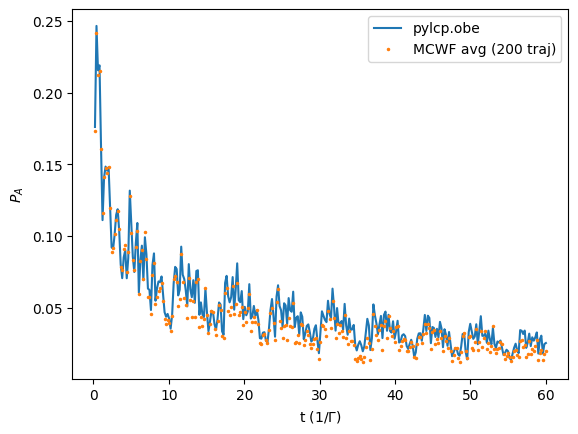

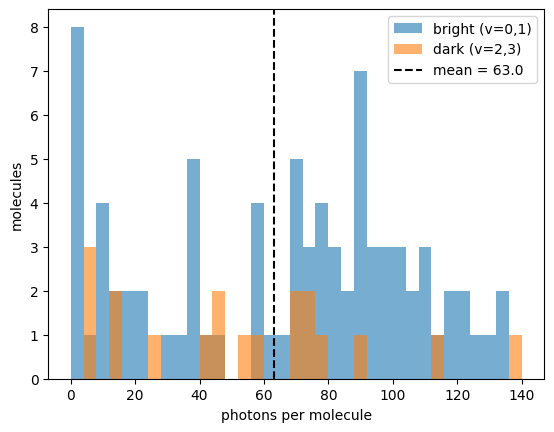

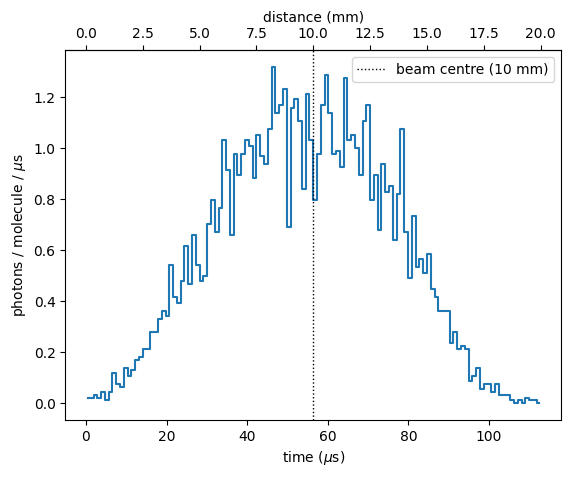

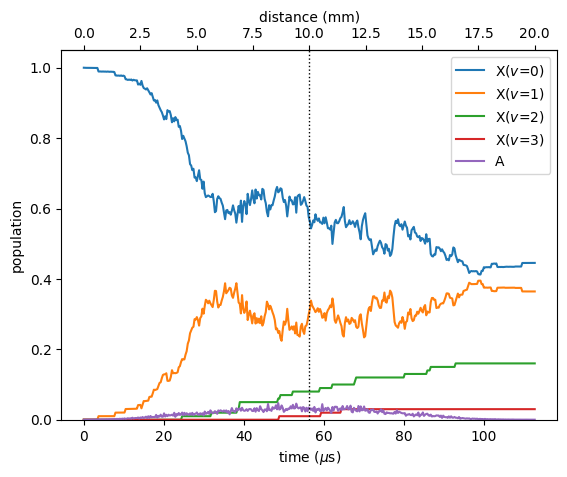


This took 2145.222379922867 s to run


In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate. 
 
The Monte-Carlo wavefunction (MCWF / quantum-jump) method gives both:
a 52-dimensional wavefunction evolves under the non-Hermitian
H_eff(t) = H(t) - (i/2) * P_excited, and each quantum jump IS a
spontaneously emitted photon whose decay channel (FCF-weighted dipole)
decides the vibrational branch. Trajectory-averaged it is mathematically
equivalent to the OBE; trajectory-by-trajectory it is a photon counting
record -- exactly the lab observable.
 
Implementation notes
--------------------
* H(t) is built from pyLCP's own `hamiltonian.return_full_H` and each
  beam's `electric_field`, so all conventions (dipole normalisation,
  polarisation, Zeeman, field amplitude <-> s) are identical to pyLCP's
  OBE by construction. The code asserts this and additionally validates
  the trajectory average against `pylcp.obe` on a reduced system.
* Sideband-sideband and counter-propagating-beam interference is fully
  coherent. The standing-wave phase is sampled by giving each molecule a
  random transverse position x0 (the lab average over the beam).
* Finite laser linewidth is included as phase diffusion, common to all
  sidebands of one colour (they come from one laser + EOM); this
  partially destabilises coherent dark states, as in the real experiment.
* Polarisation: as in the experiment, the light is LINEARLY polarised
  and an electro-optic modulator (Pockels cell) switches it between two
  orthogonal linear polarisations (here y-hat and z-hat, both
  perpendicular to k // x) with a square wave at f_EOM. This is
  implemented by giving every physical beam two static-polarisation
  pyLCP beams (so all field conventions still come from pyLCP) and
  gating them on/off in the MCWF right-hand side; each molecule sees a
  random phase of the switching cycle. Polarisation switching remixes
  Zeeman dark states in addition to the B-field.
"""

import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt
import time

t_begin = time.time()

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 100                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

time_bin = 8.46e-3 # s

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.933, 0.066, 3e-3, 2.5e-4])
fcf = fcf / np.sum(fcf, axis=0)
fcf_sum = np.sum(fcf, axis=0)
assert fcf_sum - 1. < 1e-15, f"FCF factors {fcf_sum} don't sum to 1"
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 10*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
"""
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat
"""
def power_to_s(P_total, fracs, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    fracs = np.asarray(fracs, dtype=float)
    fracs = fracs/fracs.sum()
    return (P_total*fracs)/(2*np.pi*sigma_m**2)/I_sat


V1_ON = True

frac_p1 = np.array([50, 12.5, 12.5, 25])
frac_v1 = np.array([50, 12.5, 12.5, 25])

P_p1 = 105e-3
P_v1 = 200e-3
s_p1 = power_to_s(P_p1, frac_p1, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, frac_v1, sigma_m, w_v1)
print("peak s per sideband: main", np.array2string(s_p1, precision=1),
      " repump", np.array2string(s_v1, precision=1))
print(f"P1 power {P_p1} W")
print(f"V1 power {P_v1} W")
# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 754e3
linewidth_v1_Hz = 541e3
gL_p1 = np.pi*linewidth_p1_Hz*tau   # pi*FWHM * tau = phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau

# EOM polarisation switching: linear polarisation toggled between
# y-hat and z-hat (both perp. to k // x) with a 50% duty-cycle square
# wave at f_EOM. Set to the experimental switching frequency.
f_EOM = 900000                           # Hz
T_switch = 1./(f_EOM*tau)              # full period in units of 1/Gamma
T_half_pol = 0.5*T_switch              # half period (one pol on at a time)
print(f"EOM pol switching: {f_EOM/1e6:.2f} MHz "
      f"(half-period {T_half_pol:.1f} /Gamma)")


R_ap = 5*mm                      # 5 mm aperture radius
y0_arr = np.zeros(N_MC)
# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
# V=0
H0_X[0], Bq_X[0], U_X[0], X_bases[0] = pylcp.hamiltonians.XFmolecules.Xstate(
    N=1, I=1/2, B=7233.8271, gamma=-13.41679,
    b=(170.26374-85.4208/3), 
    c=85.4208, CI=0.02038, q0=0, q2=0,
    gS=2.0023193043622, gI=0.,
    muB=1, return_basis=True
    )
#V=1,2,3
for v in range(3):
    H0, Bq, U, Xbasis = pylcp.hamiltonians.XFmolecules.Xstate(
        N=1, I=1/2, B=7188.8919, gamma=-33.81036, 
        b=(168.770 - 86.7120/3),
        c=86.7120, CI=0.02038, q0=0, q2=0,
        gS=2.0023193043622, gI = 0.0,
        muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
        )
    H0_X[v+1], Bq_X[v+1], U_X[v+1], X_bases[v+1] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=6.2, glprime=-0.633,
    gS=2.0023193043622,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4,
    return_basis=True)
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each, maps 4 excited A amplitudes down into the 12 sublevels of ground manifold v, for emitted polarization q.

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

# The two orthogonal linear polarisations the EOM switches between.
# Beams propagate along +/-x, so both y-hat and z-hat are transverse.
# z-hat drives pi transitions, y-hat drives (sigma+ + sigma-)/sqrt(2).
POL_EOM = (np.array([0., 1., 0.]), np.array([0., 0., 1.]))

def beam_pair(k, s_arr, deltas, s_scale=1.0):
    """Each physical beam is entered twice, once per EOM polarisation
    state (pol group 0 = y-hat, 1 = z-hat). In the MCWF the two are
    gated on/off in antiphase (square wave); for the rate-equation
    reference use s_scale=0.5 with both on, i.e. the time average."""
    beams = []
    s_arr = np.broadcast_to(np.asarray(s_arr, float), np.shape(deltas))
    for delta, s_max in zip(deltas, s_arr):
        for sign in (+1, -1):
            for pol_vec in POL_EOM:
                beams.append({'kvec': np.array([sign*k, 0., 0.]),
                              'pol': pol_vec.copy(),
                              'pol_coord': 'cartesian',
                              'delta': delta,
                              's': crossed_beam_s(s_scale*s_max,
                                                  w_beam, z_laser)})
    
    # F-label diagnostic (just in case)
    E_hf, hf_counts = np.unique(np.diag(H0_X[0]), return_counts=True)
    F_of_count = {1: 'F=0', 3: 'F=1', 5: 'F=2'}
    print("P1 sideband map (index / level / delta / power frac / peak s):")
    for i, (E, c) in enumerate(zip(E_hf, hf_counts)):
        print(f"  [{i}] {F_of_count[c]:4s}  E={E*gamma_MHz:8.1f} MHz  "
            f"delta={deltas_p1[i]:7.2f}  frac={frac_p1[i]/frac_p1.sum():.3f}  "
            f"s={s_p1[i]:.1f}")
    return pylcp.laserBeams(beams)

def polgrp_for(n_deltas):
    """Pol-group index (0=y, 1=z) per beam, matching beam_pair order."""
    return np.array([p for _ in range(n_deltas) for _ in (0, 1)
                     for p in (0, 1)], dtype=np.int64)

E_X_hf = np.unique(np.diag(H0_X[0]))/gamma_MHz
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz
deltas_p1 = E_A_F1 - E_X_hf + det_p1
deltas_v1 = E_A_F1 - E_X_hf + det_v1

if V1_ON:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
                'X1->A': beam_pair(k_v1, s_v1, deltas_v1)
                }

    # Rate-equation reference: rateeq cannot gate beams in time, so use the
    # time average of the square wave -- both polarisations on at s/2.
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5),
                    'X1->A': beam_pair(k_v1, s_v1, deltas_v1, s_scale=0.5)
                 }
else:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1)}
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5)}

B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)


v_forward = 1.5/time_bin/v_unit
print(f"Forward velocity {1.5/time_bin:.2f} ms^-1 with time bin {time_bin} s")
v_vec = np.array([0., 0., v_forward])
t_max = (20*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams_re, magField, ham,
                          include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ----------------------------------------------------------
# MCWF machinery
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
if V1_ON:
    key_row = {'X0->A': 0, 'X1->A': n_X}
else:
    key_row = {'X0->A': 0}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0, y0=0.):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, y0, z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
         phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2].

    EOM polarisation switching: beam b is on only while the square wave
    (half-period T_half, molecule-specific phase offset tsw0) selects
    its pol group polgrp[b]. T_half <= 0 disables gating (all beams on,
    used by the OBE cross-check)."""
    n = psi.shape[0]
    # H_static \psi
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        if T_half > 0.:
            if (np.int64((t + tsw0)//T_half) % 2) != polgrp[b]:
                continue
        # c_b(t) = env exp(i(\delta t + \phi_{colour}))
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                    Lops, Lv, vfw, zc, sig, gL, dt, T, seed,
                    tgrid, pops, jhist):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark).

    Additionally ACCUMULATES (+=, over the whole ensemble) into:
      pops[ig, 0:4] -- population in X(v=0..3) at tgrid[ig]
      pops[ig, 4]   -- population in A at tgrid[ig]
      jhist[jb]     -- photon emission times, binned uniformly on [0, T]
    Divide both by N_MC afterwards."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    nX1 = Lops.shape[1]                 # states per X manifold (12)
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    # molecules arrive at a random phase of the EOM switching cycle
    tsw0 = 0.
    if T_half > 0.:
        tsw0 = np.random.random()*2.*T_half
    t = 0.
    ig = 0
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
             phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            # Choose channel
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            # \psi_new = C \psi
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            # Normalise
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            # bin the emission time (CCD signal ~ z = v*t)
            jb = np.int64(t/T*jhist.shape[0])
            if jb >= jhist.shape[0]:
                jb = jhist.shape[0] - 1
            jhist[jb] += 1.
            # dark vibrational state: population frozen in X(v)
            if V1_ON:
                if v >= 2:               
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            else:
                if v >= 1:
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            rjump = np.random.random()
            nrm = 1.
        elif nrm > 1e-30:
            pass
        # sample manifold populations on the output grid
        while ig < tgrid.shape[0] and t >= tgrid[ig]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # tail: fill any grid points beyond the last integration step
    if ig < tgrid.shape[0]:
        nrm = 0.
        for i in range(n):
            nrm += psi[i].real**2 + psi[i].imag**2
        while ig < tgrid.shape[0]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ---------------------------------------------------------
# Validation: MCWF trajectory average vs pylcp.obe

# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    # pylcp.obe cannot gate polarisations in time, so the cross-check is
    # run with switching DISABLED (T_half = -1): both linear pols on
    # simultaneously in both MCWF and OBE. This still validates every
    # field/phase/Zeeman/jump convention, which is pol-independent.
    pol_r = polgrp_for(len(deltas_p1))
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, 0.,
                 phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
                 0., phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         pol_r, -1.0, L_red, Lv_red, DT, tgrid,
                         int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation_nov1.png', dpi=150)

# -------------------------------------------------------
# Production: full 52-state transit ensemble
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
# 16 main + 16 repump beams (4 sidebands x 2 directions x 2 EOM pols)
colour_arr = np.array([0]*16 + [1]*16, dtype=np.int64)
polgrp_arr = np.concatenate([polgrp_for(len(deltas_p1)),
                             polgrp_for(len(deltas_v1))])
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)

# ensemble-accumulated observables (filled in-place by mcwf_trajectory)
n_tg = 400
tgrid_pop = np.linspace(0., t_max, n_tg)     # population sampling grid
pop_acc = np.zeros((n_tg, 5))                # X0..X3, A
n_jbins = 120
jump_hist = np.zeros(n_jbins)                # photon emission times

for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    y0 = R_ap*np.sqrt(rng.random())*np.sin(2*np.pi*rng.random())
    y0_arr[m] = y0
    Mb, rows, dels = extract_beam_blocks(x0, y0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, polgrp_arr, T_half_pol,
                                 L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)),
                                 tgrid_pop, pop_acc, jump_hist)
    photons[m], v_final[m] = nph, vf
    if (m+1) % 10 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

pop_acc /= N_MC                              # ensemble-average populations

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf_nov1.png', dpi=150)

# ---------------------------------------------------------
# Photon emission rate vs time / distance (what a CCD along z sees).
# Molecules fly at constant v_forward, so z = v*t maps time directly
# onto position; the top axis is distance from the start (beam centre
# marked at z_laser).
v_real = v_forward*v_unit                    # m/s
t_to_us = tau*1e6                            # sim time -> microseconds
us_to_mm = v_real*1e-3                       # 100 m/s = 0.10 mm/us

dt_bin = t_max/n_jbins
t_cent_us = (np.arange(n_jbins) + 0.5)*dt_bin*t_to_us
rate = jump_hist/N_MC/(dt_bin*t_to_us)       # photons /molecule /us

fig2, ax2 = plt.subplots()
ax2.plot(t_cent_us, rate, drawstyle='steps-mid')
ax2.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1,
            label=f'beam centre ({z_laser/mm:.0f} mm)')
ax2.set_xlabel(r'time ($\mu$s)')
ax2.set_ylabel(r'photons / molecule / $\mu$s')
secax2 = ax2.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax2.set_xlabel('distance (mm)')
ax2.legend()
fig2.savefig('photon_rate_vs_time_mcwf.png', dpi=150)

# ---------------------------------------------------------
# Ensemble-averaged populations vs time (X manifolds and A)
fig3, ax3 = plt.subplots()
t_pop_us = tgrid_pop*t_to_us
pop_labels = [r'X($v$=0)', r'X($v$=1)', r'X($v$=2)', r'X($v$=3)', 'A']
for ip in range(5):
    ax3.plot(t_pop_us, pop_acc[:, ip], label=pop_labels[ip])
ax3.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1)
ax3.set_xlabel(r'time ($\mu$s)')
ax3.set_ylabel('population')
ax3.set_ylim(bottom=0.)
secax3 = ax3.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax3.set_xlabel('distance (mm)')
ax3.legend()
fig3.savefig('populations_vs_time_mcwf.png', dpi=150)

plt.show()

print(f"\nThis took {time.time() - t_begin} s to run")

energy unit: Gamma/2pi = 5.684 MHz
peak s per sideband: main [30.3  7.6  7.6 15.1]  repump [31.4  7.9  7.9 15.7]
P1 power 0.105 W
V1 power 0.1 W
EOM pol switching: 0.90 MHz (half-period 19.8 /Gamma)
P1 sideband map (index / level / delta / power frac / peak s):
  [0] F=1   E=  -728.5 MHz  delta=  22.73  frac=0.500  s=30.3
  [1] F=0   E=   156.2 MHz  delta=  -4.65  frac=0.125  s=7.6
  [2] F=2   E=   187.7 MHz  delta=  -5.63  frac=0.125  s=7.6
  [3] F=1   E=   363.6 MHz  delta= -11.07  frac=0.250  s=15.1
P1 sideband map (index / level / delta / power frac / peak s):
  [0] F=1   E=  -728.5 MHz  delta=  22.73  frac=0.500  s=30.3
  [1] F=0   E=   156.2 MHz  delta=  -4.65  frac=0.125  s=7.6
  [2] F=2   E=   187.7 MHz  delta=  -5.63  frac=0.125  s=7.6
  [3] F=1   E=   363.6 MHz  delta= -11.07  frac=0.250  s=15.1
P1 sideband map (index / level / delta / power frac / peak s):
  [0] F=1   E=  -728.5 MHz  delta=  22.73  frac=0.500  s=30.3
  [1] F=0   E=   156.2 MHz  delta=  -4.65  frac=0.125  s=7

KeyboardInterrupt: 

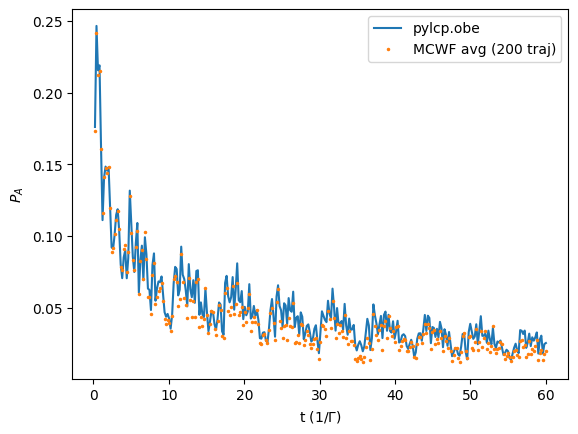

In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate. 
 
The Monte-Carlo wavefunction (MCWF / quantum-jump) method gives both:
a 52-dimensional wavefunction evolves under the non-Hermitian
H_eff(t) = H(t) - (i/2) * P_excited, and each quantum jump IS a
spontaneously emitted photon whose decay channel (FCF-weighted dipole)
decides the vibrational branch. Trajectory-averaged it is mathematically
equivalent to the OBE; trajectory-by-trajectory it is a photon counting
record -- exactly the lab observable.
 
Implementation notes
--------------------
* H(t) is built from pyLCP's own `hamiltonian.return_full_H` and each
  beam's `electric_field`, so all conventions (dipole normalisation,
  polarisation, Zeeman, field amplitude <-> s) are identical to pyLCP's
  OBE by construction. The code asserts this and additionally validates
  the trajectory average against `pylcp.obe` on a reduced system.
* Sideband-sideband and counter-propagating-beam interference is fully
  coherent. The standing-wave phase is sampled by giving each molecule a
  random transverse position x0 (the lab average over the beam).
* Finite laser linewidth is included as phase diffusion, common to all
  sidebands of one colour (they come from one laser + EOM); this
  partially destabilises coherent dark states, as in the real experiment.
* Polarisation: as in the experiment, the light is LINEARLY polarised
  and an electro-optic modulator (Pockels cell) switches it between two
  orthogonal linear polarisations (here y-hat and z-hat, both
  perpendicular to k // x) with a square wave at f_EOM. This is
  implemented by giving every physical beam two static-polarisation
  pyLCP beams (so all field conventions still come from pyLCP) and
  gating them on/off in the MCWF right-hand side; each molecule sees a
  random phase of the switching cycle. Polarisation switching remixes
  Zeeman dark states in addition to the B-field.
"""

import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt
import time

t_begin = time.time()

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 100                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

time_bin = 8.46e-3 # s

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.933, 0.066, 3e-3, 2.5e-4])
fcf = fcf / np.sum(fcf, axis=0)
fcf_sum = np.sum(fcf, axis=0)
assert fcf_sum - 1. < 1e-15, f"FCF factors {fcf_sum} don't sum to 1"
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 10*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
"""
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat
"""
def power_to_s(P_total, fracs, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    fracs = np.asarray(fracs, dtype=float)
    fracs = fracs/fracs.sum()
    return (P_total*fracs)/(2*np.pi*sigma_m**2)/I_sat


V1_ON = True

frac_p1 = np.array([50, 12.5, 12.5, 25])
frac_v1 = np.array([50, 12.5, 12.5, 25])

P_p1 = 105e-3
P_v1 = 100e-3
s_p1 = power_to_s(P_p1, frac_p1, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, frac_v1, sigma_m, w_v1)
print("peak s per sideband: main", np.array2string(s_p1, precision=1),
      " repump", np.array2string(s_v1, precision=1))
print(f"P1 power {P_p1} W")
print(f"V1 power {P_v1} W")
# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 754e3
linewidth_v1_Hz = 541e3
gL_p1 = np.pi*linewidth_p1_Hz*tau   # pi*FWHM * tau = phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau

# EOM polarisation switching: linear polarisation toggled between
# y-hat and z-hat (both perp. to k // x) with a 50% duty-cycle square
# wave at f_EOM. Set to the experimental switching frequency.
f_EOM = 900000                           # Hz
T_switch = 1./(f_EOM*tau)              # full period in units of 1/Gamma
T_half_pol = 0.5*T_switch              # half period (one pol on at a time)
print(f"EOM pol switching: {f_EOM/1e6:.2f} MHz "
      f"(half-period {T_half_pol:.1f} /Gamma)")


R_ap = 5*mm                      # 5 mm aperture radius
y0_arr = np.zeros(N_MC)
# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
# V=0
H0_X[0], Bq_X[0], U_X[0], X_bases[0] = pylcp.hamiltonians.XFmolecules.Xstate(
    N=1, I=1/2, B=7233.8271, gamma=-13.41679,
    b=(170.26374-85.4208/3), 
    c=85.4208, CI=0.02038, q0=0, q2=0,
    gS=2.0023193043622, gI=0.,
    muB=1, return_basis=True
    )
#V=1,2,3
for v in range(3):
    H0, Bq, U, Xbasis = pylcp.hamiltonians.XFmolecules.Xstate(
        N=1, I=1/2, B=7188.8919, gamma=-33.81036, 
        b=(168.770 - 86.7120/3),
        c=86.7120, CI=0.02038, q0=0, q2=0,
        gS=2.0023193043622, gI = 0.0,
        muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
        )
    H0_X[v+1], Bq_X[v+1], U_X[v+1], X_bases[v+1] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=6.2, glprime=-0.633,
    gS=2.0023193043622,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4,
    return_basis=True)
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each, maps 4 excited A amplitudes down into the 12 sublevels of ground manifold v, for emitted polarization q.

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

# The two orthogonal linear polarisations the EOM switches between.
# Beams propagate along +/-x, so both y-hat and z-hat are transverse.
# z-hat drives pi transitions, y-hat drives (sigma+ + sigma-)/sqrt(2).
POL_EOM = (np.array([0., 1., 0.]), np.array([0., 0., 1.]))

def beam_pair(k, s_arr, deltas, s_scale=1.0):
    """Each physical beam is entered twice, once per EOM polarisation
    state (pol group 0 = y-hat, 1 = z-hat). In the MCWF the two are
    gated on/off in antiphase (square wave); for the rate-equation
    reference use s_scale=0.5 with both on, i.e. the time average."""
    beams = []
    s_arr = np.broadcast_to(np.asarray(s_arr, float), np.shape(deltas))
    for delta, s_max in zip(deltas, s_arr):
        for sign in (+1, -1):
            for pol_vec in POL_EOM:
                beams.append({'kvec': np.array([sign*k, 0., 0.]),
                              'pol': pol_vec.copy(),
                              'pol_coord': 'cartesian',
                              'delta': delta,
                              's': crossed_beam_s(s_scale*s_max,
                                                  w_beam, z_laser)})
    
    # F-label diagnostic (just in case)
    E_hf, hf_counts = np.unique(np.diag(H0_X[0]), return_counts=True)
    F_of_count = {1: 'F=0', 3: 'F=1', 5: 'F=2'}
    print("P1 sideband map (index / level / delta / power frac / peak s):")
    for i, (E, c) in enumerate(zip(E_hf, hf_counts)):
        print(f"  [{i}] {F_of_count[c]:4s}  E={E*gamma_MHz:8.1f} MHz  "
            f"delta={deltas_p1[i]:7.2f}  frac={frac_p1[i]/frac_p1.sum():.3f}  "
            f"s={s_p1[i]:.1f}")
    return pylcp.laserBeams(beams)

def polgrp_for(n_deltas):
    """Pol-group index (0=y, 1=z) per beam, matching beam_pair order."""
    return np.array([p for _ in range(n_deltas) for _ in (0, 1)
                     for p in (0, 1)], dtype=np.int64)

E_X_hf = np.unique(np.diag(H0_X[0]))/gamma_MHz
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz
deltas_p1 = E_A_F1 - E_X_hf + det_p1
deltas_v1 = E_A_F1 - E_X_hf + det_v1

if V1_ON:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
                'X1->A': beam_pair(k_v1, s_v1, deltas_v1)
                }

    # Rate-equation reference: rateeq cannot gate beams in time, so use the
    # time average of the square wave -- both polarisations on at s/2.
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5),
                    'X1->A': beam_pair(k_v1, s_v1, deltas_v1, s_scale=0.5)
                 }
else:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1)}
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5)}

B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)


v_forward = 1.5/time_bin/v_unit
print(f"Forward velocity {1.5/time_bin:.2f} ms^-1 with time bin {time_bin} s")
v_vec = np.array([0., 0., v_forward])
t_max = (20*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams_re, magField, ham,
                          include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ----------------------------------------------------------
# MCWF machinery
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
if V1_ON:
    key_row = {'X0->A': 0, 'X1->A': n_X}
else:
    key_row = {'X0->A': 0}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0, y0=0.):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, y0, z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
         phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2].

    EOM polarisation switching: beam b is on only while the square wave
    (half-period T_half, molecule-specific phase offset tsw0) selects
    its pol group polgrp[b]. T_half <= 0 disables gating (all beams on,
    used by the OBE cross-check)."""
    n = psi.shape[0]
    # H_static \psi
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        if T_half > 0.:
            if (np.int64((t + tsw0)//T_half) % 2) != polgrp[b]:
                continue
        # c_b(t) = env exp(i(\delta t + \phi_{colour}))
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                    Lops, Lv, vfw, zc, sig, gL, dt, T, seed,
                    tgrid, pops, jhist):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark).

    Additionally ACCUMULATES (+=, over the whole ensemble) into:
      pops[ig, 0:4] -- population in X(v=0..3) at tgrid[ig]
      pops[ig, 4]   -- population in A at tgrid[ig]
      jhist[jb]     -- photon emission times, binned uniformly on [0, T]
    Divide both by N_MC afterwards."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    nX1 = Lops.shape[1]                 # states per X manifold (12)
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    # molecules arrive at a random phase of the EOM switching cycle
    tsw0 = 0.
    if T_half > 0.:
        tsw0 = np.random.random()*2.*T_half
    t = 0.
    ig = 0
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
             phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            # Choose channel
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            # \psi_new = C \psi
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            # Normalise
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            # bin the emission time (CCD signal ~ z = v*t)
            jb = np.int64(t/T*jhist.shape[0])
            if jb >= jhist.shape[0]:
                jb = jhist.shape[0] - 1
            jhist[jb] += 1.
            # dark vibrational state: population frozen in X(v)
            if V1_ON:
                if v >= 2:               
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            else:
                if v >= 1:
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            rjump = np.random.random()
            nrm = 1.
        elif nrm > 1e-30:
            pass
        # sample manifold populations on the output grid
        while ig < tgrid.shape[0] and t >= tgrid[ig]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # tail: fill any grid points beyond the last integration step
    if ig < tgrid.shape[0]:
        nrm = 0.
        for i in range(n):
            nrm += psi[i].real**2 + psi[i].imag**2
        while ig < tgrid.shape[0]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ---------------------------------------------------------
# Validation: MCWF trajectory average vs pylcp.obe

# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    # pylcp.obe cannot gate polarisations in time, so the cross-check is
    # run with switching DISABLED (T_half = -1): both linear pols on
    # simultaneously in both MCWF and OBE. This still validates every
    # field/phase/Zeeman/jump convention, which is pol-independent.
    pol_r = polgrp_for(len(deltas_p1))
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, 0.,
                 phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
                 0., phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         pol_r, -1.0, L_red, Lv_red, DT, tgrid,
                         int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation_nov1.png', dpi=150)

# -------------------------------------------------------
# Production: full 52-state transit ensemble
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
# 16 main + 16 repump beams (4 sidebands x 2 directions x 2 EOM pols)
colour_arr = np.array([0]*16 + [1]*16, dtype=np.int64)
polgrp_arr = np.concatenate([polgrp_for(len(deltas_p1)),
                             polgrp_for(len(deltas_v1))])
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)

# ensemble-accumulated observables (filled in-place by mcwf_trajectory)
n_tg = 400
tgrid_pop = np.linspace(0., t_max, n_tg)     # population sampling grid
pop_acc = np.zeros((n_tg, 5))                # X0..X3, A
n_jbins = 120
jump_hist = np.zeros(n_jbins)                # photon emission times

for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    y0 = R_ap*np.sqrt(rng.random())*np.sin(2*np.pi*rng.random())
    y0_arr[m] = y0
    Mb, rows, dels = extract_beam_blocks(x0, y0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, polgrp_arr, T_half_pol,
                                 L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)),
                                 tgrid_pop, pop_acc, jump_hist)
    photons[m], v_final[m] = nph, vf
    if (m+1) % 10 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

pop_acc /= N_MC                              # ensemble-average populations

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf_nov1.png', dpi=150)

# ---------------------------------------------------------
# Photon emission rate vs time / distance (what a CCD along z sees).
# Molecules fly at constant v_forward, so z = v*t maps time directly
# onto position; the top axis is distance from the start (beam centre
# marked at z_laser).
v_real = v_forward*v_unit                    # m/s
t_to_us = tau*1e6                            # sim time -> microseconds
us_to_mm = v_real*1e-3                       # 100 m/s = 0.10 mm/us

dt_bin = t_max/n_jbins
t_cent_us = (np.arange(n_jbins) + 0.5)*dt_bin*t_to_us
rate = jump_hist/N_MC/(dt_bin*t_to_us)       # photons /molecule /us

fig2, ax2 = plt.subplots()
ax2.plot(t_cent_us, rate, drawstyle='steps-mid')
ax2.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1,
            label=f'beam centre ({z_laser/mm:.0f} mm)')
ax2.set_xlabel(r'time ($\mu$s)')
ax2.set_ylabel(r'photons / molecule / $\mu$s')
secax2 = ax2.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax2.set_xlabel('distance (mm)')
ax2.legend()
fig2.savefig('photon_rate_vs_time_mcwf.png', dpi=150)

# ---------------------------------------------------------
# Ensemble-averaged populations vs time (X manifolds and A)
fig3, ax3 = plt.subplots()
t_pop_us = tgrid_pop*t_to_us
pop_labels = [r'X($v$=0)', r'X($v$=1)', r'X($v$=2)', r'X($v$=3)', 'A']
for ip in range(5):
    ax3.plot(t_pop_us, pop_acc[:, ip], label=pop_labels[ip])
ax3.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1)
ax3.set_xlabel(r'time ($\mu$s)')
ax3.set_ylabel('population')
ax3.set_ylim(bottom=0.)
secax3 = ax3.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax3.set_xlabel('distance (mm)')
ax3.legend()
fig3.savefig('populations_vs_time_mcwf.png', dpi=150)

plt.show()

print(f"\nThis took {time.time() - t_begin} s to run")

In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate. 
 
The Monte-Carlo wavefunction (MCWF / quantum-jump) method gives both:
a 52-dimensional wavefunction evolves under the non-Hermitian
H_eff(t) = H(t) - (i/2) * P_excited, and each quantum jump IS a
spontaneously emitted photon whose decay channel (FCF-weighted dipole)
decides the vibrational branch. Trajectory-averaged it is mathematically
equivalent to the OBE; trajectory-by-trajectory it is a photon counting
record -- exactly the lab observable.
 
Implementation notes
--------------------
* H(t) is built from pyLCP's own `hamiltonian.return_full_H` and each
  beam's `electric_field`, so all conventions (dipole normalisation,
  polarisation, Zeeman, field amplitude <-> s) are identical to pyLCP's
  OBE by construction. The code asserts this and additionally validates
  the trajectory average against `pylcp.obe` on a reduced system.
* Sideband-sideband and counter-propagating-beam interference is fully
  coherent. The standing-wave phase is sampled by giving each molecule a
  random transverse position x0 (the lab average over the beam).
* Finite laser linewidth is included as phase diffusion, common to all
  sidebands of one colour (they come from one laser + EOM); this
  partially destabilises coherent dark states, as in the real experiment.
* Polarisation: as in the experiment, the light is LINEARLY polarised
  and an electro-optic modulator (Pockels cell) switches it between two
  orthogonal linear polarisations (here y-hat and z-hat, both
  perpendicular to k // x) with a square wave at f_EOM. This is
  implemented by giving every physical beam two static-polarisation
  pyLCP beams (so all field conventions still come from pyLCP) and
  gating them on/off in the MCWF right-hand side; each molecule sees a
  random phase of the switching cycle. Polarisation switching remixes
  Zeeman dark states in addition to the B-field.
"""

import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt
import time

t_begin = time.time()

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 100                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

time_bin = 8.46e-3 # s

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.933, 0.066, 3e-3, 2.5e-4])
fcf = fcf / np.sum(fcf, axis=0)
fcf_sum = np.sum(fcf, axis=0)
assert fcf_sum - 1. < 1e-15, f"FCF factors {fcf_sum} don't sum to 1"
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 10*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
"""
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat
"""
def power_to_s(P_total, fracs, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    fracs = np.asarray(fracs, dtype=float)
    fracs = fracs/fracs.sum()
    return (P_total*fracs)/(2*np.pi*sigma_m**2)/I_sat


V1_ON = True

frac_p1 = np.array([50, 12.5, 12.5, 25])
frac_v1 = np.array([50, 12.5, 12.5, 25])

P_p1 = 105e-3
P_v1 = 100e-3
s_p1 = power_to_s(P_p1, frac_p1, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, frac_v1, sigma_m, w_v1)
print("peak s per sideband: main", np.array2string(s_p1, precision=1),
      " repump", np.array2string(s_v1, precision=1))
print(f"P1 power {P_p1} W")
print(f"V1 power {P_v1} W")
# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 754e3
linewidth_v1_Hz = 541e3
gL_p1 = np.pi*linewidth_p1_Hz*tau   # pi*FWHM * tau = phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau

# EOM polarisation switching: linear polarisation toggled between
# y-hat and z-hat (both perp. to k // x) with a 50% duty-cycle square
# wave at f_EOM. Set to the experimental switching frequency.
f_EOM = 900000                           # Hz
T_switch = 1./(f_EOM*tau)              # full period in units of 1/Gamma
T_half_pol = 0.5*T_switch              # half period (one pol on at a time)
print(f"EOM pol switching: {f_EOM/1e6:.2f} MHz "
      f"(half-period {T_half_pol:.1f} /Gamma)")


R_ap = 5*mm                      # 5 mm aperture radius
y0_arr = np.zeros(N_MC)
# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
# V=0
H0_X, Bq_X, U_X, Xbasis = pylcp.hamiltonians.XFmolecules.Xstate(
    N=1, I=1/2, B=7233.8271, gamma=-13.41679,
    b=(170.26374-85.4208/3), 
    c=85.4208, CI=0.02038, q0=0, q2=0,
    gS=2.0023193043622, gI=0.,
    muB=1, return_basis=True
    )
#V=1,2,3
for v in range(3):
    H0, Bq, U, Xbasis = pylcp.hamiltonians.XFmolecules.Xstate(
        N=1, I=1/2, B=7188.8919, gamma=-33.81036, 
        b=(168.770 - 86.7120/3), #cant find the value for CI, so copy jorge's
        c=86.7120, CI=0.02038, q0=0, q2=0,
        gS=2.0023193043622, gI = 0.0,
        muB=1, return_basis=True
        )
    H0_X[v+1], Bq_X[v+1], U_X[v+1], X_bases[v+1] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = pylcp.hamiltonians.XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=(3/2*4.8), glprime=-3*.0211,
    muB=1, return_basis=True
    )
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each, maps 4 excited A amplitudes down into the 12 sublevels of ground manifold v, for emitted polarization q.

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

# The two orthogonal linear polarisations the EOM switches between.
# Beams propagate along +/-x, so both y-hat and z-hat are transverse.
# z-hat drives pi transitions, y-hat drives (sigma+ + sigma-)/sqrt(2).
POL_EOM = (np.array([0., 1., 0.]), np.array([0., 0., 1.]))

def beam_pair(k, s_arr, deltas, s_scale=1.0):
    """Each physical beam is entered twice, once per EOM polarisation
    state (pol group 0 = y-hat, 1 = z-hat). In the MCWF the two are
    gated on/off in antiphase (square wave); for the rate-equation
    reference use s_scale=0.5 with both on, i.e. the time average."""
    beams = []
    s_arr = np.broadcast_to(np.asarray(s_arr, float), np.shape(deltas))
    for delta, s_max in zip(deltas, s_arr):
        for sign in (+1, -1):
            for pol_vec in POL_EOM:
                beams.append({'kvec': np.array([sign*k, 0., 0.]),
                              'pol': pol_vec.copy(),
                              'pol_coord': 'cartesian',
                              'delta': delta,
                              's': crossed_beam_s(s_scale*s_max,
                                                  w_beam, z_laser)})

    return pylcp.laserBeams(beams)

def polgrp_for(n_deltas):
    """Pol-group index (0=y, 1=z) per beam, matching beam_pair order."""
    return np.array([p for _ in range(n_deltas) for _ in (0, 1)
                     for p in (0, 1)], dtype=np.int64)

def hf_levels(H0):
    """Unique hyperfine energies (in Gamma units) + degeneracies."""
    E, cnt = np.unique(np.round(np.diag(H0), 6), return_counts=True)
    return E/gamma_MHz, cnt

E_X0_hf, cnt_X0 = hf_levels(H0_X[0])
E_X1_hf, cnt_X1 = hf_levels(H0_X[1])
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz

deltas_p1 = E_A_F1 - E_X0_hf + det_p1
deltas_v1 = E_A_F1 - E_X1_hf + det_v1          # <-- v=1 energies, not v=0
assert len(deltas_p1) == 4 and len(deltas_v1) == 4, "hyperfine degeneracy split"

if V1_ON:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
                'X1->A': beam_pair(k_v1, s_v1, deltas_v1)
                }

    # Rate-equation reference: rateeq cannot gate beams in time, so use the
    # time average of the square wave -- both polarisations on at s/2.
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5),
                    'X1->A': beam_pair(k_v1, s_v1, deltas_v1, s_scale=0.5)
                 }
else:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1)}
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5)}

# F-label diagnostic (just in case)
F_of_count = {1: 'F=0', 3: 'F=1', 5: 'F=2'}
for tag, (E, cnt), fr, s_ in [('P1/X0', (E_X0_hf, cnt_X0), frac_p1, s_p1),
                              ('V1/X1', (E_X1_hf, cnt_X1), frac_v1, s_v1)]:
    print(f"{tag} sideband map:")
    for i, (Ei, ci) in enumerate(zip(E, cnt)):
        print(f"  [{i}] {F_of_count[ci]:4s} E={Ei*gamma_MHz:8.1f} MHz "
              f"frac={fr[i]/np.sum(fr):.3f}  s={s_[i]:.1f}")


B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)


v_forward = 1.5/time_bin/v_unit
print(f"Forward velocity {1.5/time_bin:.2f} ms^-1 with time bin {time_bin} s")
v_vec = np.array([0., 0., v_forward])
t_max = (20*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams_re, magField, ham,
                          include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ----------------------------------------------------------
# MCWF machinery
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
if V1_ON:
    key_row = {'X0->A': 0, 'X1->A': n_X}
else:
    key_row = {'X0->A': 0}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0, y0=0.):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, y0, z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
         phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2].

    EOM polarisation switching: beam b is on only while the square wave
    (half-period T_half, molecule-specific phase offset tsw0) selects
    its pol group polgrp[b]. T_half <= 0 disables gating (all beams on,
    used by the OBE cross-check)."""
    n = psi.shape[0]
    # H_static \psi
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        if T_half > 0.:
            if (np.int64((t + tsw0)//T_half) % 2) != polgrp[b]:
                continue
        # c_b(t) = env exp(i(\delta t + \phi_{colour}))
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                    Lops, Lv, vfw, zc, sig, gL, dt, T, seed,
                    tgrid, pops, jhist):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark).

    Additionally ACCUMULATES (+=, over the whole ensemble) into:
      pops[ig, 0:4] -- population in X(v=0..3) at tgrid[ig]
      pops[ig, 4]   -- population in A at tgrid[ig]
      jhist[jb]     -- photon emission times, binned uniformly on [0, T]
    Divide both by N_MC afterwards."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    nX1 = Lops.shape[1]                 # states per X manifold (12)
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    # molecules arrive at a random phase of the EOM switching cycle
    tsw0 = 0.
    if T_half > 0.:
        tsw0 = np.random.random()*2.*T_half
    t = 0.
    ig = 0
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
             phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            # Choose channel
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            # \psi_new = C \psi
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            # Normalise
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            # bin the emission time (CCD signal ~ z = v*t)
            jb = np.int64(t/T*jhist.shape[0])
            if jb >= jhist.shape[0]:
                jb = jhist.shape[0] - 1
            jhist[jb] += 1.
            # dark vibrational state: population frozen in X(v)
            if V1_ON:
                if v >= 2:               
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            else:
                if v >= 1:
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            rjump = np.random.random()
            nrm = 1.
        elif nrm > 1e-30:
            pass
        # sample manifold populations on the output grid
        while ig < tgrid.shape[0] and t >= tgrid[ig]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # tail: fill any grid points beyond the last integration step
    if ig < tgrid.shape[0]:
        nrm = 0.
        for i in range(n):
            nrm += psi[i].real**2 + psi[i].imag**2
        while ig < tgrid.shape[0]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ---------------------------------------------------------
# Validation: MCWF trajectory average vs pylcp.obe

# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    # pylcp.obe cannot gate polarisations in time, so the cross-check is
    # run with switching DISABLED (T_half = -1): both linear pols on
    # simultaneously in both MCWF and OBE. This still validates every
    # field/phase/Zeeman/jump convention, which is pol-independent.
    pol_r = polgrp_for(len(deltas_p1))
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, 0.,
                 phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
                 0., phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         pol_r, -1.0, L_red, Lv_red, DT, tgrid,
                         int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation_nov1.png', dpi=150)

# -------------------------------------------------------
# Production: full 52-state transit ensemble
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
# 16 main + 16 repump beams (4 sidebands x 2 directions x 2 EOM pols)
colour_arr = np.array([0]*16 + [1]*16, dtype=np.int64)
polgrp_arr = np.concatenate([polgrp_for(len(deltas_p1)),
                             polgrp_for(len(deltas_v1))])
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)

# ensemble-accumulated observables (filled in-place by mcwf_trajectory)
n_tg = 400
tgrid_pop = np.linspace(0., t_max, n_tg)     # population sampling grid
pop_acc = np.zeros((n_tg, 5))                # X0..X3, A
n_jbins = 120
jump_hist = np.zeros(n_jbins)                # photon emission times

for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    y0 = R_ap*np.sqrt(rng.random())*np.sin(2*np.pi*rng.random())
    y0_arr[m] = y0
    Mb, rows, dels = extract_beam_blocks(x0, y0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, polgrp_arr, T_half_pol,
                                 L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)),
                                 tgrid_pop, pop_acc, jump_hist)
    photons[m], v_final[m] = nph, vf
    if (m+1) % 10 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

pop_acc /= N_MC                              # ensemble-average populations

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf_nov1.png', dpi=150)

# ---------------------------------------------------------
# Photon emission rate vs time / distance (what a CCD along z sees).
# Molecules fly at constant v_forward, so z = v*t maps time directly
# onto position; the top axis is distance from the start (beam centre
# marked at z_laser).
v_real = v_forward*v_unit                    # m/s
t_to_us = tau*1e6                            # sim time -> microseconds
us_to_mm = v_real*1e-3                       # 100 m/s = 0.10 mm/us

dt_bin = t_max/n_jbins
t_cent_us = (np.arange(n_jbins) + 0.5)*dt_bin*t_to_us
rate = jump_hist/N_MC/(dt_bin*t_to_us)       # photons /molecule /us

fig2, ax2 = plt.subplots()
ax2.plot(t_cent_us, rate, drawstyle='steps-mid')
ax2.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1,
            label=f'beam centre ({z_laser/mm:.0f} mm)')
ax2.set_xlabel(r'time ($\mu$s)')
ax2.set_ylabel(r'photons / molecule / $\mu$s')
secax2 = ax2.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax2.set_xlabel('distance (mm)')
ax2.legend()
fig2.savefig('photon_rate_vs_time_mcwf.png', dpi=150)

# ---------------------------------------------------------
# Ensemble-averaged populations vs time (X manifolds and A)
fig3, ax3 = plt.subplots()
t_pop_us = tgrid_pop*t_to_us
pop_labels = [r'X($v$=0)', r'X($v$=1)', r'X($v$=2)', r'X($v$=3)', 'A']
for ip in range(5):
    ax3.plot(t_pop_us, pop_acc[:, ip], label=pop_labels[ip])
ax3.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1)
ax3.set_xlabel(r'time ($\mu$s)')
ax3.set_ylabel('population')
ax3.set_ylim(bottom=0.)
secax3 = ax3.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax3.set_xlabel('distance (mm)')
ax3.legend()
fig3.savefig('populations_vs_time_mcwf.png', dpi=150)

plt.show()

print(f"\nThis took {time.time() - t_begin} s to run")

energy unit: Gamma/2pi = 5.684 MHz
peak s per sideband: main [30.3  7.6  7.6 15.1]  repump [31.4  7.9  7.9 15.7]
P1 power 0.105 W
V1 power 0.1 W
EOM pol switching: 0.90 MHz (half-period 19.8 /Gamma)


ValueError: could not broadcast input array from shape (12,12) into shape (12,)

In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate. 
 
The Monte-Carlo wavefunction (MCWF / quantum-jump) method gives both:
a 52-dimensional wavefunction evolves under the non-Hermitian
H_eff(t) = H(t) - (i/2) * P_excited, and each quantum jump IS a
spontaneously emitted photon whose decay channel (FCF-weighted dipole)
decides the vibrational branch. Trajectory-averaged it is mathematically
equivalent to the OBE; trajectory-by-trajectory it is a photon counting
record -- exactly the lab observable.
 
Implementation notes
--------------------
* H(t) is built from pyLCP's own `hamiltonian.return_full_H` and each
  beam's `electric_field`, so all conventions (dipole normalisation,
  polarisation, Zeeman, field amplitude <-> s) are identical to pyLCP's
  OBE by construction. The code asserts this and additionally validates
  the trajectory average against `pylcp.obe` on a reduced system.
* Sideband-sideband and counter-propagating-beam interference is fully
  coherent. The standing-wave phase is sampled by giving each molecule a
  random transverse position x0 (the lab average over the beam).
* Finite laser linewidth is included as phase diffusion, common to all
  sidebands of one colour (they come from one laser + EOM); this
  partially destabilises coherent dark states, as in the real experiment.
* Polarisation: as in the experiment, the light is LINEARLY polarised
  and an electro-optic modulator (Pockels cell) switches it between two
  orthogonal linear polarisations (here y-hat and z-hat, both
  perpendicular to k // x) with a square wave at f_EOM. This is
  implemented by giving every physical beam two static-polarisation
  pyLCP beams (so all field conventions still come from pyLCP) and
  gating them on/off in the MCWF right-hand side; each molecule sees a
  random phase of the switching cycle. Polarisation switching remixes
  Zeeman dark states in addition to the B-field.
"""

import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt
import time

t_begin = time.time()

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 100                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

time_bin = 8.46e-3 # s

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.933, 0.066, 3e-3, 2.5e-4])
fcf = fcf / np.sum(fcf, axis=0)
fcf_sum = np.sum(fcf, axis=0)
assert fcf_sum - 1. < 1e-15, f"FCF factors {fcf_sum} don't sum to 1"
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 10*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
"""
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat
"""
def power_to_s(P_total, fracs, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    fracs = np.asarray(fracs, dtype=float)
    fracs = fracs/fracs.sum()
    return (P_total*fracs)/(2*np.pi*sigma_m**2)/I_sat


V1_ON = True

frac_p1 = np.array([50, 12.5, 12.5, 25])
frac_v1 = np.array([50, 12.5, 12.5, 25])

P_p1 = 105e-3
P_v1 = 100e-3
s_p1 = power_to_s(P_p1, frac_p1, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, frac_v1, sigma_m, w_v1)
print("peak s per sideband: main", np.array2string(s_p1, precision=1),
      " repump", np.array2string(s_v1, precision=1))
print(f"P1 power {P_p1} W")
print(f"V1 power {P_v1} W")
# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 754e3
linewidth_v1_Hz = 541e3
gL_p1 = np.pi*linewidth_p1_Hz*tau   # pi*FWHM * tau = phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau

# EOM polarisation switching: linear polarisation toggled between
# y-hat and z-hat (both perp. to k // x) with a 50% duty-cycle square
# wave at f_EOM. Set to the experimental switching frequency.
f_EOM = 900000                           # Hz
T_switch = 1./(f_EOM*tau)              # full period in units of 1/Gamma
T_half_pol = 0.5*T_switch              # half period (one pol on at a time)
print(f"EOM pol switching: {f_EOM/1e6:.2f} MHz "
      f"(half-period {T_half_pol:.1f} /Gamma)")


R_ap = 5*mm                      # 5 mm aperture radius
y0_arr = np.zeros(N_MC)
# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
# V=0
H0_X, Bq_X, U_X, Xbasis = pylcp.hamiltonians.XFmolecules.Xstate(
    N=1, I=1/2, B=7233.8271, gamma=-13.41679,
    b=(170.26374-85.4208/3), 
    c=85.4208, CI=0.02038, q0=0, q2=0,
    gS=2.0023193043622, gI=0.,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
    )
#V=1,2,3
for v in range(3):
    H0, Bq, U, Xbasis = pylcp.hamiltonians.XFmolecules.Xstate(
        N=1, I=1/2, B=7188.8919, gamma=-33.81036, 
        b=(168.770 - 86.7120/3), 
        c=86.7120, CI=0.02038, q0=0, q2=0,
        gS=2.0023193043622, gI = 0.0,
        muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
        )
    H0_X[v+1], Bq_X[v+1], U_X[v+1], X_bases[v+1] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = pylcp.hamiltonians.XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=(3/2*4.8), glprime=-3*.0211,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
    )
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each, maps 4 excited A amplitudes down into the 12 sublevels of ground manifold v, for emitted polarization q.

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

# The two orthogonal linear polarisations the EOM switches between.
# Beams propagate along +/-x, so both y-hat and z-hat are transverse.
# z-hat drives pi transitions, y-hat drives (sigma+ + sigma-)/sqrt(2).
POL_EOM = (np.array([0., 1., 0.]), np.array([0., 0., 1.]))

def beam_pair(k, s_arr, deltas, s_scale=1.0):
    """Each physical beam is entered twice, once per EOM polarisation
    state (pol group 0 = y-hat, 1 = z-hat). In the MCWF the two are
    gated on/off in antiphase (square wave); for the rate-equation
    reference use s_scale=0.5 with both on, i.e. the time average."""
    beams = []
    s_arr = np.broadcast_to(np.asarray(s_arr, float), np.shape(deltas))
    for delta, s_max in zip(deltas, s_arr):
        for sign in (+1, -1):
            for pol_vec in POL_EOM:
                beams.append({'kvec': np.array([sign*k, 0., 0.]),
                              'pol': pol_vec.copy(),
                              'pol_coord': 'cartesian',
                              'delta': delta,
                              's': crossed_beam_s(s_scale*s_max,
                                                  w_beam, z_laser)})

    return pylcp.laserBeams(beams)

def polgrp_for(n_deltas):
    """Pol-group index (0=y, 1=z) per beam, matching beam_pair order."""
    return np.array([p for _ in range(n_deltas) for _ in (0, 1)
                     for p in (0, 1)], dtype=np.int64)

def hf_levels(H0):
    """Unique hyperfine energies (in Gamma units) + degeneracies."""
    E, cnt = np.unique(np.round(np.diag(H0), 6), return_counts=True)
    return E/gamma_MHz, cnt

E_X0_hf, cnt_X0 = hf_levels(H0_X[0])
E_X1_hf, cnt_X1 = hf_levels(H0_X[1])
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz

deltas_p1 = E_A_F1 - E_X0_hf + det_p1
deltas_v1 = E_A_F1 - E_X1_hf + det_v1          # <-- v=1 energies, not v=0
assert len(deltas_p1) == 4 and len(deltas_v1) == 4, "hyperfine degeneracy split"

if V1_ON:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
                'X1->A': beam_pair(k_v1, s_v1, deltas_v1)
                }

    # Rate-equation reference: rateeq cannot gate beams in time, so use the
    # time average of the square wave -- both polarisations on at s/2.
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5),
                    'X1->A': beam_pair(k_v1, s_v1, deltas_v1, s_scale=0.5)
                 }
else:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1)}
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5)}

# F-label diagnostic (just in case)
F_of_count = {1: 'F=0', 3: 'F=1', 5: 'F=2'}
for tag, (E, cnt), fr, s_ in [('P1/X0', (E_X0_hf, cnt_X0), frac_p1, s_p1),
                              ('V1/X1', (E_X1_hf, cnt_X1), frac_v1, s_v1)]:
    print(f"{tag} sideband map:")
    for i, (Ei, ci) in enumerate(zip(E, cnt)):
        print(f"  [{i}] {F_of_count[ci]:4s} E={Ei*gamma_MHz:8.1f} MHz "
              f"frac={fr[i]/np.sum(fr):.3f}  s={s_[i]:.1f}")


B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)


v_forward = 1.5/time_bin/v_unit
print(f"Forward velocity {1.5/time_bin:.2f} ms^-1 with time bin {time_bin} s")
v_vec = np.array([0., 0., v_forward])
t_max = (20*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams_re, magField, ham,
                          include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ----------------------------------------------------------
# MCWF machinery
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
if V1_ON:
    key_row = {'X0->A': 0, 'X1->A': n_X}
else:
    key_row = {'X0->A': 0}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0, y0=0.):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, y0, z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
         phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2].

    EOM polarisation switching: beam b is on only while the square wave
    (half-period T_half, molecule-specific phase offset tsw0) selects
    its pol group polgrp[b]. T_half <= 0 disables gating (all beams on,
    used by the OBE cross-check)."""
    n = psi.shape[0]
    # H_static \psi
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        if T_half > 0.:
            if (np.int64((t + tsw0)//T_half) % 2) != polgrp[b]:
                continue
        # c_b(t) = env exp(i(\delta t + \phi_{colour}))
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                    Lops, Lv, vfw, zc, sig, gL, dt, T, seed,
                    tgrid, pops, jhist):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark).

    Additionally ACCUMULATES (+=, over the whole ensemble) into:
      pops[ig, 0:4] -- population in X(v=0..3) at tgrid[ig]
      pops[ig, 4]   -- population in A at tgrid[ig]
      jhist[jb]     -- photon emission times, binned uniformly on [0, T]
    Divide both by N_MC afterwards."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    nX1 = Lops.shape[1]                 # states per X manifold (12)
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    # molecules arrive at a random phase of the EOM switching cycle
    tsw0 = 0.
    if T_half > 0.:
        tsw0 = np.random.random()*2.*T_half
    t = 0.
    ig = 0
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
             phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            # Choose channel
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            # \psi_new = C \psi
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            # Normalise
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            # bin the emission time (CCD signal ~ z = v*t)
            jb = np.int64(t/T*jhist.shape[0])
            if jb >= jhist.shape[0]:
                jb = jhist.shape[0] - 1
            jhist[jb] += 1.
            # dark vibrational state: population frozen in X(v)
            if V1_ON:
                if v >= 2:               
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            else:
                if v >= 1:
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            rjump = np.random.random()
            nrm = 1.
        elif nrm > 1e-30:
            pass
        # sample manifold populations on the output grid
        while ig < tgrid.shape[0] and t >= tgrid[ig]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # tail: fill any grid points beyond the last integration step
    if ig < tgrid.shape[0]:
        nrm = 0.
        for i in range(n):
            nrm += psi[i].real**2 + psi[i].imag**2
        while ig < tgrid.shape[0]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ---------------------------------------------------------
# Validation: MCWF trajectory average vs pylcp.obe

# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    # pylcp.obe cannot gate polarisations in time, so the cross-check is
    # run with switching DISABLED (T_half = -1): both linear pols on
    # simultaneously in both MCWF and OBE. This still validates every
    # field/phase/Zeeman/jump convention, which is pol-independent.
    pol_r = polgrp_for(len(deltas_p1))
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, 0.,
                 phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
                 0., phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         pol_r, -1.0, L_red, Lv_red, DT, tgrid,
                         int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation_nov1.png', dpi=150)

# -------------------------------------------------------
# Production: full 52-state transit ensemble
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
# 16 main + 16 repump beams (4 sidebands x 2 directions x 2 EOM pols)
colour_arr = np.array([0]*16 + [1]*16, dtype=np.int64)
polgrp_arr = np.concatenate([polgrp_for(len(deltas_p1)),
                             polgrp_for(len(deltas_v1))])
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)

# ensemble-accumulated observables (filled in-place by mcwf_trajectory)
n_tg = 400
tgrid_pop = np.linspace(0., t_max, n_tg)     # population sampling grid
pop_acc = np.zeros((n_tg, 5))                # X0..X3, A
n_jbins = 120
jump_hist = np.zeros(n_jbins)                # photon emission times

for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    y0 = R_ap*np.sqrt(rng.random())*np.sin(2*np.pi*rng.random())
    y0_arr[m] = y0
    Mb, rows, dels = extract_beam_blocks(x0, y0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, polgrp_arr, T_half_pol,
                                 L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)),
                                 tgrid_pop, pop_acc, jump_hist)
    photons[m], v_final[m] = nph, vf
    if (m+1) % 10 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

pop_acc /= N_MC                              # ensemble-average populations

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf_nov1.png', dpi=150)

# ---------------------------------------------------------
# Photon emission rate vs time / distance (what a CCD along z sees).
# Molecules fly at constant v_forward, so z = v*t maps time directly
# onto position; the top axis is distance from the start (beam centre
# marked at z_laser).
v_real = v_forward*v_unit                    # m/s
t_to_us = tau*1e6                            # sim time -> microseconds
us_to_mm = v_real*1e-3                       # 100 m/s = 0.10 mm/us

dt_bin = t_max/n_jbins
t_cent_us = (np.arange(n_jbins) + 0.5)*dt_bin*t_to_us
rate = jump_hist/N_MC/(dt_bin*t_to_us)       # photons /molecule /us

fig2, ax2 = plt.subplots()
ax2.plot(t_cent_us, rate, drawstyle='steps-mid')
ax2.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1,
            label=f'beam centre ({z_laser/mm:.0f} mm)')
ax2.set_xlabel(r'time ($\mu$s)')
ax2.set_ylabel(r'photons / molecule / $\mu$s')
secax2 = ax2.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax2.set_xlabel('distance (mm)')
ax2.legend()
fig2.savefig('photon_rate_vs_time_mcwf.png', dpi=150)

# ---------------------------------------------------------
# Ensemble-averaged populations vs time (X manifolds and A)
fig3, ax3 = plt.subplots()
t_pop_us = tgrid_pop*t_to_us
pop_labels = [r'X($v$=0)', r'X($v$=1)', r'X($v$=2)', r'X($v$=3)', 'A']
for ip in range(5):
    ax3.plot(t_pop_us, pop_acc[:, ip], label=pop_labels[ip])
ax3.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1)
ax3.set_xlabel(r'time ($\mu$s)')
ax3.set_ylabel('population')
ax3.set_ylim(bottom=0.)
secax3 = ax3.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax3.set_xlabel('distance (mm)')
ax3.legend()
fig3.savefig('populations_vs_time_mcwf.png', dpi=150)

plt.show()

print(f"\nThis took {time.time() - t_begin} s to run")

energy unit: Gamma/2pi = 5.684 MHz
peak s per sideband: main [30.3  7.6  7.6 15.1]  repump [31.4  7.9  7.9 15.7]
P1 power 0.105 W
V1 power 0.1 W
EOM pol switching: 0.90 MHz (half-period 19.8 /Gamma)


ValueError: could not broadcast input array from shape (12,12) into shape (12,)

energy unit: Gamma/2pi = 5.684 MHz
peak s per sideband: main [30.3  7.6  7.6 15.1]  repump [31.4  7.9  7.9 15.7]
P1 power 0.105 W
V1 power 0.1 W
EOM pol switching: 0.90 MHz (half-period 19.8 /Gamma)
P1/X0 sideband map:
  [0] F=1  E=  -128.2 MHz frac=0.500  s=30.3
  [1] F=0  E=    27.5 MHz frac=0.125  s=7.6
  [2] F=2  E=    33.0 MHz frac=0.125  s=7.6
  [3] F=1  E=    64.0 MHz frac=0.250  s=15.1
V1/X1 sideband map:
  [0] F=1  E=  -129.4 MHz frac=0.500  s=31.4
  [1] F=2  E=    22.4 MHz frac=0.125  s=7.9
  [2] F=0  E=    47.1 MHz frac=0.125  s=7.9
  [3] F=1  E=    76.4 MHz frac=0.250  s=15.7
Forward velocity 177.30 ms^-1 with time bin 0.00846 s

rate-equation reference: 149.5 photons (expected to overestimate)

--- validating MCWF against pylcp.obe (reduced X0+A system) ---
max |P_A(MCWF avg, 200 traj) - P_A(OBE)| = 0.0138 (peak P_A ~ 0.246)

--- MCWF ensemble: 100 molecules through the beams ---
  10/100: running mean = 34.9
  20/100: running mean = 44.0
  30/100: running mean = 50.7
  40

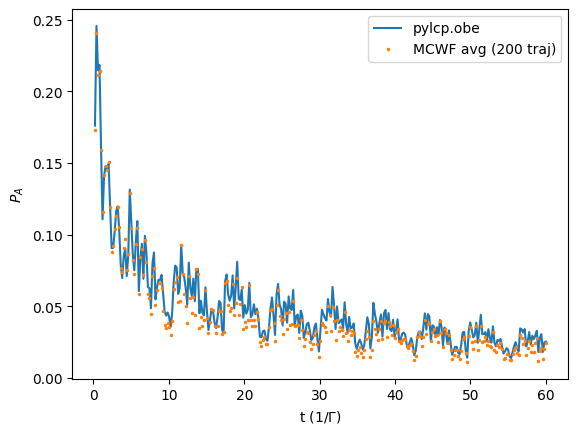

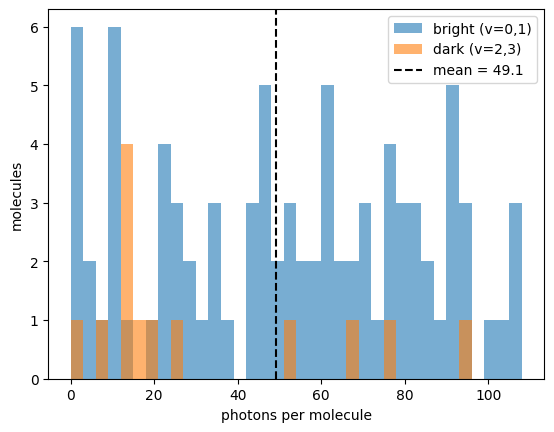

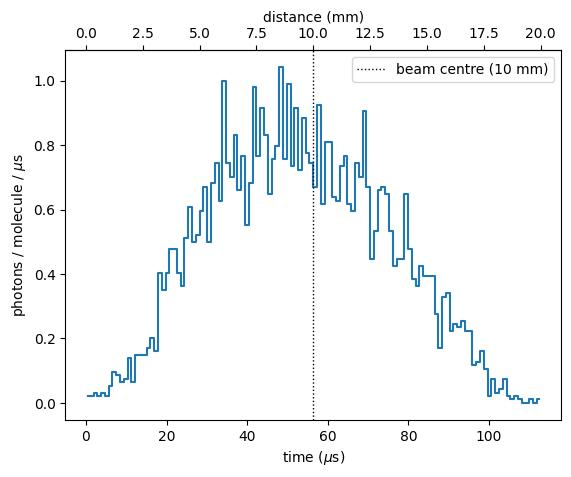

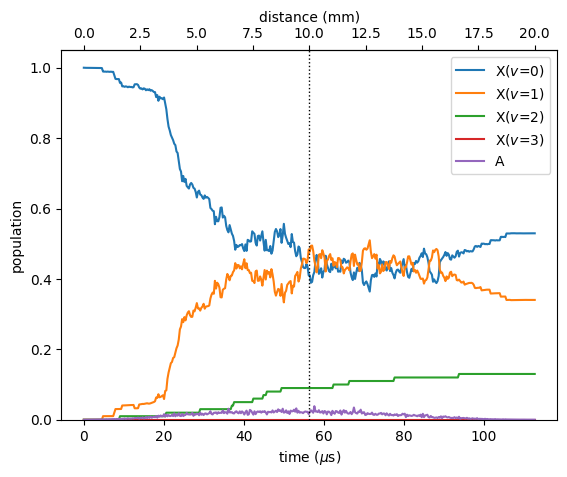


This took 2234.9897298812866 s to run


In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate. 
 
The Monte-Carlo wavefunction (MCWF / quantum-jump) method gives both:
a 52-dimensional wavefunction evolves under the non-Hermitian
H_eff(t) = H(t) - (i/2) * P_excited, and each quantum jump IS a
spontaneously emitted photon whose decay channel (FCF-weighted dipole)
decides the vibrational branch. Trajectory-averaged it is mathematically
equivalent to the OBE; trajectory-by-trajectory it is a photon counting
record -- exactly the lab observable.
 
Implementation notes
--------------------
* H(t) is built from pyLCP's own `hamiltonian.return_full_H` and each
  beam's `electric_field`, so all conventions (dipole normalisation,
  polarisation, Zeeman, field amplitude <-> s) are identical to pyLCP's
  OBE by construction. The code asserts this and additionally validates
  the trajectory average against `pylcp.obe` on a reduced system.
* Sideband-sideband and counter-propagating-beam interference is fully
  coherent. The standing-wave phase is sampled by giving each molecule a
  random transverse position x0 (the lab average over the beam).
* Finite laser linewidth is included as phase diffusion, common to all
  sidebands of one colour (they come from one laser + EOM); this
  partially destabilises coherent dark states, as in the real experiment.
* Polarisation: as in the experiment, the light is LINEARLY polarised
  and an electro-optic modulator (Pockels cell) switches it between two
  orthogonal linear polarisations (here y-hat and z-hat, both
  perpendicular to k // x) with a square wave at f_EOM. This is
  implemented by giving every physical beam two static-polarisation
  pyLCP beams (so all field conventions still come from pyLCP) and
  gating them on/off in the MCWF right-hand side; each molecule sees a
  random phase of the switching cycle. Polarisation switching remixes
  Zeeman dark states in addition to the B-field.
"""

import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt
import time

t_begin = time.time()

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 100                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

time_bin = 8.46e-3 # s

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.933, 0.066, 3e-3, 2.5e-4])
fcf = fcf / np.sum(fcf, axis=0)
fcf_sum = np.sum(fcf, axis=0)
assert fcf_sum - 1. < 1e-15, f"FCF factors {fcf_sum} don't sum to 1"
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 10*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
"""
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat
"""
def power_to_s(P_total, fracs, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    fracs = np.asarray(fracs, dtype=float)
    fracs = fracs/fracs.sum()
    return (P_total*fracs)/(2*np.pi*sigma_m**2)/I_sat


V1_ON = True

frac_p1 = np.array([50, 12.5, 12.5, 25])
frac_v1 = np.array([50, 12.5, 12.5, 25])

P_p1 = 105e-3
P_v1 = 100e-3
s_p1 = power_to_s(P_p1, frac_p1, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, frac_v1, sigma_m, w_v1)
print("peak s per sideband: main", np.array2string(s_p1, precision=1),
      " repump", np.array2string(s_v1, precision=1))
print(f"P1 power {P_p1} W")
print(f"V1 power {P_v1} W")
# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 754e3
linewidth_v1_Hz = 541e3
gL_p1 = np.pi*linewidth_p1_Hz*tau   # pi*FWHM * tau = phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau

# EOM polarisation switching: linear polarisation toggled between
# y-hat and z-hat (both perp. to k // x) with a 50% duty-cycle square
# wave at f_EOM. Set to the experimental switching frequency.
f_EOM = 900000                           # Hz
T_switch = 1./(f_EOM*tau)              # full period in units of 1/Gamma
T_half_pol = 0.5*T_switch              # half period (one pol on at a time)
print(f"EOM pol switching: {f_EOM/1e6:.2f} MHz "
      f"(half-period {T_half_pol:.1f} /Gamma)")


R_ap = 5*mm                      # 5 mm aperture radius
y0_arr = np.zeros(N_MC)
# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
# V=0
H0_X[0], Bq_X[0], U_X[0], X_bases[0] = pylcp.hamiltonians.XFmolecules.Xstate(
    N=1, I=1/2, B=7233.8271, gamma=-13.41679,
    b=(170.26374-85.4208/3), 
    c=85.4208, CI=0.02038, q0=0, q2=0,
    gS=2.0023193043622, gI=0.,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
    )
#V=1,2,3
for v in range(3):
    H0, Bq, U, Xbasis = pylcp.hamiltonians.XFmolecules.Xstate(
        N=1, I=1/2, B=7188.8919, gamma=-33.81036, 
        b=(168.770 - 86.7120/3), 
        c=86.7120, CI=0.02038, q0=0, q2=0,
        gS=2.0023193043622, gI = 0.0,
        muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
        )
    H0_X[v+1], Bq_X[v+1], U_X[v+1], X_bases[v+1] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = pylcp.hamiltonians.XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=(3/2*4.8), glprime=-3*.0211,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
    )
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each, maps 4 excited A amplitudes down into the 12 sublevels of ground manifold v, for emitted polarization q.

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

# The two orthogonal linear polarisations the EOM switches between.
# Beams propagate along +/-x, so both y-hat and z-hat are transverse.
# z-hat drives pi transitions, y-hat drives (sigma+ + sigma-)/sqrt(2).
POL_EOM = (np.array([0., 1., 0.]), np.array([0., 0., 1.]))

def beam_pair(k, s_arr, deltas, s_scale=1.0):
    """Each physical beam is entered twice, once per EOM polarisation
    state (pol group 0 = y-hat, 1 = z-hat). In the MCWF the two are
    gated on/off in antiphase (square wave); for the rate-equation
    reference use s_scale=0.5 with both on, i.e. the time average."""
    beams = []
    s_arr = np.broadcast_to(np.asarray(s_arr, float), np.shape(deltas))
    for delta, s_max in zip(deltas, s_arr):
        for sign in (+1, -1):
            for pol_vec in POL_EOM:
                beams.append({'kvec': np.array([sign*k, 0., 0.]),
                              'pol': pol_vec.copy(),
                              'pol_coord': 'cartesian',
                              'delta': delta,
                              's': crossed_beam_s(s_scale*s_max,
                                                  w_beam, z_laser)})

    return pylcp.laserBeams(beams)

def polgrp_for(n_deltas):
    """Pol-group index (0=y, 1=z) per beam, matching beam_pair order."""
    return np.array([p for _ in range(n_deltas) for _ in (0, 1)
                     for p in (0, 1)], dtype=np.int64)

def hf_levels(H0):
    """Unique hyperfine energies (in Gamma units) + degeneracies."""
    E, cnt = np.unique(np.round(np.diag(H0), 6), return_counts=True)
    return E/gamma_MHz, cnt

E_X0_hf, cnt_X0 = hf_levels(H0_X[0])
E_X1_hf, cnt_X1 = hf_levels(H0_X[1])
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz

deltas_p1 = E_A_F1 - E_X0_hf + det_p1
deltas_v1 = E_A_F1 - E_X1_hf + det_v1          # <-- v=1 energies, not v=0
assert len(deltas_p1) == 4 and len(deltas_v1) == 4, "hyperfine degeneracy split"

if V1_ON:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
                'X1->A': beam_pair(k_v1, s_v1, deltas_v1)
                }

    # Rate-equation reference: rateeq cannot gate beams in time, so use the
    # time average of the square wave -- both polarisations on at s/2.
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5),
                    'X1->A': beam_pair(k_v1, s_v1, deltas_v1, s_scale=0.5)
                 }
else:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1)}
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5)}

# F-label diagnostic (just in case)
F_of_count = {1: 'F=0', 3: 'F=1', 5: 'F=2'}
for tag, (E, cnt), fr, s_ in [('P1/X0', (E_X0_hf, cnt_X0), frac_p1, s_p1),
                              ('V1/X1', (E_X1_hf, cnt_X1), frac_v1, s_v1)]:
    print(f"{tag} sideband map:")
    for i, (Ei, ci) in enumerate(zip(E, cnt)):
        print(f"  [{i}] {F_of_count[ci]:4s} E={Ei*gamma_MHz:8.1f} MHz "
              f"frac={fr[i]/np.sum(fr):.3f}  s={s_[i]:.1f}")


B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)


v_forward = 1.5/time_bin/v_unit
print(f"Forward velocity {1.5/time_bin:.2f} ms^-1 with time bin {time_bin} s")
v_vec = np.array([0., 0., v_forward])
t_max = (20*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams_re, magField, ham,
                          include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ----------------------------------------------------------
# MCWF machinery
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
if V1_ON:
    key_row = {'X0->A': 0, 'X1->A': n_X}
else:
    key_row = {'X0->A': 0}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0, y0=0.):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, y0, z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
         phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2].

    EOM polarisation switching: beam b is on only while the square wave
    (half-period T_half, molecule-specific phase offset tsw0) selects
    its pol group polgrp[b]. T_half <= 0 disables gating (all beams on,
    used by the OBE cross-check)."""
    n = psi.shape[0]
    # H_static \psi
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        if T_half > 0.:
            if (np.int64((t + tsw0)//T_half) % 2) != polgrp[b]:
                continue
        # c_b(t) = env exp(i(\delta t + \phi_{colour}))
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                    Lops, Lv, vfw, zc, sig, gL, dt, T, seed,
                    tgrid, pops, jhist):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark).

    Additionally ACCUMULATES (+=, over the whole ensemble) into:
      pops[ig, 0:4] -- population in X(v=0..3) at tgrid[ig]
      pops[ig, 4]   -- population in A at tgrid[ig]
      jhist[jb]     -- photon emission times, binned uniformly on [0, T]
    Divide both by N_MC afterwards."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    nX1 = Lops.shape[1]                 # states per X manifold (12)
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    # molecules arrive at a random phase of the EOM switching cycle
    tsw0 = 0.
    if T_half > 0.:
        tsw0 = np.random.random()*2.*T_half
    t = 0.
    ig = 0
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
             phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            # Choose channel
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            # \psi_new = C \psi
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            # Normalise
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            # bin the emission time (CCD signal ~ z = v*t)
            jb = np.int64(t/T*jhist.shape[0])
            if jb >= jhist.shape[0]:
                jb = jhist.shape[0] - 1
            jhist[jb] += 1.
            # dark vibrational state: population frozen in X(v)
            if V1_ON:
                if v >= 2:               
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            else:
                if v >= 1:
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            rjump = np.random.random()
            nrm = 1.
        elif nrm > 1e-30:
            pass
        # sample manifold populations on the output grid
        while ig < tgrid.shape[0] and t >= tgrid[ig]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # tail: fill any grid points beyond the last integration step
    if ig < tgrid.shape[0]:
        nrm = 0.
        for i in range(n):
            nrm += psi[i].real**2 + psi[i].imag**2
        while ig < tgrid.shape[0]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ---------------------------------------------------------
# Validation: MCWF trajectory average vs pylcp.obe

# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    # pylcp.obe cannot gate polarisations in time, so the cross-check is
    # run with switching DISABLED (T_half = -1): both linear pols on
    # simultaneously in both MCWF and OBE. This still validates every
    # field/phase/Zeeman/jump convention, which is pol-independent.
    pol_r = polgrp_for(len(deltas_p1))
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, 0.,
                 phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
                 0., phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         pol_r, -1.0, L_red, Lv_red, DT, tgrid,
                         int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation_nov1.png', dpi=150)

# -------------------------------------------------------
# Production: full 52-state transit ensemble
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
# 16 main + 16 repump beams (4 sidebands x 2 directions x 2 EOM pols)
colour_arr = np.array([0]*16 + [1]*16, dtype=np.int64)
polgrp_arr = np.concatenate([polgrp_for(len(deltas_p1)),
                             polgrp_for(len(deltas_v1))])
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)

# ensemble-accumulated observables (filled in-place by mcwf_trajectory)
n_tg = 400
tgrid_pop = np.linspace(0., t_max, n_tg)     # population sampling grid
pop_acc = np.zeros((n_tg, 5))                # X0..X3, A
n_jbins = 120
jump_hist = np.zeros(n_jbins)                # photon emission times

for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    y0 = R_ap*np.sqrt(rng.random())*np.sin(2*np.pi*rng.random())
    y0_arr[m] = y0
    Mb, rows, dels = extract_beam_blocks(x0, y0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, polgrp_arr, T_half_pol,
                                 L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)),
                                 tgrid_pop, pop_acc, jump_hist)
    photons[m], v_final[m] = nph, vf
    if (m+1) % 10 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

pop_acc /= N_MC                              # ensemble-average populations

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf_nov1.png', dpi=150)

# ---------------------------------------------------------
# Photon emission rate vs time / distance (what a CCD along z sees).
# Molecules fly at constant v_forward, so z = v*t maps time directly
# onto position; the top axis is distance from the start (beam centre
# marked at z_laser).
v_real = v_forward*v_unit                    # m/s
t_to_us = tau*1e6                            # sim time -> microseconds
us_to_mm = v_real*1e-3                       # 100 m/s = 0.10 mm/us

dt_bin = t_max/n_jbins
t_cent_us = (np.arange(n_jbins) + 0.5)*dt_bin*t_to_us
rate = jump_hist/N_MC/(dt_bin*t_to_us)       # photons /molecule /us

fig2, ax2 = plt.subplots()
ax2.plot(t_cent_us, rate, drawstyle='steps-mid')
ax2.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1,
            label=f'beam centre ({z_laser/mm:.0f} mm)')
ax2.set_xlabel(r'time ($\mu$s)')
ax2.set_ylabel(r'photons / molecule / $\mu$s')
secax2 = ax2.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax2.set_xlabel('distance (mm)')
ax2.legend()
fig2.savefig('photon_rate_vs_time_mcwf.png', dpi=150)

# ---------------------------------------------------------
# Ensemble-averaged populations vs time (X manifolds and A)
fig3, ax3 = plt.subplots()
t_pop_us = tgrid_pop*t_to_us
pop_labels = [r'X($v$=0)', r'X($v$=1)', r'X($v$=2)', r'X($v$=3)', 'A']
for ip in range(5):
    ax3.plot(t_pop_us, pop_acc[:, ip], label=pop_labels[ip])
ax3.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1)
ax3.set_xlabel(r'time ($\mu$s)')
ax3.set_ylabel('population')
ax3.set_ylim(bottom=0.)
secax3 = ax3.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax3.set_xlabel('distance (mm)')
ax3.legend()
fig3.savefig('populations_vs_time_mcwf.png', dpi=150)

plt.show()

print(f"\nThis took {time.time() - t_begin} s to run")

energy unit: Gamma/2pi = 5.684 MHz
peak s per sideband: main [30.3  7.6  7.6 15.1]  repump [13.8  3.5  3.5  6.9]
P1 power 0.105 W
V1 power 0.044 W
EOM pol switching: 0.90 MHz (half-period 19.8 /Gamma)
P1/X0 sideband map:
  [0] F=1  E=  -128.2 MHz frac=0.500  s=30.3
  [1] F=0  E=    27.5 MHz frac=0.125  s=7.6
  [2] F=2  E=    33.0 MHz frac=0.125  s=7.6
  [3] F=1  E=    64.0 MHz frac=0.250  s=15.1
V1/X1 sideband map:
  [0] F=1  E=  -129.4 MHz frac=0.500  s=13.8
  [1] F=2  E=    22.4 MHz frac=0.125  s=3.5
  [2] F=0  E=    47.1 MHz frac=0.125  s=3.5
  [3] F=1  E=    76.4 MHz frac=0.250  s=6.9
Forward velocity 177.30 ms^-1 with time bin 0.00846 s

rate-equation reference: 130.8 photons (expected to overestimate)

--- validating MCWF against pylcp.obe (reduced X0+A system) ---
max |P_A(MCWF avg, 200 traj) - P_A(OBE)| = 0.0138 (peak P_A ~ 0.246)

--- MCWF ensemble: 100 molecules through the beams ---
  10/100: running mean = 38.9
  20/100: running mean = 38.4
  30/100: running mean = 40.9
  4

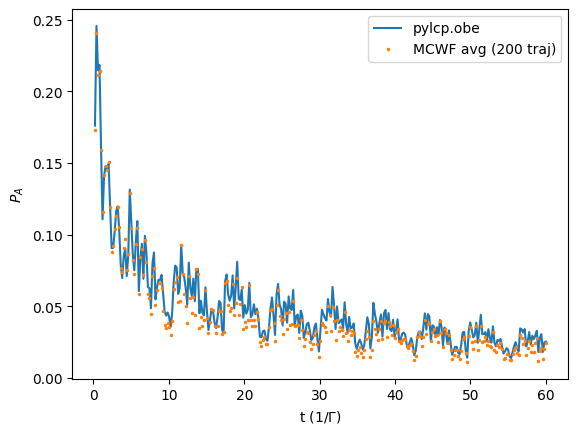

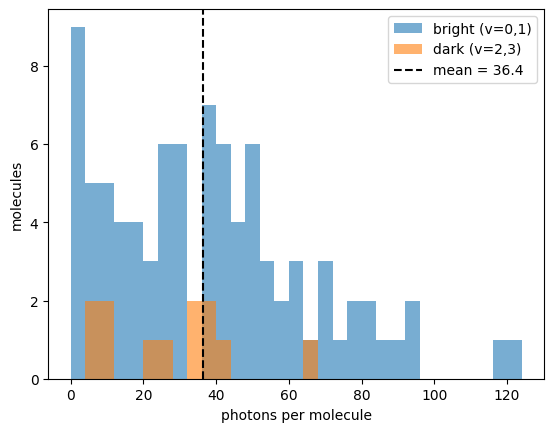

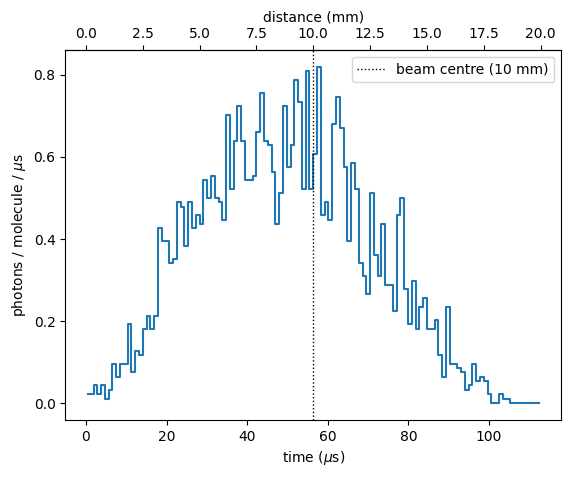

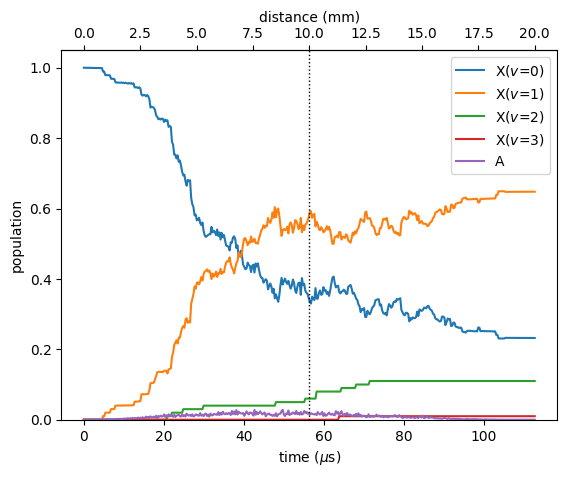


This took 2234.7535829544067 s to run


In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate. 
 
The Monte-Carlo wavefunction (MCWF / quantum-jump) method gives both:
a 52-dimensional wavefunction evolves under the non-Hermitian
H_eff(t) = H(t) - (i/2) * P_excited, and each quantum jump IS a
spontaneously emitted photon whose decay channel (FCF-weighted dipole)
decides the vibrational branch. Trajectory-averaged it is mathematically
equivalent to the OBE; trajectory-by-trajectory it is a photon counting
record -- exactly the lab observable.
 
Implementation notes
--------------------
* H(t) is built from pyLCP's own `hamiltonian.return_full_H` and each
  beam's `electric_field`, so all conventions (dipole normalisation,
  polarisation, Zeeman, field amplitude <-> s) are identical to pyLCP's
  OBE by construction. The code asserts this and additionally validates
  the trajectory average against `pylcp.obe` on a reduced system.
* Sideband-sideband and counter-propagating-beam interference is fully
  coherent. The standing-wave phase is sampled by giving each molecule a
  random transverse position x0 (the lab average over the beam).
* Finite laser linewidth is included as phase diffusion, common to all
  sidebands of one colour (they come from one laser + EOM); this
  partially destabilises coherent dark states, as in the real experiment.
* Polarisation: as in the experiment, the light is LINEARLY polarised
  and an electro-optic modulator (Pockels cell) switches it between two
  orthogonal linear polarisations (here y-hat and z-hat, both
  perpendicular to k // x) with a square wave at f_EOM. This is
  implemented by giving every physical beam two static-polarisation
  pyLCP beams (so all field conventions still come from pyLCP) and
  gating them on/off in the MCWF right-hand side; each molecule sees a
  random phase of the switching cycle. Polarisation switching remixes
  Zeeman dark states in addition to the B-field.
"""

import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt
import time

t_begin = time.time()

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 100                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

time_bin = 8.46e-3 # s

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.933, 0.066, 3e-3, 2.5e-4])
fcf = fcf / np.sum(fcf, axis=0)
fcf_sum = np.sum(fcf, axis=0)
assert fcf_sum - 1. < 1e-15, f"FCF factors {fcf_sum} don't sum to 1"
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 10*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
"""
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat
"""
def power_to_s(P_total, fracs, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    fracs = np.asarray(fracs, dtype=float)
    fracs = fracs/fracs.sum()
    return (P_total*fracs)/(2*np.pi*sigma_m**2)/I_sat


V1_ON = True

frac_p1 = np.array([50, 12.5, 12.5, 25])
frac_v1 = np.array([50, 12.5, 12.5, 25])

P_p1 = 105e-3
P_v1 = 44e-3
s_p1 = power_to_s(P_p1, frac_p1, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, frac_v1, sigma_m, w_v1)
print("peak s per sideband: main", np.array2string(s_p1, precision=1),
      " repump", np.array2string(s_v1, precision=1))
print(f"P1 power {P_p1} W")
print(f"V1 power {P_v1} W")
# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 754e3
linewidth_v1_Hz = 541e3
gL_p1 = np.pi*linewidth_p1_Hz*tau   # pi*FWHM * tau = phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau

# EOM polarisation switching: linear polarisation toggled between
# y-hat and z-hat (both perp. to k // x) with a 50% duty-cycle square
# wave at f_EOM. Set to the experimental switching frequency.
f_EOM = 900000                           # Hz
T_switch = 1./(f_EOM*tau)              # full period in units of 1/Gamma
T_half_pol = 0.5*T_switch              # half period (one pol on at a time)
print(f"EOM pol switching: {f_EOM/1e6:.2f} MHz "
      f"(half-period {T_half_pol:.1f} /Gamma)")


R_ap = 5*mm                      # 5 mm aperture radius
y0_arr = np.zeros(N_MC)
# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
# V=0
H0_X[0], Bq_X[0], U_X[0], X_bases[0] = pylcp.hamiltonians.XFmolecules.Xstate(
    N=1, I=1/2, B=7233.8271, gamma=-13.41679,
    b=(170.26374-85.4208/3), 
    c=85.4208, CI=0.02038, q0=0, q2=0,
    gS=2.0023193043622, gI=0.,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
    )
#V=1,2,3
for v in range(3):
    H0, Bq, U, Xbasis = pylcp.hamiltonians.XFmolecules.Xstate(
        N=1, I=1/2, B=7188.8919, gamma=-33.81036, 
        b=(168.770 - 86.7120/3), 
        c=86.7120, CI=0.02038, q0=0, q2=0,
        gS=2.0023193043622, gI = 0.0,
        muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
        )
    H0_X[v+1], Bq_X[v+1], U_X[v+1], X_bases[v+1] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = pylcp.hamiltonians.XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=(3/2*4.8), glprime=-3*.0211,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
    )
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each, maps 4 excited A amplitudes down into the 12 sublevels of ground manifold v, for emitted polarization q.

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

# The two orthogonal linear polarisations the EOM switches between.
# Beams propagate along +/-x, so both y-hat and z-hat are transverse.
# z-hat drives pi transitions, y-hat drives (sigma+ + sigma-)/sqrt(2).
POL_EOM = (np.array([0., 1., 0.]), np.array([0., 0., 1.]))

def beam_pair(k, s_arr, deltas, s_scale=1.0):
    """Each physical beam is entered twice, once per EOM polarisation
    state (pol group 0 = y-hat, 1 = z-hat). In the MCWF the two are
    gated on/off in antiphase (square wave); for the rate-equation
    reference use s_scale=0.5 with both on, i.e. the time average."""
    beams = []
    s_arr = np.broadcast_to(np.asarray(s_arr, float), np.shape(deltas))
    for delta, s_max in zip(deltas, s_arr):
        for sign in (+1, -1):
            for pol_vec in POL_EOM:
                beams.append({'kvec': np.array([sign*k, 0., 0.]),
                              'pol': pol_vec.copy(),
                              'pol_coord': 'cartesian',
                              'delta': delta,
                              's': crossed_beam_s(s_scale*s_max,
                                                  w_beam, z_laser)})

    return pylcp.laserBeams(beams)

def polgrp_for(n_deltas):
    """Pol-group index (0=y, 1=z) per beam, matching beam_pair order."""
    return np.array([p for _ in range(n_deltas) for _ in (0, 1)
                     for p in (0, 1)], dtype=np.int64)

def hf_levels(H0):
    """Unique hyperfine energies (in Gamma units) + degeneracies."""
    E, cnt = np.unique(np.round(np.diag(H0), 6), return_counts=True)
    return E/gamma_MHz, cnt

E_X0_hf, cnt_X0 = hf_levels(H0_X[0])
E_X1_hf, cnt_X1 = hf_levels(H0_X[1])
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz

deltas_p1 = E_A_F1 - E_X0_hf + det_p1
deltas_v1 = E_A_F1 - E_X1_hf + det_v1          # <-- v=1 energies, not v=0
assert len(deltas_p1) == 4 and len(deltas_v1) == 4, "hyperfine degeneracy split"

if V1_ON:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
                'X1->A': beam_pair(k_v1, s_v1, deltas_v1)
                }

    # Rate-equation reference: rateeq cannot gate beams in time, so use the
    # time average of the square wave -- both polarisations on at s/2.
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5),
                    'X1->A': beam_pair(k_v1, s_v1, deltas_v1, s_scale=0.5)
                 }
else:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1)}
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5)}

# F-label diagnostic (just in case)
F_of_count = {1: 'F=0', 3: 'F=1', 5: 'F=2'}
for tag, (E, cnt), fr, s_ in [('P1/X0', (E_X0_hf, cnt_X0), frac_p1, s_p1),
                              ('V1/X1', (E_X1_hf, cnt_X1), frac_v1, s_v1)]:
    print(f"{tag} sideband map:")
    for i, (Ei, ci) in enumerate(zip(E, cnt)):
        print(f"  [{i}] {F_of_count[ci]:4s} E={Ei*gamma_MHz:8.1f} MHz "
              f"frac={fr[i]/np.sum(fr):.3f}  s={s_[i]:.1f}")


B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)


v_forward = 1.5/time_bin/v_unit
print(f"Forward velocity {1.5/time_bin:.2f} ms^-1 with time bin {time_bin} s")
v_vec = np.array([0., 0., v_forward])
t_max = (20*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams_re, magField, ham,
                          include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ----------------------------------------------------------
# MCWF machinery
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
if V1_ON:
    key_row = {'X0->A': 0, 'X1->A': n_X}
else:
    key_row = {'X0->A': 0}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0, y0=0.):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, y0, z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
         phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2].

    EOM polarisation switching: beam b is on only while the square wave
    (half-period T_half, molecule-specific phase offset tsw0) selects
    its pol group polgrp[b]. T_half <= 0 disables gating (all beams on,
    used by the OBE cross-check)."""
    n = psi.shape[0]
    # H_static \psi
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        if T_half > 0.:
            if (np.int64((t + tsw0)//T_half) % 2) != polgrp[b]:
                continue
        # c_b(t) = env exp(i(\delta t + \phi_{colour}))
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                    Lops, Lv, vfw, zc, sig, gL, dt, T, seed,
                    tgrid, pops, jhist):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark).

    Additionally ACCUMULATES (+=, over the whole ensemble) into:
      pops[ig, 0:4] -- population in X(v=0..3) at tgrid[ig]
      pops[ig, 4]   -- population in A at tgrid[ig]
      jhist[jb]     -- photon emission times, binned uniformly on [0, T]
    Divide both by N_MC afterwards."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    nX1 = Lops.shape[1]                 # states per X manifold (12)
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    # molecules arrive at a random phase of the EOM switching cycle
    tsw0 = 0.
    if T_half > 0.:
        tsw0 = np.random.random()*2.*T_half
    t = 0.
    ig = 0
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
             phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            # Choose channel
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            # \psi_new = C \psi
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            # Normalise
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            # bin the emission time (CCD signal ~ z = v*t)
            jb = np.int64(t/T*jhist.shape[0])
            if jb >= jhist.shape[0]:
                jb = jhist.shape[0] - 1
            jhist[jb] += 1.
            # dark vibrational state: population frozen in X(v)
            if V1_ON:
                if v >= 2:               
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            else:
                if v >= 1:
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            rjump = np.random.random()
            nrm = 1.
        elif nrm > 1e-30:
            pass
        # sample manifold populations on the output grid
        while ig < tgrid.shape[0] and t >= tgrid[ig]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # tail: fill any grid points beyond the last integration step
    if ig < tgrid.shape[0]:
        nrm = 0.
        for i in range(n):
            nrm += psi[i].real**2 + psi[i].imag**2
        while ig < tgrid.shape[0]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ---------------------------------------------------------
# Validation: MCWF trajectory average vs pylcp.obe

# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    # pylcp.obe cannot gate polarisations in time, so the cross-check is
    # run with switching DISABLED (T_half = -1): both linear pols on
    # simultaneously in both MCWF and OBE. This still validates every
    # field/phase/Zeeman/jump convention, which is pol-independent.
    pol_r = polgrp_for(len(deltas_p1))
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, 0.,
                 phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
                 0., phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         pol_r, -1.0, L_red, Lv_red, DT, tgrid,
                         int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation_nov1.png', dpi=150)

# -------------------------------------------------------
# Production: full 52-state transit ensemble
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
# 16 main + 16 repump beams (4 sidebands x 2 directions x 2 EOM pols)
colour_arr = np.array([0]*16 + [1]*16, dtype=np.int64)
polgrp_arr = np.concatenate([polgrp_for(len(deltas_p1)),
                             polgrp_for(len(deltas_v1))])
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)

# ensemble-accumulated observables (filled in-place by mcwf_trajectory)
n_tg = 400
tgrid_pop = np.linspace(0., t_max, n_tg)     # population sampling grid
pop_acc = np.zeros((n_tg, 5))                # X0..X3, A
n_jbins = 120
jump_hist = np.zeros(n_jbins)                # photon emission times

for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    y0 = R_ap*np.sqrt(rng.random())*np.sin(2*np.pi*rng.random())
    y0_arr[m] = y0
    Mb, rows, dels = extract_beam_blocks(x0, y0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, polgrp_arr, T_half_pol,
                                 L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)),
                                 tgrid_pop, pop_acc, jump_hist)
    photons[m], v_final[m] = nph, vf
    if (m+1) % 10 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

pop_acc /= N_MC                              # ensemble-average populations

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf_nov1.png', dpi=150)

# ---------------------------------------------------------
# Photon emission rate vs time / distance (what a CCD along z sees).
# Molecules fly at constant v_forward, so z = v*t maps time directly
# onto position; the top axis is distance from the start (beam centre
# marked at z_laser).
v_real = v_forward*v_unit                    # m/s
t_to_us = tau*1e6                            # sim time -> microseconds
us_to_mm = v_real*1e-3                       # 100 m/s = 0.10 mm/us

dt_bin = t_max/n_jbins
t_cent_us = (np.arange(n_jbins) + 0.5)*dt_bin*t_to_us
rate = jump_hist/N_MC/(dt_bin*t_to_us)       # photons /molecule /us

fig2, ax2 = plt.subplots()
ax2.plot(t_cent_us, rate, drawstyle='steps-mid')
ax2.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1,
            label=f'beam centre ({z_laser/mm:.0f} mm)')
ax2.set_xlabel(r'time ($\mu$s)')
ax2.set_ylabel(r'photons / molecule / $\mu$s')
secax2 = ax2.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax2.set_xlabel('distance (mm)')
ax2.legend()
fig2.savefig('photon_rate_vs_time_mcwf.png', dpi=150)

# ---------------------------------------------------------
# Ensemble-averaged populations vs time (X manifolds and A)
fig3, ax3 = plt.subplots()
t_pop_us = tgrid_pop*t_to_us
pop_labels = [r'X($v$=0)', r'X($v$=1)', r'X($v$=2)', r'X($v$=3)', 'A']
for ip in range(5):
    ax3.plot(t_pop_us, pop_acc[:, ip], label=pop_labels[ip])
ax3.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1)
ax3.set_xlabel(r'time ($\mu$s)')
ax3.set_ylabel('population')
ax3.set_ylim(bottom=0.)
secax3 = ax3.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax3.set_xlabel('distance (mm)')
ax3.legend()
fig3.savefig('populations_vs_time_mcwf.png', dpi=150)

plt.show()

print(f"\nThis took {time.time() - t_begin} s to run")

energy unit: Gamma/2pi = 5.684 MHz
peak s per sideband: main [30.3  7.6  7.6 15.1]  repump [9.4 2.4 2.4 4.7]
P1 power 0.105 W
V1 power 0.03 W
EOM pol switching: 0.90 MHz (half-period 19.8 /Gamma)
P1/X0 sideband map:
  [0] F=1  E=  -128.2 MHz frac=0.500  s=30.3
  [1] F=0  E=    27.5 MHz frac=0.125  s=7.6
  [2] F=2  E=    33.0 MHz frac=0.125  s=7.6
  [3] F=1  E=    64.0 MHz frac=0.250  s=15.1
V1/X1 sideband map:
  [0] F=1  E=  -129.4 MHz frac=0.500  s=9.4
  [1] F=2  E=    22.4 MHz frac=0.125  s=2.4
  [2] F=0  E=    47.1 MHz frac=0.125  s=2.4
  [3] F=1  E=    76.4 MHz frac=0.250  s=4.7
Forward velocity 177.30 ms^-1 with time bin 0.00846 s

rate-equation reference: 119.4 photons (expected to overestimate)

--- validating MCWF against pylcp.obe (reduced X0+A system) ---
max |P_A(MCWF avg, 200 traj) - P_A(OBE)| = 0.0138 (peak P_A ~ 0.246)

--- MCWF ensemble: 100 molecules through the beams ---
  10/100: running mean = 33.6
  20/100: running mean = 36.6
  30/100: running mean = 37.1
  40/100:

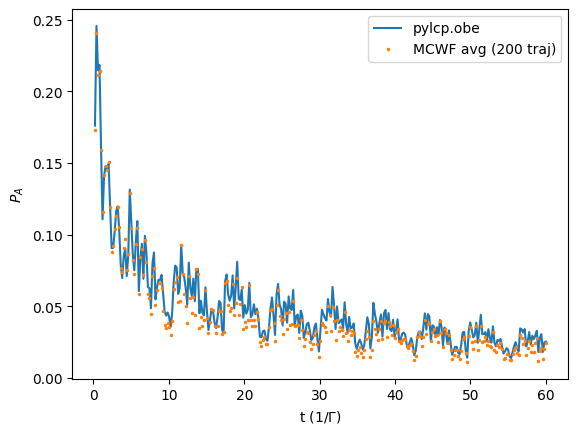

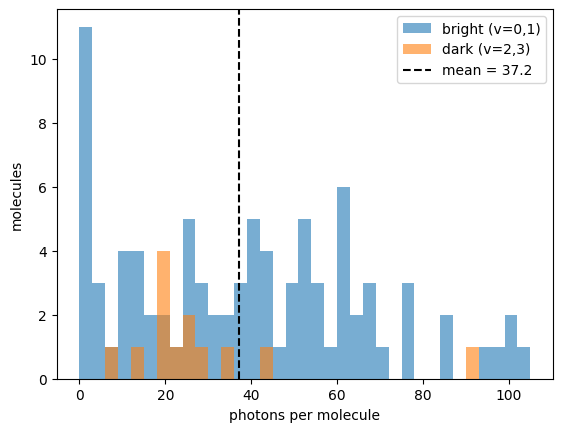

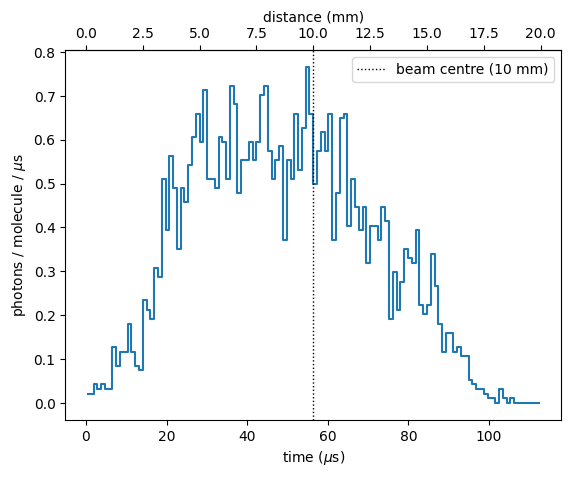

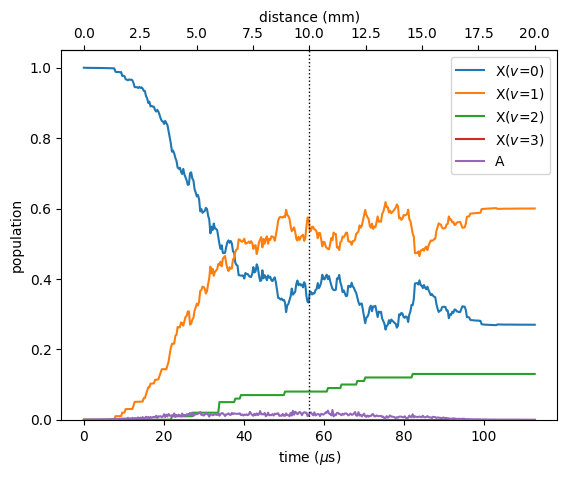


This took 2150.743434906006 s to run


In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate. 
 
The Monte-Carlo wavefunction (MCWF / quantum-jump) method gives both:
a 52-dimensional wavefunction evolves under the non-Hermitian
H_eff(t) = H(t) - (i/2) * P_excited, and each quantum jump IS a
spontaneously emitted photon whose decay channel (FCF-weighted dipole)
decides the vibrational branch. Trajectory-averaged it is mathematically
equivalent to the OBE; trajectory-by-trajectory it is a photon counting
record -- exactly the lab observable.
 
Implementation notes
--------------------
* H(t) is built from pyLCP's own `hamiltonian.return_full_H` and each
  beam's `electric_field`, so all conventions (dipole normalisation,
  polarisation, Zeeman, field amplitude <-> s) are identical to pyLCP's
  OBE by construction. The code asserts this and additionally validates
  the trajectory average against `pylcp.obe` on a reduced system.
* Sideband-sideband and counter-propagating-beam interference is fully
  coherent. The standing-wave phase is sampled by giving each molecule a
  random transverse position x0 (the lab average over the beam).
* Finite laser linewidth is included as phase diffusion, common to all
  sidebands of one colour (they come from one laser + EOM); this
  partially destabilises coherent dark states, as in the real experiment.
* Polarisation: as in the experiment, the light is LINEARLY polarised
  and an electro-optic modulator (Pockels cell) switches it between two
  orthogonal linear polarisations (here y-hat and z-hat, both
  perpendicular to k // x) with a square wave at f_EOM. This is
  implemented by giving every physical beam two static-polarisation
  pyLCP beams (so all field conventions still come from pyLCP) and
  gating them on/off in the MCWF right-hand side; each molecule sees a
  random phase of the switching cycle. Polarisation switching remixes
  Zeeman dark states in addition to the B-field.
"""

import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt
import time

t_begin = time.time()

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 100                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

time_bin = 8.46e-3 # s

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.933, 0.066, 3e-3, 2.5e-4])
fcf = fcf / np.sum(fcf, axis=0)
fcf_sum = np.sum(fcf, axis=0)
assert fcf_sum - 1. < 1e-15, f"FCF factors {fcf_sum} don't sum to 1"
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 10*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
"""
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat
"""
def power_to_s(P_total, fracs, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    fracs = np.asarray(fracs, dtype=float)
    fracs = fracs/fracs.sum()
    return (P_total*fracs)/(2*np.pi*sigma_m**2)/I_sat


V1_ON = True

frac_p1 = np.array([50, 12.5, 12.5, 25])
frac_v1 = np.array([50, 12.5, 12.5, 25])

P_p1 = 105e-3
P_v1 = 30e-3
s_p1 = power_to_s(P_p1, frac_p1, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, frac_v1, sigma_m, w_v1)
print("peak s per sideband: main", np.array2string(s_p1, precision=1),
      " repump", np.array2string(s_v1, precision=1))
print(f"P1 power {P_p1} W")
print(f"V1 power {P_v1} W")
# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 754e3
linewidth_v1_Hz = 541e3
gL_p1 = np.pi*linewidth_p1_Hz*tau   # pi*FWHM * tau = phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau

# EOM polarisation switching: linear polarisation toggled between
# y-hat and z-hat (both perp. to k // x) with a 50% duty-cycle square
# wave at f_EOM. Set to the experimental switching frequency.
f_EOM = 900000                           # Hz
T_switch = 1./(f_EOM*tau)              # full period in units of 1/Gamma
T_half_pol = 0.5*T_switch              # half period (one pol on at a time)
print(f"EOM pol switching: {f_EOM/1e6:.2f} MHz "
      f"(half-period {T_half_pol:.1f} /Gamma)")


R_ap = 5*mm                      # 5 mm aperture radius
y0_arr = np.zeros(N_MC)
# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
# V=0
H0_X[0], Bq_X[0], U_X[0], X_bases[0] = pylcp.hamiltonians.XFmolecules.Xstate(
    N=1, I=1/2, B=7233.8271, gamma=-13.41679,
    b=(170.26374-85.4208/3), 
    c=85.4208, CI=0.02038, q0=0, q2=0,
    gS=2.0023193043622, gI=0.,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
    )
#V=1,2,3
for v in range(3):
    H0, Bq, U, Xbasis = pylcp.hamiltonians.XFmolecules.Xstate(
        N=1, I=1/2, B=7188.8919, gamma=-33.81036, 
        b=(168.770 - 86.7120/3), 
        c=86.7120, CI=0.02038, q0=0, q2=0,
        gS=2.0023193043622, gI = 0.0,
        muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
        )
    H0_X[v+1], Bq_X[v+1], U_X[v+1], X_bases[v+1] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = pylcp.hamiltonians.XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=(3/2*4.8), glprime=-3*.0211,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
    )
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each, maps 4 excited A amplitudes down into the 12 sublevels of ground manifold v, for emitted polarization q.

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

# The two orthogonal linear polarisations the EOM switches between.
# Beams propagate along +/-x, so both y-hat and z-hat are transverse.
# z-hat drives pi transitions, y-hat drives (sigma+ + sigma-)/sqrt(2).
POL_EOM = (np.array([0., 1., 0.]), np.array([0., 0., 1.]))

def beam_pair(k, s_arr, deltas, s_scale=1.0):
    """Each physical beam is entered twice, once per EOM polarisation
    state (pol group 0 = y-hat, 1 = z-hat). In the MCWF the two are
    gated on/off in antiphase (square wave); for the rate-equation
    reference use s_scale=0.5 with both on, i.e. the time average."""
    beams = []
    s_arr = np.broadcast_to(np.asarray(s_arr, float), np.shape(deltas))
    for delta, s_max in zip(deltas, s_arr):
        for sign in (+1, -1):
            for pol_vec in POL_EOM:
                beams.append({'kvec': np.array([sign*k, 0., 0.]),
                              'pol': pol_vec.copy(),
                              'pol_coord': 'cartesian',
                              'delta': delta,
                              's': crossed_beam_s(s_scale*s_max,
                                                  w_beam, z_laser)})

    return pylcp.laserBeams(beams)

def polgrp_for(n_deltas):
    """Pol-group index (0=y, 1=z) per beam, matching beam_pair order."""
    return np.array([p for _ in range(n_deltas) for _ in (0, 1)
                     for p in (0, 1)], dtype=np.int64)

def hf_levels(H0):
    """Unique hyperfine energies (in Gamma units) + degeneracies."""
    E, cnt = np.unique(np.round(np.diag(H0), 6), return_counts=True)
    return E/gamma_MHz, cnt

E_X0_hf, cnt_X0 = hf_levels(H0_X[0])
E_X1_hf, cnt_X1 = hf_levels(H0_X[1])
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz

deltas_p1 = E_A_F1 - E_X0_hf + det_p1
deltas_v1 = E_A_F1 - E_X1_hf + det_v1          # <-- v=1 energies, not v=0
assert len(deltas_p1) == 4 and len(deltas_v1) == 4, "hyperfine degeneracy split"

if V1_ON:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
                'X1->A': beam_pair(k_v1, s_v1, deltas_v1)
                }

    # Rate-equation reference: rateeq cannot gate beams in time, so use the
    # time average of the square wave -- both polarisations on at s/2.
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5),
                    'X1->A': beam_pair(k_v1, s_v1, deltas_v1, s_scale=0.5)
                 }
else:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1)}
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5)}

# F-label diagnostic (just in case)
F_of_count = {1: 'F=0', 3: 'F=1', 5: 'F=2'}
for tag, (E, cnt), fr, s_ in [('P1/X0', (E_X0_hf, cnt_X0), frac_p1, s_p1),
                              ('V1/X1', (E_X1_hf, cnt_X1), frac_v1, s_v1)]:
    print(f"{tag} sideband map:")
    for i, (Ei, ci) in enumerate(zip(E, cnt)):
        print(f"  [{i}] {F_of_count[ci]:4s} E={Ei*gamma_MHz:8.1f} MHz "
              f"frac={fr[i]/np.sum(fr):.3f}  s={s_[i]:.1f}")


B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)


v_forward = 1.5/time_bin/v_unit
print(f"Forward velocity {1.5/time_bin:.2f} ms^-1 with time bin {time_bin} s")
v_vec = np.array([0., 0., v_forward])
t_max = (20*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams_re, magField, ham,
                          include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ----------------------------------------------------------
# MCWF machinery
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
if V1_ON:
    key_row = {'X0->A': 0, 'X1->A': n_X}
else:
    key_row = {'X0->A': 0}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0, y0=0.):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, y0, z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
         phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2].

    EOM polarisation switching: beam b is on only while the square wave
    (half-period T_half, molecule-specific phase offset tsw0) selects
    its pol group polgrp[b]. T_half <= 0 disables gating (all beams on,
    used by the OBE cross-check)."""
    n = psi.shape[0]
    # H_static \psi
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        if T_half > 0.:
            if (np.int64((t + tsw0)//T_half) % 2) != polgrp[b]:
                continue
        # c_b(t) = env exp(i(\delta t + \phi_{colour}))
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                    Lops, Lv, vfw, zc, sig, gL, dt, T, seed,
                    tgrid, pops, jhist):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark).

    Additionally ACCUMULATES (+=, over the whole ensemble) into:
      pops[ig, 0:4] -- population in X(v=0..3) at tgrid[ig]
      pops[ig, 4]   -- population in A at tgrid[ig]
      jhist[jb]     -- photon emission times, binned uniformly on [0, T]
    Divide both by N_MC afterwards."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    nX1 = Lops.shape[1]                 # states per X manifold (12)
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    # molecules arrive at a random phase of the EOM switching cycle
    tsw0 = 0.
    if T_half > 0.:
        tsw0 = np.random.random()*2.*T_half
    t = 0.
    ig = 0
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
             phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            # Choose channel
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            # \psi_new = C \psi
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            # Normalise
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            # bin the emission time (CCD signal ~ z = v*t)
            jb = np.int64(t/T*jhist.shape[0])
            if jb >= jhist.shape[0]:
                jb = jhist.shape[0] - 1
            jhist[jb] += 1.
            # dark vibrational state: population frozen in X(v)
            if V1_ON:
                if v >= 2:               
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            else:
                if v >= 1:
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            rjump = np.random.random()
            nrm = 1.
        elif nrm > 1e-30:
            pass
        # sample manifold populations on the output grid
        while ig < tgrid.shape[0] and t >= tgrid[ig]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # tail: fill any grid points beyond the last integration step
    if ig < tgrid.shape[0]:
        nrm = 0.
        for i in range(n):
            nrm += psi[i].real**2 + psi[i].imag**2
        while ig < tgrid.shape[0]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ---------------------------------------------------------
# Validation: MCWF trajectory average vs pylcp.obe

# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    # pylcp.obe cannot gate polarisations in time, so the cross-check is
    # run with switching DISABLED (T_half = -1): both linear pols on
    # simultaneously in both MCWF and OBE. This still validates every
    # field/phase/Zeeman/jump convention, which is pol-independent.
    pol_r = polgrp_for(len(deltas_p1))
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, 0.,
                 phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
                 0., phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         pol_r, -1.0, L_red, Lv_red, DT, tgrid,
                         int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation_nov1.png', dpi=150)

# -------------------------------------------------------
# Production: full 52-state transit ensemble
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
# 16 main + 16 repump beams (4 sidebands x 2 directions x 2 EOM pols)
colour_arr = np.array([0]*16 + [1]*16, dtype=np.int64)
polgrp_arr = np.concatenate([polgrp_for(len(deltas_p1)),
                             polgrp_for(len(deltas_v1))])
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)

# ensemble-accumulated observables (filled in-place by mcwf_trajectory)
n_tg = 400
tgrid_pop = np.linspace(0., t_max, n_tg)     # population sampling grid
pop_acc = np.zeros((n_tg, 5))                # X0..X3, A
n_jbins = 120
jump_hist = np.zeros(n_jbins)                # photon emission times

for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    y0 = R_ap*np.sqrt(rng.random())*np.sin(2*np.pi*rng.random())
    y0_arr[m] = y0
    Mb, rows, dels = extract_beam_blocks(x0, y0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, polgrp_arr, T_half_pol,
                                 L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)),
                                 tgrid_pop, pop_acc, jump_hist)
    photons[m], v_final[m] = nph, vf
    if (m+1) % 10 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

pop_acc /= N_MC                              # ensemble-average populations

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf_nov1.png', dpi=150)

# ---------------------------------------------------------
# Photon emission rate vs time / distance (what a CCD along z sees).
# Molecules fly at constant v_forward, so z = v*t maps time directly
# onto position; the top axis is distance from the start (beam centre
# marked at z_laser).
v_real = v_forward*v_unit                    # m/s
t_to_us = tau*1e6                            # sim time -> microseconds
us_to_mm = v_real*1e-3                       # 100 m/s = 0.10 mm/us

dt_bin = t_max/n_jbins
t_cent_us = (np.arange(n_jbins) + 0.5)*dt_bin*t_to_us
rate = jump_hist/N_MC/(dt_bin*t_to_us)       # photons /molecule /us

fig2, ax2 = plt.subplots()
ax2.plot(t_cent_us, rate, drawstyle='steps-mid')
ax2.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1,
            label=f'beam centre ({z_laser/mm:.0f} mm)')
ax2.set_xlabel(r'time ($\mu$s)')
ax2.set_ylabel(r'photons / molecule / $\mu$s')
secax2 = ax2.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax2.set_xlabel('distance (mm)')
ax2.legend()
fig2.savefig('photon_rate_vs_time_mcwf.png', dpi=150)

# ---------------------------------------------------------
# Ensemble-averaged populations vs time (X manifolds and A)
fig3, ax3 = plt.subplots()
t_pop_us = tgrid_pop*t_to_us
pop_labels = [r'X($v$=0)', r'X($v$=1)', r'X($v$=2)', r'X($v$=3)', 'A']
for ip in range(5):
    ax3.plot(t_pop_us, pop_acc[:, ip], label=pop_labels[ip])
ax3.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1)
ax3.set_xlabel(r'time ($\mu$s)')
ax3.set_ylabel('population')
ax3.set_ylim(bottom=0.)
secax3 = ax3.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax3.set_xlabel('distance (mm)')
ax3.legend()
fig3.savefig('populations_vs_time_mcwf.png', dpi=150)

plt.show()

print(f"\nThis took {time.time() - t_begin} s to run")

energy unit: Gamma/2pi = 5.684 MHz
peak s per sideband: main [30.3  7.6  7.6 15.1]  repump [3.1 0.8 0.8 1.6]
P1 power 0.105 W
V1 power 0.01 W
EOM pol switching: 0.90 MHz (half-period 19.8 /Gamma)
P1/X0 sideband map:
  [0] F=1  E=  -128.2 MHz frac=0.500  s=30.3
  [1] F=0  E=    27.5 MHz frac=0.125  s=7.6
  [2] F=2  E=    33.0 MHz frac=0.125  s=7.6
  [3] F=1  E=    64.0 MHz frac=0.250  s=15.1
V1/X1 sideband map:
  [0] F=1  E=  -129.4 MHz frac=0.500  s=3.1
  [1] F=2  E=    22.4 MHz frac=0.125  s=0.8
  [2] F=0  E=    47.1 MHz frac=0.125  s=0.8
  [3] F=1  E=    76.4 MHz frac=0.250  s=1.6
Forward velocity 177.30 ms^-1 with time bin 0.00846 s

rate-equation reference: 81.6 photons (expected to overestimate)

--- validating MCWF against pylcp.obe (reduced X0+A system) ---
max |P_A(MCWF avg, 200 traj) - P_A(OBE)| = 0.0138 (peak P_A ~ 0.246)

--- MCWF ensemble: 100 molecules through the beams ---
  10/100: running mean = 23.4
  20/100: running mean = 30.6
  30/100: running mean = 29.1
  40/100: 

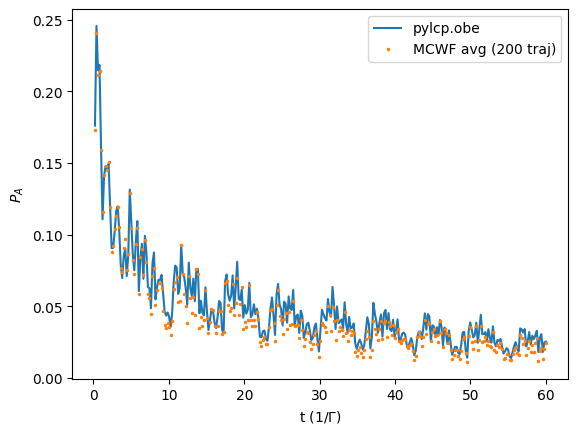

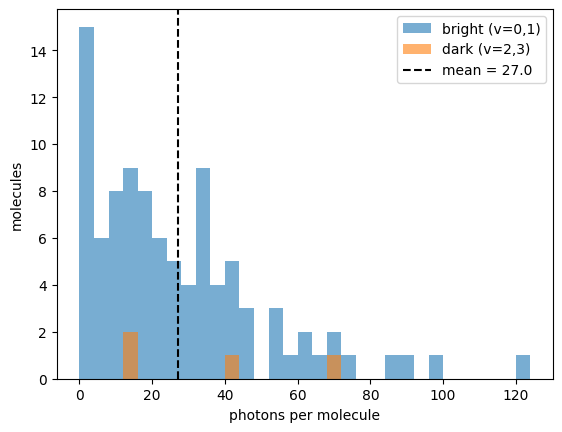

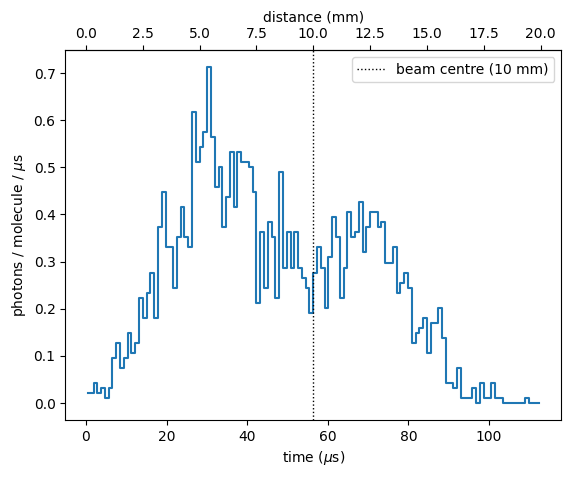

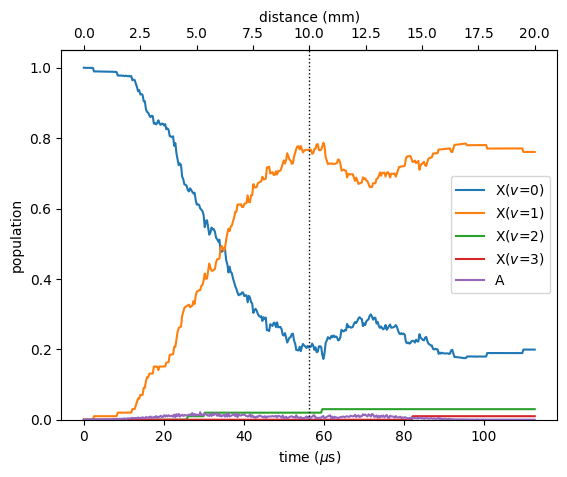


This took 2323.9457919597626 s to run


In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate. 
 
The Monte-Carlo wavefunction (MCWF / quantum-jump) method gives both:
a 52-dimensional wavefunction evolves under the non-Hermitian
H_eff(t) = H(t) - (i/2) * P_excited, and each quantum jump IS a
spontaneously emitted photon whose decay channel (FCF-weighted dipole)
decides the vibrational branch. Trajectory-averaged it is mathematically
equivalent to the OBE; trajectory-by-trajectory it is a photon counting
record -- exactly the lab observable.
 
Implementation notes
--------------------
* H(t) is built from pyLCP's own `hamiltonian.return_full_H` and each
  beam's `electric_field`, so all conventions (dipole normalisation,
  polarisation, Zeeman, field amplitude <-> s) are identical to pyLCP's
  OBE by construction. The code asserts this and additionally validates
  the trajectory average against `pylcp.obe` on a reduced system.
* Sideband-sideband and counter-propagating-beam interference is fully
  coherent. The standing-wave phase is sampled by giving each molecule a
  random transverse position x0 (the lab average over the beam).
* Finite laser linewidth is included as phase diffusion, common to all
  sidebands of one colour (they come from one laser + EOM); this
  partially destabilises coherent dark states, as in the real experiment.
* Polarisation: as in the experiment, the light is LINEARLY polarised
  and an electro-optic modulator (Pockels cell) switches it between two
  orthogonal linear polarisations (here y-hat and z-hat, both
  perpendicular to k // x) with a square wave at f_EOM. This is
  implemented by giving every physical beam two static-polarisation
  pyLCP beams (so all field conventions still come from pyLCP) and
  gating them on/off in the MCWF right-hand side; each molecule sees a
  random phase of the switching cycle. Polarisation switching remixes
  Zeeman dark states in addition to the B-field.
"""

import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt
import time

t_begin = time.time()

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 100                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

time_bin = 8.46e-3 # s

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.933, 0.066, 3e-3, 2.5e-4])
fcf = fcf / np.sum(fcf, axis=0)
fcf_sum = np.sum(fcf, axis=0)
assert fcf_sum - 1. < 1e-15, f"FCF factors {fcf_sum} don't sum to 1"
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 10*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
"""
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat
"""
def power_to_s(P_total, fracs, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    fracs = np.asarray(fracs, dtype=float)
    fracs = fracs/fracs.sum()
    return (P_total*fracs)/(2*np.pi*sigma_m**2)/I_sat


V1_ON = True

frac_p1 = np.array([50, 12.5, 12.5, 25])
frac_v1 = np.array([50, 12.5, 12.5, 25])

P_p1 = 105e-3
P_v1 = 10e-3
s_p1 = power_to_s(P_p1, frac_p1, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, frac_v1, sigma_m, w_v1)
print("peak s per sideband: main", np.array2string(s_p1, precision=1),
      " repump", np.array2string(s_v1, precision=1))
print(f"P1 power {P_p1} W")
print(f"V1 power {P_v1} W")
# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 754e3
linewidth_v1_Hz = 541e3
gL_p1 = np.pi*linewidth_p1_Hz*tau   # pi*FWHM * tau = phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau

# EOM polarisation switching: linear polarisation toggled between
# y-hat and z-hat (both perp. to k // x) with a 50% duty-cycle square
# wave at f_EOM. Set to the experimental switching frequency.
f_EOM = 900000                           # Hz
T_switch = 1./(f_EOM*tau)              # full period in units of 1/Gamma
T_half_pol = 0.5*T_switch              # half period (one pol on at a time)
print(f"EOM pol switching: {f_EOM/1e6:.2f} MHz "
      f"(half-period {T_half_pol:.1f} /Gamma)")


R_ap = 5*mm                      # 5 mm aperture radius
y0_arr = np.zeros(N_MC)
# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
# V=0
H0_X[0], Bq_X[0], U_X[0], X_bases[0] = pylcp.hamiltonians.XFmolecules.Xstate(
    N=1, I=1/2, B=7233.8271, gamma=-13.41679,
    b=(170.26374-85.4208/3), 
    c=85.4208, CI=0.02038, q0=0, q2=0,
    gS=2.0023193043622, gI=0.,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
    )
#V=1,2,3
for v in range(3):
    H0, Bq, U, Xbasis = pylcp.hamiltonians.XFmolecules.Xstate(
        N=1, I=1/2, B=7188.8919, gamma=-33.81036, 
        b=(168.770 - 86.7120/3), 
        c=86.7120, CI=0.02038, q0=0, q2=0,
        gS=2.0023193043622, gI = 0.0,
        muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
        )
    H0_X[v+1], Bq_X[v+1], U_X[v+1], X_bases[v+1] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = pylcp.hamiltonians.XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=(3/2*4.8), glprime=-3*.0211,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
    )
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each, maps 4 excited A amplitudes down into the 12 sublevels of ground manifold v, for emitted polarization q.

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

# The two orthogonal linear polarisations the EOM switches between.
# Beams propagate along +/-x, so both y-hat and z-hat are transverse.
# z-hat drives pi transitions, y-hat drives (sigma+ + sigma-)/sqrt(2).
POL_EOM = (np.array([0., 1., 0.]), np.array([0., 0., 1.]))

def beam_pair(k, s_arr, deltas, s_scale=1.0):
    """Each physical beam is entered twice, once per EOM polarisation
    state (pol group 0 = y-hat, 1 = z-hat). In the MCWF the two are
    gated on/off in antiphase (square wave); for the rate-equation
    reference use s_scale=0.5 with both on, i.e. the time average."""
    beams = []
    s_arr = np.broadcast_to(np.asarray(s_arr, float), np.shape(deltas))
    for delta, s_max in zip(deltas, s_arr):
        for sign in (+1, -1):
            for pol_vec in POL_EOM:
                beams.append({'kvec': np.array([sign*k, 0., 0.]),
                              'pol': pol_vec.copy(),
                              'pol_coord': 'cartesian',
                              'delta': delta,
                              's': crossed_beam_s(s_scale*s_max,
                                                  w_beam, z_laser)})

    return pylcp.laserBeams(beams)

def polgrp_for(n_deltas):
    """Pol-group index (0=y, 1=z) per beam, matching beam_pair order."""
    return np.array([p for _ in range(n_deltas) for _ in (0, 1)
                     for p in (0, 1)], dtype=np.int64)

def hf_levels(H0):
    """Unique hyperfine energies (in Gamma units) + degeneracies."""
    E, cnt = np.unique(np.round(np.diag(H0), 6), return_counts=True)
    return E/gamma_MHz, cnt

E_X0_hf, cnt_X0 = hf_levels(H0_X[0])
E_X1_hf, cnt_X1 = hf_levels(H0_X[1])
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz

deltas_p1 = E_A_F1 - E_X0_hf + det_p1
deltas_v1 = E_A_F1 - E_X1_hf + det_v1          # <-- v=1 energies, not v=0
assert len(deltas_p1) == 4 and len(deltas_v1) == 4, "hyperfine degeneracy split"

if V1_ON:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
                'X1->A': beam_pair(k_v1, s_v1, deltas_v1)
                }

    # Rate-equation reference: rateeq cannot gate beams in time, so use the
    # time average of the square wave -- both polarisations on at s/2.
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5),
                    'X1->A': beam_pair(k_v1, s_v1, deltas_v1, s_scale=0.5)
                 }
else:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1)}
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5)}

# F-label diagnostic (just in case)
F_of_count = {1: 'F=0', 3: 'F=1', 5: 'F=2'}
for tag, (E, cnt), fr, s_ in [('P1/X0', (E_X0_hf, cnt_X0), frac_p1, s_p1),
                              ('V1/X1', (E_X1_hf, cnt_X1), frac_v1, s_v1)]:
    print(f"{tag} sideband map:")
    for i, (Ei, ci) in enumerate(zip(E, cnt)):
        print(f"  [{i}] {F_of_count[ci]:4s} E={Ei*gamma_MHz:8.1f} MHz "
              f"frac={fr[i]/np.sum(fr):.3f}  s={s_[i]:.1f}")


B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)


v_forward = 1.5/time_bin/v_unit
print(f"Forward velocity {1.5/time_bin:.2f} ms^-1 with time bin {time_bin} s")
v_vec = np.array([0., 0., v_forward])
t_max = (20*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams_re, magField, ham,
                          include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ----------------------------------------------------------
# MCWF machinery
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
if V1_ON:
    key_row = {'X0->A': 0, 'X1->A': n_X}
else:
    key_row = {'X0->A': 0}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0, y0=0.):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, y0, z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
         phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2].

    EOM polarisation switching: beam b is on only while the square wave
    (half-period T_half, molecule-specific phase offset tsw0) selects
    its pol group polgrp[b]. T_half <= 0 disables gating (all beams on,
    used by the OBE cross-check)."""
    n = psi.shape[0]
    # H_static \psi
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        if T_half > 0.:
            if (np.int64((t + tsw0)//T_half) % 2) != polgrp[b]:
                continue
        # c_b(t) = env exp(i(\delta t + \phi_{colour}))
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                    Lops, Lv, vfw, zc, sig, gL, dt, T, seed,
                    tgrid, pops, jhist):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark).

    Additionally ACCUMULATES (+=, over the whole ensemble) into:
      pops[ig, 0:4] -- population in X(v=0..3) at tgrid[ig]
      pops[ig, 4]   -- population in A at tgrid[ig]
      jhist[jb]     -- photon emission times, binned uniformly on [0, T]
    Divide both by N_MC afterwards."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    nX1 = Lops.shape[1]                 # states per X manifold (12)
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    # molecules arrive at a random phase of the EOM switching cycle
    tsw0 = 0.
    if T_half > 0.:
        tsw0 = np.random.random()*2.*T_half
    t = 0.
    ig = 0
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
             phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            # Choose channel
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            # \psi_new = C \psi
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            # Normalise
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            # bin the emission time (CCD signal ~ z = v*t)
            jb = np.int64(t/T*jhist.shape[0])
            if jb >= jhist.shape[0]:
                jb = jhist.shape[0] - 1
            jhist[jb] += 1.
            # dark vibrational state: population frozen in X(v)
            if V1_ON:
                if v >= 2:               
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            else:
                if v >= 1:
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            rjump = np.random.random()
            nrm = 1.
        elif nrm > 1e-30:
            pass
        # sample manifold populations on the output grid
        while ig < tgrid.shape[0] and t >= tgrid[ig]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # tail: fill any grid points beyond the last integration step
    if ig < tgrid.shape[0]:
        nrm = 0.
        for i in range(n):
            nrm += psi[i].real**2 + psi[i].imag**2
        while ig < tgrid.shape[0]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ---------------------------------------------------------
# Validation: MCWF trajectory average vs pylcp.obe

# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    # pylcp.obe cannot gate polarisations in time, so the cross-check is
    # run with switching DISABLED (T_half = -1): both linear pols on
    # simultaneously in both MCWF and OBE. This still validates every
    # field/phase/Zeeman/jump convention, which is pol-independent.
    pol_r = polgrp_for(len(deltas_p1))
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, 0.,
                 phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
                 0., phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         pol_r, -1.0, L_red, Lv_red, DT, tgrid,
                         int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation_nov1.png', dpi=150)

# -------------------------------------------------------
# Production: full 52-state transit ensemble
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
# 16 main + 16 repump beams (4 sidebands x 2 directions x 2 EOM pols)
colour_arr = np.array([0]*16 + [1]*16, dtype=np.int64)
polgrp_arr = np.concatenate([polgrp_for(len(deltas_p1)),
                             polgrp_for(len(deltas_v1))])
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)

# ensemble-accumulated observables (filled in-place by mcwf_trajectory)
n_tg = 400
tgrid_pop = np.linspace(0., t_max, n_tg)     # population sampling grid
pop_acc = np.zeros((n_tg, 5))                # X0..X3, A
n_jbins = 120
jump_hist = np.zeros(n_jbins)                # photon emission times

for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    y0 = R_ap*np.sqrt(rng.random())*np.sin(2*np.pi*rng.random())
    y0_arr[m] = y0
    Mb, rows, dels = extract_beam_blocks(x0, y0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, polgrp_arr, T_half_pol,
                                 L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)),
                                 tgrid_pop, pop_acc, jump_hist)
    photons[m], v_final[m] = nph, vf
    if (m+1) % 10 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

pop_acc /= N_MC                              # ensemble-average populations

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf_nov1.png', dpi=150)

# ---------------------------------------------------------
# Photon emission rate vs time / distance (what a CCD along z sees).
# Molecules fly at constant v_forward, so z = v*t maps time directly
# onto position; the top axis is distance from the start (beam centre
# marked at z_laser).
v_real = v_forward*v_unit                    # m/s
t_to_us = tau*1e6                            # sim time -> microseconds
us_to_mm = v_real*1e-3                       # 100 m/s = 0.10 mm/us

dt_bin = t_max/n_jbins
t_cent_us = (np.arange(n_jbins) + 0.5)*dt_bin*t_to_us
rate = jump_hist/N_MC/(dt_bin*t_to_us)       # photons /molecule /us

fig2, ax2 = plt.subplots()
ax2.plot(t_cent_us, rate, drawstyle='steps-mid')
ax2.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1,
            label=f'beam centre ({z_laser/mm:.0f} mm)')
ax2.set_xlabel(r'time ($\mu$s)')
ax2.set_ylabel(r'photons / molecule / $\mu$s')
secax2 = ax2.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax2.set_xlabel('distance (mm)')
ax2.legend()
fig2.savefig('photon_rate_vs_time_mcwf.png', dpi=150)

# ---------------------------------------------------------
# Ensemble-averaged populations vs time (X manifolds and A)
fig3, ax3 = plt.subplots()
t_pop_us = tgrid_pop*t_to_us
pop_labels = [r'X($v$=0)', r'X($v$=1)', r'X($v$=2)', r'X($v$=3)', 'A']
for ip in range(5):
    ax3.plot(t_pop_us, pop_acc[:, ip], label=pop_labels[ip])
ax3.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1)
ax3.set_xlabel(r'time ($\mu$s)')
ax3.set_ylabel('population')
ax3.set_ylim(bottom=0.)
secax3 = ax3.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax3.set_xlabel('distance (mm)')
ax3.legend()
fig3.savefig('populations_vs_time_mcwf.png', dpi=150)

plt.show()

print(f"\nThis took {time.time() - t_begin} s to run")

energy unit: Gamma/2pi = 5.684 MHz
peak s per sideband: main [30.3  7.6  7.6 15.1]  repump [0. 0. 0. 0.]
P1 power 0.105 W
V1 power 0.0 W
EOM pol switching: 0.90 MHz (half-period 19.8 /Gamma)
P1/X0 sideband map:
  [0] F=1  E=  -128.2 MHz frac=0.500  s=30.3
  [1] F=0  E=    27.5 MHz frac=0.125  s=7.6
  [2] F=2  E=    33.0 MHz frac=0.125  s=7.6
  [3] F=1  E=    64.0 MHz frac=0.250  s=15.1
V1/X1 sideband map:
  [0] F=1  E=  -129.4 MHz frac=0.500  s=0.0
  [1] F=2  E=    22.4 MHz frac=0.125  s=0.0
  [2] F=0  E=    47.1 MHz frac=0.125  s=0.0
  [3] F=1  E=    76.4 MHz frac=0.250  s=0.0
Forward velocity 177.30 ms^-1 with time bin 0.00846 s

rate-equation reference: 14.5 photons (expected to overestimate)

--- validating MCWF against pylcp.obe (reduced X0+A system) ---
max |P_A(MCWF avg, 200 traj) - P_A(OBE)| = 0.0138 (peak P_A ~ 0.246)

--- MCWF ensemble: 100 molecules through the beams ---
  10/100: running mean = 14.1
  20/100: running mean = 15.9
  30/100: running mean = 17.3
  40/100: runni

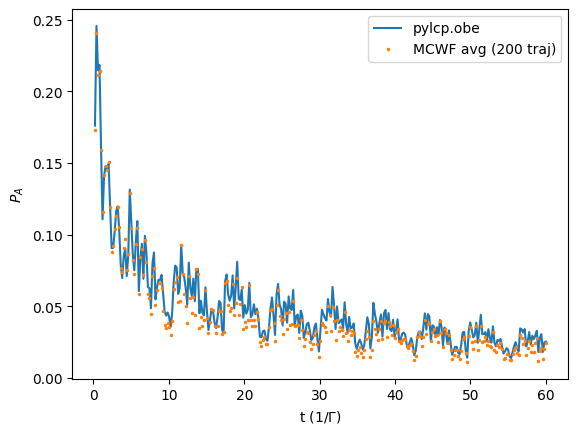

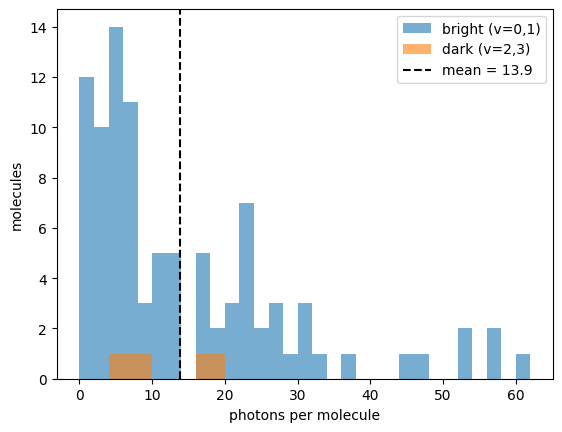

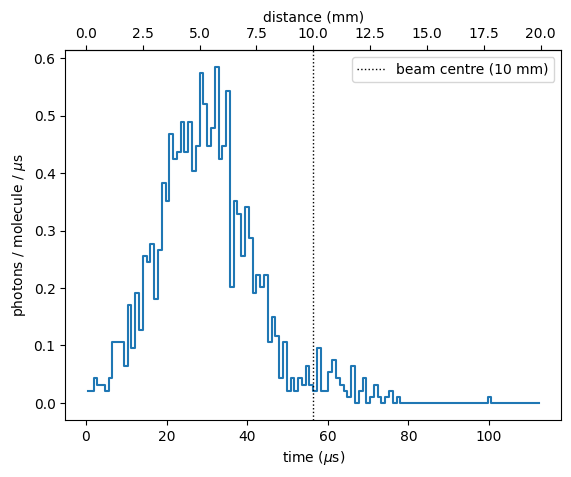

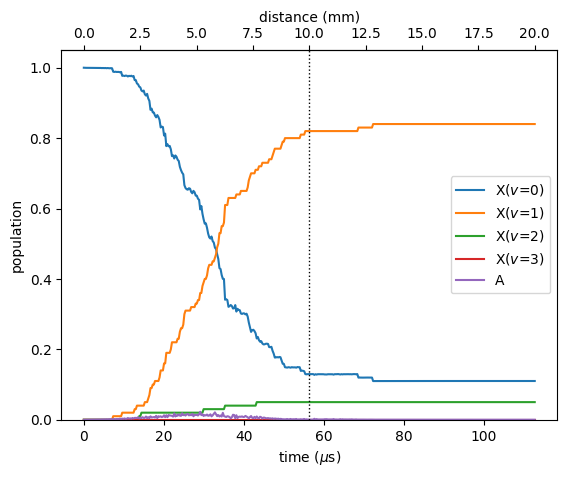


This took 732.9119970798492 s to run


In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate. 
 
The Monte-Carlo wavefunction (MCWF / quantum-jump) method gives both:
a 52-dimensional wavefunction evolves under the non-Hermitian
H_eff(t) = H(t) - (i/2) * P_excited, and each quantum jump IS a
spontaneously emitted photon whose decay channel (FCF-weighted dipole)
decides the vibrational branch. Trajectory-averaged it is mathematically
equivalent to the OBE; trajectory-by-trajectory it is a photon counting
record -- exactly the lab observable.
 
Implementation notes
--------------------
* H(t) is built from pyLCP's own `hamiltonian.return_full_H` and each
  beam's `electric_field`, so all conventions (dipole normalisation,
  polarisation, Zeeman, field amplitude <-> s) are identical to pyLCP's
  OBE by construction. The code asserts this and additionally validates
  the trajectory average against `pylcp.obe` on a reduced system.
* Sideband-sideband and counter-propagating-beam interference is fully
  coherent. The standing-wave phase is sampled by giving each molecule a
  random transverse position x0 (the lab average over the beam).
* Finite laser linewidth is included as phase diffusion, common to all
  sidebands of one colour (they come from one laser + EOM); this
  partially destabilises coherent dark states, as in the real experiment.
* Polarisation: as in the experiment, the light is LINEARLY polarised
  and an electro-optic modulator (Pockels cell) switches it between two
  orthogonal linear polarisations (here y-hat and z-hat, both
  perpendicular to k // x) with a square wave at f_EOM. This is
  implemented by giving every physical beam two static-polarisation
  pyLCP beams (so all field conventions still come from pyLCP) and
  gating them on/off in the MCWF right-hand side; each molecule sees a
  random phase of the switching cycle. Polarisation switching remixes
  Zeeman dark states in addition to the B-field.
"""

import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt
import time

t_begin = time.time()

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 100                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

time_bin = 8.46e-3 # s

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.933, 0.066, 3e-3, 2.5e-4])
fcf = fcf / np.sum(fcf, axis=0)
fcf_sum = np.sum(fcf, axis=0)
assert fcf_sum - 1. < 1e-15, f"FCF factors {fcf_sum} don't sum to 1"
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 10*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
"""
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat
"""
def power_to_s(P_total, fracs, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    fracs = np.asarray(fracs, dtype=float)
    fracs = fracs/fracs.sum()
    return (P_total*fracs)/(2*np.pi*sigma_m**2)/I_sat


V1_ON = False

frac_p1 = np.array([50, 12.5, 12.5, 25])
frac_v1 = np.array([50, 12.5, 12.5, 25])

P_p1 = 105e-3
P_v1 = 0e-3
s_p1 = power_to_s(P_p1, frac_p1, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, frac_v1, sigma_m, w_v1)
print("peak s per sideband: main", np.array2string(s_p1, precision=1),
      " repump", np.array2string(s_v1, precision=1))
print(f"P1 power {P_p1} W")
print(f"V1 power {P_v1} W")
# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 754e3
linewidth_v1_Hz = 541e3
gL_p1 = np.pi*linewidth_p1_Hz*tau   # pi*FWHM * tau = phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau

# EOM polarisation switching: linear polarisation toggled between
# y-hat and z-hat (both perp. to k // x) with a 50% duty-cycle square
# wave at f_EOM. Set to the experimental switching frequency.
f_EOM = 900000                           # Hz
T_switch = 1./(f_EOM*tau)              # full period in units of 1/Gamma
T_half_pol = 0.5*T_switch              # half period (one pol on at a time)
print(f"EOM pol switching: {f_EOM/1e6:.2f} MHz "
      f"(half-period {T_half_pol:.1f} /Gamma)")


R_ap = 5*mm                      # 5 mm aperture radius
y0_arr = np.zeros(N_MC)
# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
# V=0
H0_X[0], Bq_X[0], U_X[0], X_bases[0] = pylcp.hamiltonians.XFmolecules.Xstate(
    N=1, I=1/2, B=7233.8271, gamma=-13.41679,
    b=(170.26374-85.4208/3), 
    c=85.4208, CI=0.02038, q0=0, q2=0,
    gS=2.0023193043622, gI=0.,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
    )
#V=1,2,3
for v in range(3):
    H0, Bq, U, Xbasis = pylcp.hamiltonians.XFmolecules.Xstate(
        N=1, I=1/2, B=7188.8919, gamma=-33.81036, 
        b=(168.770 - 86.7120/3), 
        c=86.7120, CI=0.02038, q0=0, q2=0,
        gS=2.0023193043622, gI = 0.0,
        muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
        )
    H0_X[v+1], Bq_X[v+1], U_X[v+1], X_bases[v+1] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = pylcp.hamiltonians.XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=(3/2*4.8), glprime=-3*.0211,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
    )
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each, maps 4 excited A amplitudes down into the 12 sublevels of ground manifold v, for emitted polarization q.

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

# The two orthogonal linear polarisations the EOM switches between.
# Beams propagate along +/-x, so both y-hat and z-hat are transverse.
# z-hat drives pi transitions, y-hat drives (sigma+ + sigma-)/sqrt(2).
POL_EOM = (np.array([0., 1., 0.]), np.array([0., 0., 1.]))

def beam_pair(k, s_arr, deltas, s_scale=1.0):
    """Each physical beam is entered twice, once per EOM polarisation
    state (pol group 0 = y-hat, 1 = z-hat). In the MCWF the two are
    gated on/off in antiphase (square wave); for the rate-equation
    reference use s_scale=0.5 with both on, i.e. the time average."""
    beams = []
    s_arr = np.broadcast_to(np.asarray(s_arr, float), np.shape(deltas))
    for delta, s_max in zip(deltas, s_arr):
        for sign in (+1, -1):
            for pol_vec in POL_EOM:
                beams.append({'kvec': np.array([sign*k, 0., 0.]),
                              'pol': pol_vec.copy(),
                              'pol_coord': 'cartesian',
                              'delta': delta,
                              's': crossed_beam_s(s_scale*s_max,
                                                  w_beam, z_laser)})

    return pylcp.laserBeams(beams)

def polgrp_for(n_deltas):
    """Pol-group index (0=y, 1=z) per beam, matching beam_pair order."""
    return np.array([p for _ in range(n_deltas) for _ in (0, 1)
                     for p in (0, 1)], dtype=np.int64)

def hf_levels(H0):
    """Unique hyperfine energies (in Gamma units) + degeneracies."""
    E, cnt = np.unique(np.round(np.diag(H0), 6), return_counts=True)
    return E/gamma_MHz, cnt

E_X0_hf, cnt_X0 = hf_levels(H0_X[0])
E_X1_hf, cnt_X1 = hf_levels(H0_X[1])
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz

deltas_p1 = E_A_F1 - E_X0_hf + det_p1
deltas_v1 = E_A_F1 - E_X1_hf + det_v1          # <-- v=1 energies, not v=0
assert len(deltas_p1) == 4 and len(deltas_v1) == 4, "hyperfine degeneracy split"

if V1_ON:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
                'X1->A': beam_pair(k_v1, s_v1, deltas_v1)
                }

    # Rate-equation reference: rateeq cannot gate beams in time, so use the
    # time average of the square wave -- both polarisations on at s/2.
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5),
                    'X1->A': beam_pair(k_v1, s_v1, deltas_v1, s_scale=0.5)
                 }
else:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1)}
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5)}

# F-label diagnostic (just in case)
F_of_count = {1: 'F=0', 3: 'F=1', 5: 'F=2'}
for tag, (E, cnt), fr, s_ in [('P1/X0', (E_X0_hf, cnt_X0), frac_p1, s_p1),
                              ('V1/X1', (E_X1_hf, cnt_X1), frac_v1, s_v1)]:
    print(f"{tag} sideband map:")
    for i, (Ei, ci) in enumerate(zip(E, cnt)):
        print(f"  [{i}] {F_of_count[ci]:4s} E={Ei*gamma_MHz:8.1f} MHz "
              f"frac={fr[i]/np.sum(fr):.3f}  s={s_[i]:.1f}")


B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)


v_forward = 1.5/time_bin/v_unit
print(f"Forward velocity {1.5/time_bin:.2f} ms^-1 with time bin {time_bin} s")
v_vec = np.array([0., 0., v_forward])
t_max = (20*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams_re, magField, ham,
                          include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ----------------------------------------------------------
# MCWF machinery
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
if V1_ON:
    key_row = {'X0->A': 0, 'X1->A': n_X}
else:
    key_row = {'X0->A': 0}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0, y0=0.):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, y0, z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
         phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2].

    EOM polarisation switching: beam b is on only while the square wave
    (half-period T_half, molecule-specific phase offset tsw0) selects
    its pol group polgrp[b]. T_half <= 0 disables gating (all beams on,
    used by the OBE cross-check)."""
    n = psi.shape[0]
    # H_static \psi
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        if T_half > 0.:
            if (np.int64((t + tsw0)//T_half) % 2) != polgrp[b]:
                continue
        # c_b(t) = env exp(i(\delta t + \phi_{colour}))
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                    Lops, Lv, vfw, zc, sig, gL, dt, T, seed,
                    tgrid, pops, jhist):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark).

    Additionally ACCUMULATES (+=, over the whole ensemble) into:
      pops[ig, 0:4] -- population in X(v=0..3) at tgrid[ig]
      pops[ig, 4]   -- population in A at tgrid[ig]
      jhist[jb]     -- photon emission times, binned uniformly on [0, T]
    Divide both by N_MC afterwards."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    nX1 = Lops.shape[1]                 # states per X manifold (12)
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    # molecules arrive at a random phase of the EOM switching cycle
    tsw0 = 0.
    if T_half > 0.:
        tsw0 = np.random.random()*2.*T_half
    t = 0.
    ig = 0
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
             phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            # Choose channel
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            # \psi_new = C \psi
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            # Normalise
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            # bin the emission time (CCD signal ~ z = v*t)
            jb = np.int64(t/T*jhist.shape[0])
            if jb >= jhist.shape[0]:
                jb = jhist.shape[0] - 1
            jhist[jb] += 1.
            # dark vibrational state: population frozen in X(v)
            if V1_ON:
                if v >= 2:               
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            else:
                if v >= 1:
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            rjump = np.random.random()
            nrm = 1.
        elif nrm > 1e-30:
            pass
        # sample manifold populations on the output grid
        while ig < tgrid.shape[0] and t >= tgrid[ig]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # tail: fill any grid points beyond the last integration step
    if ig < tgrid.shape[0]:
        nrm = 0.
        for i in range(n):
            nrm += psi[i].real**2 + psi[i].imag**2
        while ig < tgrid.shape[0]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ---------------------------------------------------------
# Validation: MCWF trajectory average vs pylcp.obe

# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    # pylcp.obe cannot gate polarisations in time, so the cross-check is
    # run with switching DISABLED (T_half = -1): both linear pols on
    # simultaneously in both MCWF and OBE. This still validates every
    # field/phase/Zeeman/jump convention, which is pol-independent.
    pol_r = polgrp_for(len(deltas_p1))
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, 0.,
                 phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
                 0., phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         pol_r, -1.0, L_red, Lv_red, DT, tgrid,
                         int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation_nov1.png', dpi=150)

# -------------------------------------------------------
# Production: full 52-state transit ensemble
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
# 16 main + 16 repump beams (4 sidebands x 2 directions x 2 EOM pols)
colour_arr = np.array([0]*16 + [1]*16, dtype=np.int64)
polgrp_arr = np.concatenate([polgrp_for(len(deltas_p1)),
                             polgrp_for(len(deltas_v1))])
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)

# ensemble-accumulated observables (filled in-place by mcwf_trajectory)
n_tg = 400
tgrid_pop = np.linspace(0., t_max, n_tg)     # population sampling grid
pop_acc = np.zeros((n_tg, 5))                # X0..X3, A
n_jbins = 120
jump_hist = np.zeros(n_jbins)                # photon emission times

for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    y0 = R_ap*np.sqrt(rng.random())*np.sin(2*np.pi*rng.random())
    y0_arr[m] = y0
    Mb, rows, dels = extract_beam_blocks(x0, y0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, polgrp_arr, T_half_pol,
                                 L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)),
                                 tgrid_pop, pop_acc, jump_hist)
    photons[m], v_final[m] = nph, vf
    if (m+1) % 10 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

pop_acc /= N_MC                              # ensemble-average populations

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf_nov1.png', dpi=150)

# ---------------------------------------------------------
# Photon emission rate vs time / distance (what a CCD along z sees).
# Molecules fly at constant v_forward, so z = v*t maps time directly
# onto position; the top axis is distance from the start (beam centre
# marked at z_laser).
v_real = v_forward*v_unit                    # m/s
t_to_us = tau*1e6                            # sim time -> microseconds
us_to_mm = v_real*1e-3                       # 100 m/s = 0.10 mm/us

dt_bin = t_max/n_jbins
t_cent_us = (np.arange(n_jbins) + 0.5)*dt_bin*t_to_us
rate = jump_hist/N_MC/(dt_bin*t_to_us)       # photons /molecule /us

fig2, ax2 = plt.subplots()
ax2.plot(t_cent_us, rate, drawstyle='steps-mid')
ax2.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1,
            label=f'beam centre ({z_laser/mm:.0f} mm)')
ax2.set_xlabel(r'time ($\mu$s)')
ax2.set_ylabel(r'photons / molecule / $\mu$s')
secax2 = ax2.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax2.set_xlabel('distance (mm)')
ax2.legend()
fig2.savefig('photon_rate_vs_time_mcwf.png', dpi=150)

# ---------------------------------------------------------
# Ensemble-averaged populations vs time (X manifolds and A)
fig3, ax3 = plt.subplots()
t_pop_us = tgrid_pop*t_to_us
pop_labels = [r'X($v$=0)', r'X($v$=1)', r'X($v$=2)', r'X($v$=3)', 'A']
for ip in range(5):
    ax3.plot(t_pop_us, pop_acc[:, ip], label=pop_labels[ip])
ax3.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1)
ax3.set_xlabel(r'time ($\mu$s)')
ax3.set_ylabel('population')
ax3.set_ylim(bottom=0.)
secax3 = ax3.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax3.set_xlabel('distance (mm)')
ax3.legend()
fig3.savefig('populations_vs_time_mcwf.png', dpi=150)

plt.show()

print(f"\nThis took {time.time() - t_begin} s to run")

energy unit: Gamma/2pi = 5.684 MHz
peak s per sideband: main [30.3  7.6  7.6 15.1]  repump [13.8  3.5  3.5  6.9]
P1 power 0.105 W
V1 power 0.044 W
EOM pol switching: 0.90 MHz (half-period 19.8 /Gamma)
P1/X0 sideband map:
  [0] F=1  E=  -128.2 MHz frac=0.500  s=30.3
  [1] F=0  E=    27.5 MHz frac=0.125  s=7.6
  [2] F=2  E=    33.0 MHz frac=0.125  s=7.6
  [3] F=1  E=    64.0 MHz frac=0.250  s=15.1
V1/X1 sideband map:
  [0] F=1  E=  -129.4 MHz frac=0.500  s=13.8
  [1] F=2  E=    22.4 MHz frac=0.125  s=3.5
  [2] F=0  E=    47.1 MHz frac=0.125  s=3.5
  [3] F=1  E=    76.4 MHz frac=0.250  s=6.9
Forward velocity 47.62 ms^-1 with time bin 0.0315 s

rate-equation reference: 265.5 photons (expected to overestimate)

--- validating MCWF against pylcp.obe (reduced X0+A system) ---
max |P_A(MCWF avg, 200 traj) - P_A(OBE)| = 0.0138 (peak P_A ~ 0.246)

--- MCWF ensemble: 100 molecules through the beams ---
  10/100: running mean = 103.2
  20/100: running mean = 98.8
  30/100: running mean = 111.3
  4

KeyboardInterrupt: 

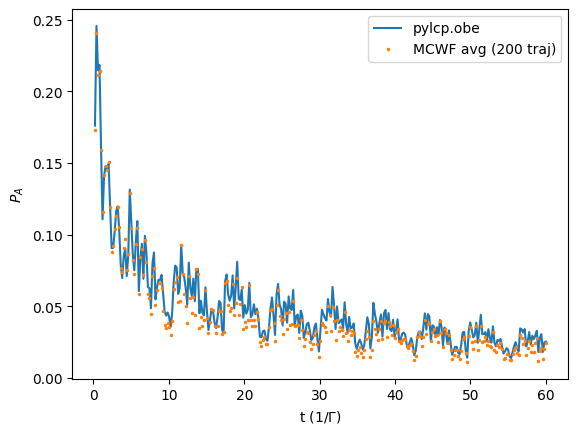

In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate. 
 
The Monte-Carlo wavefunction (MCWF / quantum-jump) method gives both:
a 52-dimensional wavefunction evolves under the non-Hermitian
H_eff(t) = H(t) - (i/2) * P_excited, and each quantum jump IS a
spontaneously emitted photon whose decay channel (FCF-weighted dipole)
decides the vibrational branch. Trajectory-averaged it is mathematically
equivalent to the OBE; trajectory-by-trajectory it is a photon counting
record -- exactly the lab observable.
 
Implementation notes
--------------------
* H(t) is built from pyLCP's own `hamiltonian.return_full_H` and each
  beam's `electric_field`, so all conventions (dipole normalisation,
  polarisation, Zeeman, field amplitude <-> s) are identical to pyLCP's
  OBE by construction. The code asserts this and additionally validates
  the trajectory average against `pylcp.obe` on a reduced system.
* Sideband-sideband and counter-propagating-beam interference is fully
  coherent. The standing-wave phase is sampled by giving each molecule a
  random transverse position x0 (the lab average over the beam).
* Finite laser linewidth is included as phase diffusion, common to all
  sidebands of one colour (they come from one laser + EOM); this
  partially destabilises coherent dark states, as in the real experiment.
* Polarisation: as in the experiment, the light is LINEARLY polarised
  and an electro-optic modulator (Pockels cell) switches it between two
  orthogonal linear polarisations (here y-hat and z-hat, both
  perpendicular to k // x) with a square wave at f_EOM. This is
  implemented by giving every physical beam two static-polarisation
  pyLCP beams (so all field conventions still come from pyLCP) and
  gating them on/off in the MCWF right-hand side; each molecule sees a
  random phase of the switching cycle. Polarisation switching remixes
  Zeeman dark states in addition to the B-field.
"""

import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt
import time

t_begin = time.time()

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 100                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

time_bin = 31.5e-3 # s

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.933, 0.066, 3e-3, 2.5e-4])
fcf = fcf / np.sum(fcf, axis=0)
fcf_sum = np.sum(fcf, axis=0)
assert fcf_sum - 1. < 1e-15, f"FCF factors {fcf_sum} don't sum to 1"
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 10*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
"""
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat
"""
def power_to_s(P_total, fracs, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    fracs = np.asarray(fracs, dtype=float)
    fracs = fracs/fracs.sum()
    return (P_total*fracs)/(2*np.pi*sigma_m**2)/I_sat


V1_ON = True

frac_p1 = np.array([50, 12.5, 12.5, 25])
frac_v1 = np.array([50, 12.5, 12.5, 25])

P_p1 = 105e-3
P_v1 = 44e-3
s_p1 = power_to_s(P_p1, frac_p1, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, frac_v1, sigma_m, w_v1)
print("peak s per sideband: main", np.array2string(s_p1, precision=1),
      " repump", np.array2string(s_v1, precision=1))
print(f"P1 power {P_p1} W")
print(f"V1 power {P_v1} W")
# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 754e3
linewidth_v1_Hz = 541e3
gL_p1 = np.pi*linewidth_p1_Hz*tau   # pi*FWHM * tau = phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau

# EOM polarisation switching: linear polarisation toggled between
# y-hat and z-hat (both perp. to k // x) with a 50% duty-cycle square
# wave at f_EOM. Set to the experimental switching frequency.
f_EOM = 900000                           # Hz
T_switch = 1./(f_EOM*tau)              # full period in units of 1/Gamma
T_half_pol = 0.5*T_switch              # half period (one pol on at a time)
print(f"EOM pol switching: {f_EOM/1e6:.2f} MHz "
      f"(half-period {T_half_pol:.1f} /Gamma)")


R_ap = 5*mm                      # 5 mm aperture radius
y0_arr = np.zeros(N_MC)
# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
# V=0
H0_X[0], Bq_X[0], U_X[0], X_bases[0] = pylcp.hamiltonians.XFmolecules.Xstate(
    N=1, I=1/2, B=7233.8271, gamma=-13.41679,
    b=(170.26374-85.4208/3), 
    c=85.4208, CI=0.02038, q0=0, q2=0,
    gS=2.0023193043622, gI=0.,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
    )
#V=1,2,3
for v in range(3):
    H0, Bq, U, Xbasis = pylcp.hamiltonians.XFmolecules.Xstate(
        N=1, I=1/2, B=7188.8919, gamma=-33.81036, 
        b=(168.770 - 86.7120/3), 
        c=86.7120, CI=0.02038, q0=0, q2=0,
        gS=2.0023193043622, gI = 0.0,
        muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
        )
    H0_X[v+1], Bq_X[v+1], U_X[v+1], X_bases[v+1] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = pylcp.hamiltonians.XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=(3/2*4.8), glprime=-3*.0211,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
    )
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each, maps 4 excited A amplitudes down into the 12 sublevels of ground manifold v, for emitted polarization q.

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

# The two orthogonal linear polarisations the EOM switches between.
# Beams propagate along +/-x, so both y-hat and z-hat are transverse.
# z-hat drives pi transitions, y-hat drives (sigma+ + sigma-)/sqrt(2).
POL_EOM = (np.array([0., 1., 0.]), np.array([0., 0., 1.]))

def beam_pair(k, s_arr, deltas, s_scale=1.0):
    """Each physical beam is entered twice, once per EOM polarisation
    state (pol group 0 = y-hat, 1 = z-hat). In the MCWF the two are
    gated on/off in antiphase (square wave); for the rate-equation
    reference use s_scale=0.5 with both on, i.e. the time average."""
    beams = []
    s_arr = np.broadcast_to(np.asarray(s_arr, float), np.shape(deltas))
    for delta, s_max in zip(deltas, s_arr):
        for sign in (+1, -1):
            for pol_vec in POL_EOM:
                beams.append({'kvec': np.array([sign*k, 0., 0.]),
                              'pol': pol_vec.copy(),
                              'pol_coord': 'cartesian',
                              'delta': delta,
                              's': crossed_beam_s(s_scale*s_max,
                                                  w_beam, z_laser)})

    return pylcp.laserBeams(beams)

def polgrp_for(n_deltas):
    """Pol-group index (0=y, 1=z) per beam, matching beam_pair order."""
    return np.array([p for _ in range(n_deltas) for _ in (0, 1)
                     for p in (0, 1)], dtype=np.int64)

def hf_levels(H0):
    """Unique hyperfine energies (in Gamma units) + degeneracies."""
    E, cnt = np.unique(np.round(np.diag(H0), 6), return_counts=True)
    return E/gamma_MHz, cnt

E_X0_hf, cnt_X0 = hf_levels(H0_X[0])
E_X1_hf, cnt_X1 = hf_levels(H0_X[1])
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz

deltas_p1 = E_A_F1 - E_X0_hf + det_p1
deltas_v1 = E_A_F1 - E_X1_hf + det_v1          # <-- v=1 energies, not v=0
assert len(deltas_p1) == 4 and len(deltas_v1) == 4, "hyperfine degeneracy split"

if V1_ON:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
                'X1->A': beam_pair(k_v1, s_v1, deltas_v1)
                }

    # Rate-equation reference: rateeq cannot gate beams in time, so use the
    # time average of the square wave -- both polarisations on at s/2.
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5),
                    'X1->A': beam_pair(k_v1, s_v1, deltas_v1, s_scale=0.5)
                 }
else:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1)}
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5)}

# F-label diagnostic (just in case)
F_of_count = {1: 'F=0', 3: 'F=1', 5: 'F=2'}
for tag, (E, cnt), fr, s_ in [('P1/X0', (E_X0_hf, cnt_X0), frac_p1, s_p1),
                              ('V1/X1', (E_X1_hf, cnt_X1), frac_v1, s_v1)]:
    print(f"{tag} sideband map:")
    for i, (Ei, ci) in enumerate(zip(E, cnt)):
        print(f"  [{i}] {F_of_count[ci]:4s} E={Ei*gamma_MHz:8.1f} MHz "
              f"frac={fr[i]/np.sum(fr):.3f}  s={s_[i]:.1f}")


B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)


v_forward = 1.5/time_bin/v_unit
print(f"Forward velocity {1.5/time_bin:.2f} ms^-1 with time bin {time_bin} s")
v_vec = np.array([0., 0., v_forward])
t_max = (20*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams_re, magField, ham,
                          include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ----------------------------------------------------------
# MCWF machinery
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
if V1_ON:
    key_row = {'X0->A': 0, 'X1->A': n_X}
else:
    key_row = {'X0->A': 0}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0, y0=0.):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, y0, z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
         phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2].

    EOM polarisation switching: beam b is on only while the square wave
    (half-period T_half, molecule-specific phase offset tsw0) selects
    its pol group polgrp[b]. T_half <= 0 disables gating (all beams on,
    used by the OBE cross-check)."""
    n = psi.shape[0]
    # H_static \psi
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        if T_half > 0.:
            if (np.int64((t + tsw0)//T_half) % 2) != polgrp[b]:
                continue
        # c_b(t) = env exp(i(\delta t + \phi_{colour}))
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                    Lops, Lv, vfw, zc, sig, gL, dt, T, seed,
                    tgrid, pops, jhist):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark).

    Additionally ACCUMULATES (+=, over the whole ensemble) into:
      pops[ig, 0:4] -- population in X(v=0..3) at tgrid[ig]
      pops[ig, 4]   -- population in A at tgrid[ig]
      jhist[jb]     -- photon emission times, binned uniformly on [0, T]
    Divide both by N_MC afterwards."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    nX1 = Lops.shape[1]                 # states per X manifold (12)
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    # molecules arrive at a random phase of the EOM switching cycle
    tsw0 = 0.
    if T_half > 0.:
        tsw0 = np.random.random()*2.*T_half
    t = 0.
    ig = 0
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
             phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            # Choose channel
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            # \psi_new = C \psi
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            # Normalise
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            # bin the emission time (CCD signal ~ z = v*t)
            jb = np.int64(t/T*jhist.shape[0])
            if jb >= jhist.shape[0]:
                jb = jhist.shape[0] - 1
            jhist[jb] += 1.
            # dark vibrational state: population frozen in X(v)
            if V1_ON:
                if v >= 2:               
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            else:
                if v >= 1:
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            rjump = np.random.random()
            nrm = 1.
        elif nrm > 1e-30:
            pass
        # sample manifold populations on the output grid
        while ig < tgrid.shape[0] and t >= tgrid[ig]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # tail: fill any grid points beyond the last integration step
    if ig < tgrid.shape[0]:
        nrm = 0.
        for i in range(n):
            nrm += psi[i].real**2 + psi[i].imag**2
        while ig < tgrid.shape[0]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ---------------------------------------------------------
# Validation: MCWF trajectory average vs pylcp.obe

# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    # pylcp.obe cannot gate polarisations in time, so the cross-check is
    # run with switching DISABLED (T_half = -1): both linear pols on
    # simultaneously in both MCWF and OBE. This still validates every
    # field/phase/Zeeman/jump convention, which is pol-independent.
    pol_r = polgrp_for(len(deltas_p1))
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, 0.,
                 phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
                 0., phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         pol_r, -1.0, L_red, Lv_red, DT, tgrid,
                         int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation_nov1.png', dpi=150)

# -------------------------------------------------------
# Production: full 52-state transit ensemble
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
# 16 main + 16 repump beams (4 sidebands x 2 directions x 2 EOM pols)
colour_arr = np.array([0]*16 + [1]*16, dtype=np.int64)
polgrp_arr = np.concatenate([polgrp_for(len(deltas_p1)),
                             polgrp_for(len(deltas_v1))])
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)

# ensemble-accumulated observables (filled in-place by mcwf_trajectory)
n_tg = 400
tgrid_pop = np.linspace(0., t_max, n_tg)     # population sampling grid
pop_acc = np.zeros((n_tg, 5))                # X0..X3, A
n_jbins = 120
jump_hist = np.zeros(n_jbins)                # photon emission times

for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    y0 = R_ap*np.sqrt(rng.random())*np.sin(2*np.pi*rng.random())
    y0_arr[m] = y0
    Mb, rows, dels = extract_beam_blocks(x0, y0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, polgrp_arr, T_half_pol,
                                 L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)),
                                 tgrid_pop, pop_acc, jump_hist)
    photons[m], v_final[m] = nph, vf
    if (m+1) % 10 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

pop_acc /= N_MC                              # ensemble-average populations

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf_nov1.png', dpi=150)

# ---------------------------------------------------------
# Photon emission rate vs time / distance (what a CCD along z sees).
# Molecules fly at constant v_forward, so z = v*t maps time directly
# onto position; the top axis is distance from the start (beam centre
# marked at z_laser).
v_real = v_forward*v_unit                    # m/s
t_to_us = tau*1e6                            # sim time -> microseconds
us_to_mm = v_real*1e-3                       # 100 m/s = 0.10 mm/us

dt_bin = t_max/n_jbins
t_cent_us = (np.arange(n_jbins) + 0.5)*dt_bin*t_to_us
rate = jump_hist/N_MC/(dt_bin*t_to_us)       # photons /molecule /us

fig2, ax2 = plt.subplots()
ax2.plot(t_cent_us, rate, drawstyle='steps-mid')
ax2.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1,
            label=f'beam centre ({z_laser/mm:.0f} mm)')
ax2.set_xlabel(r'time ($\mu$s)')
ax2.set_ylabel(r'photons / molecule / $\mu$s')
secax2 = ax2.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax2.set_xlabel('distance (mm)')
ax2.legend()
fig2.savefig('photon_rate_vs_time_mcwf.png', dpi=150)

# ---------------------------------------------------------
# Ensemble-averaged populations vs time (X manifolds and A)
fig3, ax3 = plt.subplots()
t_pop_us = tgrid_pop*t_to_us
pop_labels = [r'X($v$=0)', r'X($v$=1)', r'X($v$=2)', r'X($v$=3)', 'A']
for ip in range(5):
    ax3.plot(t_pop_us, pop_acc[:, ip], label=pop_labels[ip])
ax3.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1)
ax3.set_xlabel(r'time ($\mu$s)')
ax3.set_ylabel('population')
ax3.set_ylim(bottom=0.)
secax3 = ax3.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax3.set_xlabel('distance (mm)')
ax3.legend()
fig3.savefig('populations_vs_time_mcwf.png', dpi=150)

plt.show()

print(f"\nThis took {time.time() - t_begin} s to run")

In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate. 
 
The Monte-Carlo wavefunction (MCWF / quantum-jump) method gives both:
a 52-dimensional wavefunction evolves under the non-Hermitian
H_eff(t) = H(t) - (i/2) * P_excited, and each quantum jump IS a
spontaneously emitted photon whose decay channel (FCF-weighted dipole)
decides the vibrational branch. Trajectory-averaged it is mathematically
equivalent to the OBE; trajectory-by-trajectory it is a photon counting
record -- exactly the lab observable.
 
Implementation notes
--------------------
* H(t) is built from pyLCP's own `hamiltonian.return_full_H` and each
  beam's `electric_field`, so all conventions (dipole normalisation,
  polarisation, Zeeman, field amplitude <-> s) are identical to pyLCP's
  OBE by construction. The code asserts this and additionally validates
  the trajectory average against `pylcp.obe` on a reduced system.
* Sideband-sideband and counter-propagating-beam interference is fully
  coherent. The standing-wave phase is sampled by giving each molecule a
  random transverse position x0 (the lab average over the beam).
* Finite laser linewidth is included as phase diffusion, common to all
  sidebands of one colour (they come from one laser + EOM); this
  partially destabilises coherent dark states, as in the real experiment.
* Polarisation: as in the experiment, the light is LINEARLY polarised
  and an electro-optic modulator (Pockels cell) switches it between two
  orthogonal linear polarisations (here y-hat and z-hat, both
  perpendicular to k // x) with a square wave at f_EOM. This is
  implemented by giving every physical beam two static-polarisation
  pyLCP beams (so all field conventions still come from pyLCP) and
  gating them on/off in the MCWF right-hand side; each molecule sees a
  random phase of the switching cycle. Polarisation switching remixes
  Zeeman dark states in addition to the B-field.
"""

import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt
import time

t_begin = time.time()

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 100                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

time_bin = 31.5e-3 # s

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.933, 0.066, 3e-3, 2.5e-4])
fcf = fcf / np.sum(fcf, axis=0)
fcf_sum = np.sum(fcf, axis=0)
assert fcf_sum - 1. < 1e-15, f"FCF factors {fcf_sum} don't sum to 1"
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 10*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
"""
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat
"""
def power_to_s(P_total, fracs, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    fracs = np.asarray(fracs, dtype=float)
    fracs = fracs/fracs.sum()
    return (P_total*fracs)/(2*np.pi*sigma_m**2)/I_sat


V1_ON = True

frac_p1 = np.array([50, 12.5, 12.5, 25])
frac_v1 = np.array([50, 12.5, 12.5, 25])

P_p1 = 105e-3
P_v1 = 44e-3
s_p1 = power_to_s(P_p1, frac_p1, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, frac_v1, sigma_m, w_v1)
print("peak s per sideband: main", np.array2string(s_p1, precision=1),
      " repump", np.array2string(s_v1, precision=1))
print(f"P1 power {P_p1} W")
print(f"V1 power {P_v1} W")
# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 754e3
linewidth_v1_Hz = 541e3
gL_p1 = np.pi*linewidth_p1_Hz*tau   # pi*FWHM * tau = phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau

# EOM polarisation switching: linear polarisation toggled between
# y-hat and z-hat (both perp. to k // x) with a 50% duty-cycle square
# wave at f_EOM. Set to the experimental switching frequency.
f_EOM = 900000                           # Hz
T_switch = 1./(f_EOM*tau)              # full period in units of 1/Gamma
T_half_pol = 0.5*T_switch              # half period (one pol on at a time)
print(f"EOM pol switching: {f_EOM/1e6:.2f} MHz "
      f"(half-period {T_half_pol:.1f} /Gamma)")


R_ap = 5*mm                      # 5 mm aperture radius
y0_arr = np.zeros(N_MC)
# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
# V=0
H0_X[0], Bq_X[0], U_X[0], X_bases[0] = pylcp.hamiltonians.XFmolecules.Xstate(
    N=1, I=1/2, B=7233.8271, gamma=-13.41679,
    b=(170.26374-85.4208/3), 
    c=85.4208, CI=0.02038, q0=0, q2=0,
    gS=2.0023193043622, gI=0.,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
    )
#V=1,2,3
for v in range(3):
    H0, Bq, U, Xbasis = pylcp.hamiltonians.XFmolecules.Xstate(
        N=1, I=1/2, B=7188.8919, gamma=-33.81036, 
        b=(168.770 - 86.7120/3), 
        c=86.7120, CI=0.02038, q0=0, q2=0,
        gS=2.0023193043622, gI = 0.0,
        muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
        )
    H0_X[v+1], Bq_X[v+1], U_X[v+1], X_bases[v+1] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = pylcp.hamiltonians.XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=(3/2*4.8), glprime=-3*.0211,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
    )
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each, maps 4 excited A amplitudes down into the 12 sublevels of ground manifold v, for emitted polarization q.

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

# The two orthogonal linear polarisations the EOM switches between.
# Beams propagate along +/-x, so both y-hat and z-hat are transverse.
# z-hat drives pi transitions, y-hat drives (sigma+ + sigma-)/sqrt(2).
POL_EOM = (np.array([0., 1., 0.]), np.array([0., 0., 1.]))

def beam_pair(k, s_arr, deltas, s_scale=1.0):
    """Each physical beam is entered twice, once per EOM polarisation
    state (pol group 0 = y-hat, 1 = z-hat). In the MCWF the two are
    gated on/off in antiphase (square wave); for the rate-equation
    reference use s_scale=0.5 with both on, i.e. the time average."""
    beams = []
    s_arr = np.broadcast_to(np.asarray(s_arr, float), np.shape(deltas))
    for delta, s_max in zip(deltas, s_arr):
        for sign in (+1, -1):
            for pol_vec in POL_EOM:
                beams.append({'kvec': np.array([sign*k, 0., 0.]),
                              'pol': pol_vec.copy(),
                              'pol_coord': 'cartesian',
                              'delta': delta,
                              's': crossed_beam_s(s_scale*s_max,
                                                  w_beam, z_laser)})

    return pylcp.laserBeams(beams)

def polgrp_for(n_deltas):
    """Pol-group index (0=y, 1=z) per beam, matching beam_pair order."""
    return np.array([p for _ in range(n_deltas) for _ in (0, 1)
                     for p in (0, 1)], dtype=np.int64)

def hf_levels(H0):
    """Unique hyperfine energies (in Gamma units) + degeneracies."""
    E, cnt = np.unique(np.round(np.diag(H0), 6), return_counts=True)
    return E/gamma_MHz, cnt

E_X0_hf, cnt_X0 = hf_levels(H0_X[0])
E_X1_hf, cnt_X1 = hf_levels(H0_X[1])
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz

deltas_p1 = E_A_F1 - E_X0_hf + det_p1
deltas_v1 = E_A_F1 - E_X1_hf + det_v1          # <-- v=1 energies, not v=0
assert len(deltas_p1) == 4 and len(deltas_v1) == 4, "hyperfine degeneracy split"

if V1_ON:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
                'X1->A': beam_pair(k_v1, s_v1, deltas_v1)
                }

    # Rate-equation reference: rateeq cannot gate beams in time, so use the
    # time average of the square wave -- both polarisations on at s/2.
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5),
                    'X1->A': beam_pair(k_v1, s_v1, deltas_v1, s_scale=0.5)
                 }
else:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1)}
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5)}

# F-label diagnostic (just in case)
F_of_count = {1: 'F=0', 3: 'F=1', 5: 'F=2'}
for tag, (E, cnt), fr, s_ in [('P1/X0', (E_X0_hf, cnt_X0), frac_p1, s_p1),
                              ('V1/X1', (E_X1_hf, cnt_X1), frac_v1, s_v1)]:
    print(f"{tag} sideband map:")
    for i, (Ei, ci) in enumerate(zip(E, cnt)):
        print(f"  [{i}] {F_of_count[ci]:4s} E={Ei*gamma_MHz:8.1f} MHz "
              f"frac={fr[i]/np.sum(fr):.3f}  s={s_[i]:.1f}")


B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)


v_forward = 3.5/time_bin/v_unit 
print(f"Forward velocity {1.5/time_bin:.2f} ms^-1 with time bin {time_bin} s")
v_vec = np.array([0., 0., v_forward])
t_max = (20*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams_re, magField, ham,
                          include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ----------------------------------------------------------
# MCWF machinery
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
if V1_ON:
    key_row = {'X0->A': 0, 'X1->A': n_X}
else:
    key_row = {'X0->A': 0}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0, y0=0.):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, y0, z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
         phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2].

    EOM polarisation switching: beam b is on only while the square wave
    (half-period T_half, molecule-specific phase offset tsw0) selects
    its pol group polgrp[b]. T_half <= 0 disables gating (all beams on,
    used by the OBE cross-check)."""
    n = psi.shape[0]
    # H_static \psi
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        if T_half > 0.:
            if (np.int64((t + tsw0)//T_half) % 2) != polgrp[b]:
                continue
        # c_b(t) = env exp(i(\delta t + \phi_{colour}))
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                    Lops, Lv, vfw, zc, sig, gL, dt, T, seed,
                    tgrid, pops, jhist):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark).

    Additionally ACCUMULATES (+=, over the whole ensemble) into:
      pops[ig, 0:4] -- population in X(v=0..3) at tgrid[ig]
      pops[ig, 4]   -- population in A at tgrid[ig]
      jhist[jb]     -- photon emission times, binned uniformly on [0, T]
    Divide both by N_MC afterwards."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    nX1 = Lops.shape[1]                 # states per X manifold (12)
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    # molecules arrive at a random phase of the EOM switching cycle
    tsw0 = 0.
    if T_half > 0.:
        tsw0 = np.random.random()*2.*T_half
    t = 0.
    ig = 0
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
             phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            # Choose channel
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            # \psi_new = C \psi
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            # Normalise
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            # bin the emission time (CCD signal ~ z = v*t)
            jb = np.int64(t/T*jhist.shape[0])
            if jb >= jhist.shape[0]:
                jb = jhist.shape[0] - 1
            jhist[jb] += 1.
            # dark vibrational state: population frozen in X(v)
            if V1_ON:
                if v >= 2:               
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            else:
                if v >= 1:
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            rjump = np.random.random()
            nrm = 1.
        elif nrm > 1e-30:
            pass
        # sample manifold populations on the output grid
        while ig < tgrid.shape[0] and t >= tgrid[ig]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # tail: fill any grid points beyond the last integration step
    if ig < tgrid.shape[0]:
        nrm = 0.
        for i in range(n):
            nrm += psi[i].real**2 + psi[i].imag**2
        while ig < tgrid.shape[0]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ---------------------------------------------------------
# Validation: MCWF trajectory average vs pylcp.obe

# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    # pylcp.obe cannot gate polarisations in time, so the cross-check is
    # run with switching DISABLED (T_half = -1): both linear pols on
    # simultaneously in both MCWF and OBE. This still validates every
    # field/phase/Zeeman/jump convention, which is pol-independent.
    pol_r = polgrp_for(len(deltas_p1))
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, 0.,
                 phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
                 0., phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         pol_r, -1.0, L_red, Lv_red, DT, tgrid,
                         int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation_nov1.png', dpi=150)

# -------------------------------------------------------
# Production: full 52-state transit ensemble
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
# 16 main + 16 repump beams (4 sidebands x 2 directions x 2 EOM pols)
colour_arr = np.array([0]*16 + [1]*16, dtype=np.int64)
polgrp_arr = np.concatenate([polgrp_for(len(deltas_p1)),
                             polgrp_for(len(deltas_v1))])
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)

# ensemble-accumulated observables (filled in-place by mcwf_trajectory)
n_tg = 400
tgrid_pop = np.linspace(0., t_max, n_tg)     # population sampling grid
pop_acc = np.zeros((n_tg, 5))                # X0..X3, A
n_jbins = 120
jump_hist = np.zeros(n_jbins)                # photon emission times

for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    y0 = R_ap*np.sqrt(rng.random())*np.sin(2*np.pi*rng.random())
    y0_arr[m] = y0
    Mb, rows, dels = extract_beam_blocks(x0, y0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, polgrp_arr, T_half_pol,
                                 L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)),
                                 tgrid_pop, pop_acc, jump_hist)
    photons[m], v_final[m] = nph, vf
    if (m+1) % 10 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

pop_acc /= N_MC                              # ensemble-average populations

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf_nov1.png', dpi=150)

# ---------------------------------------------------------
# Photon emission rate vs time / distance (what a CCD along z sees).
# Molecules fly at constant v_forward, so z = v*t maps time directly
# onto position; the top axis is distance from the start (beam centre
# marked at z_laser).
v_real = v_forward*v_unit                    # m/s
t_to_us = tau*1e6                            # sim time -> microseconds
us_to_mm = v_real*1e-3                       # 100 m/s = 0.10 mm/us

dt_bin = t_max/n_jbins
t_cent_us = (np.arange(n_jbins) + 0.5)*dt_bin*t_to_us
rate = jump_hist/N_MC/(dt_bin*t_to_us)       # photons /molecule /us

fig2, ax2 = plt.subplots()
ax2.plot(t_cent_us, rate, drawstyle='steps-mid')
ax2.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1,
            label=f'beam centre ({z_laser/mm:.0f} mm)')
ax2.set_xlabel(r'time ($\mu$s)')
ax2.set_ylabel(r'photons / molecule / $\mu$s')
secax2 = ax2.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax2.set_xlabel('distance (mm)')
ax2.legend()
fig2.savefig('photon_rate_vs_time_mcwf.png', dpi=150)

# ---------------------------------------------------------
# Ensemble-averaged populations vs time (X manifolds and A)
fig3, ax3 = plt.subplots()
t_pop_us = tgrid_pop*t_to_us
pop_labels = [r'X($v$=0)', r'X($v$=1)', r'X($v$=2)', r'X($v$=3)', 'A']
for ip in range(5):
    ax3.plot(t_pop_us, pop_acc[:, ip], label=pop_labels[ip])
ax3.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1)
ax3.set_xlabel(r'time ($\mu$s)')
ax3.set_ylabel('population')
ax3.set_ylim(bottom=0.)
secax3 = ax3.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax3.set_xlabel('distance (mm)')
ax3.legend()
fig3.savefig('populations_vs_time_mcwf.png', dpi=150)

plt.show()

print(f"\nThis took {time.time() - t_begin} s to run")

energy unit: Gamma/2pi = 5.684 MHz
peak s per sideband: main [30.3  7.6  7.6 15.1]  repump [13.8  3.5  3.5  6.9]
P1 power 0.105 W
V1 power 0.044 W
EOM pol switching: 0.90 MHz (half-period 19.8 /Gamma)
P1/X0 sideband map:
  [0] F=1  E=  -128.2 MHz frac=0.500  s=30.3
  [1] F=0  E=    27.5 MHz frac=0.125  s=7.6
  [2] F=2  E=    33.0 MHz frac=0.125  s=7.6
  [3] F=1  E=    64.0 MHz frac=0.250  s=15.1
V1/X1 sideband map:
  [0] F=1  E=  -129.4 MHz frac=0.500  s=13.8
  [1] F=2  E=    22.4 MHz frac=0.125  s=3.5
  [2] F=0  E=    47.1 MHz frac=0.125  s=3.5
  [3] F=1  E=    76.4 MHz frac=0.250  s=6.9
Forward velocity 47.62 ms^-1 with time bin 0.0315 s


KeyboardInterrupt: 

energy unit: Gamma/2pi = 5.684 MHz
peak s per sideband: main [30.3  7.6  7.6 15.1]  repump [13.8  3.5  3.5  6.9]
P1 power 0.105 W
V1 power 0.044 W
EOM pol switching: 0.90 MHz (half-period 19.8 /Gamma)
P1/X0 sideband map:
  [0] F=1  E=  -128.2 MHz frac=0.500  s=30.3
  [1] F=0  E=    27.5 MHz frac=0.125  s=7.6
  [2] F=2  E=    33.0 MHz frac=0.125  s=7.6
  [3] F=1  E=    64.0 MHz frac=0.250  s=15.1
V1/X1 sideband map:
  [0] F=1  E=  -129.4 MHz frac=0.500  s=13.8
  [1] F=2  E=    22.4 MHz frac=0.125  s=3.5
  [2] F=0  E=    47.1 MHz frac=0.125  s=3.5
  [3] F=1  E=    76.4 MHz frac=0.250  s=6.9
Forward velocity 111.11 ms^-1 with time bin 0.0315 s

rate-equation reference: 178.4 photons (expected to overestimate)

--- validating MCWF against pylcp.obe (reduced X0+A system) ---
max |P_A(MCWF avg, 200 traj) - P_A(OBE)| = 0.0138 (peak P_A ~ 0.246)

--- MCWF ensemble: 100 molecules through the beams ---
  10/100: running mean = 33.0
  20/100: running mean = 56.0
  30/100: running mean = 57.1
  40

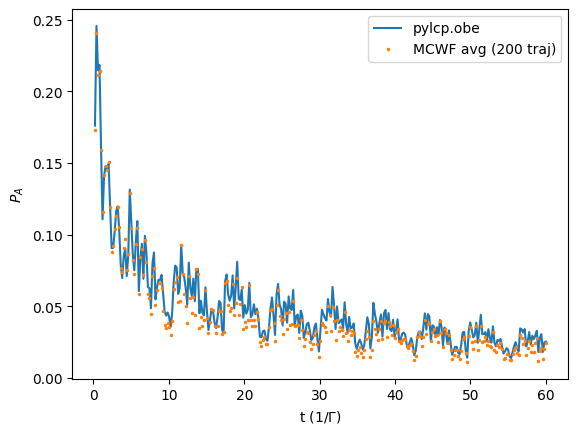

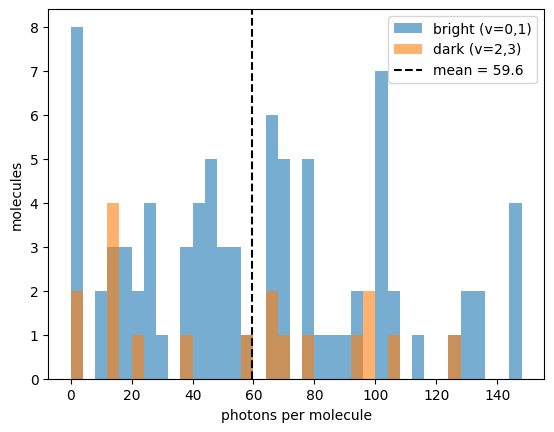

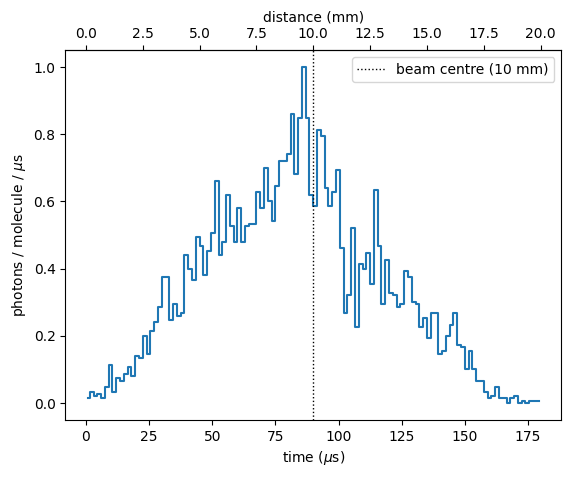

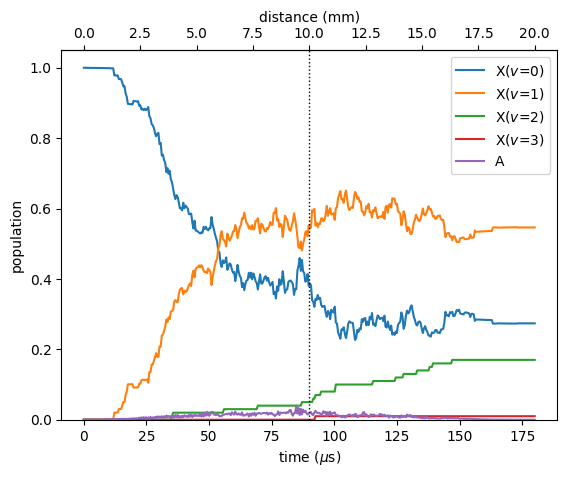


This took 3607.6408393383026 s to run


In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate. 
 
The Monte-Carlo wavefunction (MCWF / quantum-jump) method gives both:
a 52-dimensional wavefunction evolves under the non-Hermitian
H_eff(t) = H(t) - (i/2) * P_excited, and each quantum jump IS a
spontaneously emitted photon whose decay channel (FCF-weighted dipole)
decides the vibrational branch. Trajectory-averaged it is mathematically
equivalent to the OBE; trajectory-by-trajectory it is a photon counting
record -- exactly the lab observable.
 
Implementation notes
--------------------
* H(t) is built from pyLCP's own `hamiltonian.return_full_H` and each
  beam's `electric_field`, so all conventions (dipole normalisation,
  polarisation, Zeeman, field amplitude <-> s) are identical to pyLCP's
  OBE by construction. The code asserts this and additionally validates
  the trajectory average against `pylcp.obe` on a reduced system.
* Sideband-sideband and counter-propagating-beam interference is fully
  coherent. The standing-wave phase is sampled by giving each molecule a
  random transverse position x0 (the lab average over the beam).
* Finite laser linewidth is included as phase diffusion, common to all
  sidebands of one colour (they come from one laser + EOM); this
  partially destabilises coherent dark states, as in the real experiment.
* Polarisation: as in the experiment, the light is LINEARLY polarised
  and an electro-optic modulator (Pockels cell) switches it between two
  orthogonal linear polarisations (here y-hat and z-hat, both
  perpendicular to k // x) with a square wave at f_EOM. This is
  implemented by giving every physical beam two static-polarisation
  pyLCP beams (so all field conventions still come from pyLCP) and
  gating them on/off in the MCWF right-hand side; each molecule sees a
  random phase of the switching cycle. Polarisation switching remixes
  Zeeman dark states in addition to the B-field.
"""

import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt
import time

t_begin = time.time()

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 100                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

time_bin = 31.5e-3 # s

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.933, 0.066, 3e-3, 2.5e-4])
fcf = fcf / np.sum(fcf, axis=0)
fcf_sum = np.sum(fcf, axis=0)
assert fcf_sum - 1. < 1e-15, f"FCF factors {fcf_sum} don't sum to 1"
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 10*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
"""
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat
"""
def power_to_s(P_total, fracs, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    fracs = np.asarray(fracs, dtype=float)
    fracs = fracs/fracs.sum()
    return (P_total*fracs)/(2*np.pi*sigma_m**2)/I_sat


V1_ON = True

frac_p1 = np.array([50, 12.5, 12.5, 25])
frac_v1 = np.array([50, 12.5, 12.5, 25])

P_p1 = 105e-3
P_v1 = 44e-3
s_p1 = power_to_s(P_p1, frac_p1, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, frac_v1, sigma_m, w_v1)
print("peak s per sideband: main", np.array2string(s_p1, precision=1),
      " repump", np.array2string(s_v1, precision=1))
print(f"P1 power {P_p1} W")
print(f"V1 power {P_v1} W")
# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 754e3
linewidth_v1_Hz = 541e3
gL_p1 = np.pi*linewidth_p1_Hz*tau   # pi*FWHM * tau = phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau

# EOM polarisation switching: linear polarisation toggled between
# y-hat and z-hat (both perp. to k // x) with a 50% duty-cycle square
# wave at f_EOM. Set to the experimental switching frequency.
f_EOM = 900000                           # Hz
T_switch = 1./(f_EOM*tau)              # full period in units of 1/Gamma
T_half_pol = 0.5*T_switch              # half period (one pol on at a time)
print(f"EOM pol switching: {f_EOM/1e6:.2f} MHz "
      f"(half-period {T_half_pol:.1f} /Gamma)")


R_ap = 5*mm                      # 5 mm aperture radius
y0_arr = np.zeros(N_MC)
# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
# V=0
H0_X[0], Bq_X[0], U_X[0], X_bases[0] = pylcp.hamiltonians.XFmolecules.Xstate(
    N=1, I=1/2, B=7233.8271, gamma=-13.41679,
    b=(170.26374-85.4208/3), 
    c=85.4208, CI=0.02038, q0=0, q2=0,
    gS=2.0023193043622, gI=0.,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
    )
#V=1,2,3
for v in range(3):
    H0, Bq, U, Xbasis = pylcp.hamiltonians.XFmolecules.Xstate(
        N=1, I=1/2, B=7188.8919, gamma=-33.81036, 
        b=(168.770 - 86.7120/3), 
        c=86.7120, CI=0.02038, q0=0, q2=0,
        gS=2.0023193043622, gI = 0.0,
        muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
        )
    H0_X[v+1], Bq_X[v+1], U_X[v+1], X_bases[v+1] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = pylcp.hamiltonians.XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=(3/2*4.8), glprime=-3*.0211,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
    )
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each, maps 4 excited A amplitudes down into the 12 sublevels of ground manifold v, for emitted polarization q.

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

# The two orthogonal linear polarisations the EOM switches between.
# Beams propagate along +/-x, so both y-hat and z-hat are transverse.
# z-hat drives pi transitions, y-hat drives (sigma+ + sigma-)/sqrt(2).
POL_EOM = (np.array([0., 1., 0.]), np.array([0., 0., 1.]))

def beam_pair(k, s_arr, deltas, s_scale=1.0):
    """Each physical beam is entered twice, once per EOM polarisation
    state (pol group 0 = y-hat, 1 = z-hat). In the MCWF the two are
    gated on/off in antiphase (square wave); for the rate-equation
    reference use s_scale=0.5 with both on, i.e. the time average."""
    beams = []
    s_arr = np.broadcast_to(np.asarray(s_arr, float), np.shape(deltas))
    for delta, s_max in zip(deltas, s_arr):
        for sign in (+1, -1):
            for pol_vec in POL_EOM:
                beams.append({'kvec': np.array([sign*k, 0., 0.]),
                              'pol': pol_vec.copy(),
                              'pol_coord': 'cartesian',
                              'delta': delta,
                              's': crossed_beam_s(s_scale*s_max,
                                                  w_beam, z_laser)})

    return pylcp.laserBeams(beams)

def polgrp_for(n_deltas):
    """Pol-group index (0=y, 1=z) per beam, matching beam_pair order."""
    return np.array([p for _ in range(n_deltas) for _ in (0, 1)
                     for p in (0, 1)], dtype=np.int64)

def hf_levels(H0):
    """Unique hyperfine energies (in Gamma units) + degeneracies."""
    E, cnt = np.unique(np.round(np.diag(H0), 6), return_counts=True)
    return E/gamma_MHz, cnt

E_X0_hf, cnt_X0 = hf_levels(H0_X[0])
E_X1_hf, cnt_X1 = hf_levels(H0_X[1])
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz

deltas_p1 = E_A_F1 - E_X0_hf + det_p1
deltas_v1 = E_A_F1 - E_X1_hf + det_v1          # <-- v=1 energies, not v=0
assert len(deltas_p1) == 4 and len(deltas_v1) == 4, "hyperfine degeneracy split"

if V1_ON:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
                'X1->A': beam_pair(k_v1, s_v1, deltas_v1)
                }

    # Rate-equation reference: rateeq cannot gate beams in time, so use the
    # time average of the square wave -- both polarisations on at s/2.
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5),
                    'X1->A': beam_pair(k_v1, s_v1, deltas_v1, s_scale=0.5)
                 }
else:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1)}
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5)}

# F-label diagnostic (just in case)
F_of_count = {1: 'F=0', 3: 'F=1', 5: 'F=2'}
for tag, (E, cnt), fr, s_ in [('P1/X0', (E_X0_hf, cnt_X0), frac_p1, s_p1),
                              ('V1/X1', (E_X1_hf, cnt_X1), frac_v1, s_v1)]:
    print(f"{tag} sideband map:")
    for i, (Ei, ci) in enumerate(zip(E, cnt)):
        print(f"  [{i}] {F_of_count[ci]:4s} E={Ei*gamma_MHz:8.1f} MHz "
              f"frac={fr[i]/np.sum(fr):.3f}  s={s_[i]:.1f}")


B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)


v_forward = 3.5/time_bin/v_unit 
print(f"Forward velocity {3.5/time_bin:.2f} ms^-1 with time bin {time_bin} s")
v_vec = np.array([0., 0., v_forward])
t_max = (20*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams_re, magField, ham,
                          include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ----------------------------------------------------------
# MCWF machinery
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
if V1_ON:
    key_row = {'X0->A': 0, 'X1->A': n_X}
else:
    key_row = {'X0->A': 0}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0, y0=0.):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, y0, z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
         phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2].

    EOM polarisation switching: beam b is on only while the square wave
    (half-period T_half, molecule-specific phase offset tsw0) selects
    its pol group polgrp[b]. T_half <= 0 disables gating (all beams on,
    used by the OBE cross-check)."""
    n = psi.shape[0]
    # H_static \psi
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        if T_half > 0.:
            if (np.int64((t + tsw0)//T_half) % 2) != polgrp[b]:
                continue
        # c_b(t) = env exp(i(\delta t + \phi_{colour}))
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                    Lops, Lv, vfw, zc, sig, gL, dt, T, seed,
                    tgrid, pops, jhist):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark).

    Additionally ACCUMULATES (+=, over the whole ensemble) into:
      pops[ig, 0:4] -- population in X(v=0..3) at tgrid[ig]
      pops[ig, 4]   -- population in A at tgrid[ig]
      jhist[jb]     -- photon emission times, binned uniformly on [0, T]
    Divide both by N_MC afterwards."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    nX1 = Lops.shape[1]                 # states per X manifold (12)
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    # molecules arrive at a random phase of the EOM switching cycle
    tsw0 = 0.
    if T_half > 0.:
        tsw0 = np.random.random()*2.*T_half
    t = 0.
    ig = 0
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
             phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            # Choose channel
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            # \psi_new = C \psi
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            # Normalise
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            # bin the emission time (CCD signal ~ z = v*t)
            jb = np.int64(t/T*jhist.shape[0])
            if jb >= jhist.shape[0]:
                jb = jhist.shape[0] - 1
            jhist[jb] += 1.
            # dark vibrational state: population frozen in X(v)
            if V1_ON:
                if v >= 2:               
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            else:
                if v >= 1:
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            rjump = np.random.random()
            nrm = 1.
        elif nrm > 1e-30:
            pass
        # sample manifold populations on the output grid
        while ig < tgrid.shape[0] and t >= tgrid[ig]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # tail: fill any grid points beyond the last integration step
    if ig < tgrid.shape[0]:
        nrm = 0.
        for i in range(n):
            nrm += psi[i].real**2 + psi[i].imag**2
        while ig < tgrid.shape[0]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ---------------------------------------------------------
# Validation: MCWF trajectory average vs pylcp.obe

# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    # pylcp.obe cannot gate polarisations in time, so the cross-check is
    # run with switching DISABLED (T_half = -1): both linear pols on
    # simultaneously in both MCWF and OBE. This still validates every
    # field/phase/Zeeman/jump convention, which is pol-independent.
    pol_r = polgrp_for(len(deltas_p1))
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, 0.,
                 phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
                 0., phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         pol_r, -1.0, L_red, Lv_red, DT, tgrid,
                         int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation_nov1.png', dpi=150)

# -------------------------------------------------------
# Production: full 52-state transit ensemble
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
# 16 main + 16 repump beams (4 sidebands x 2 directions x 2 EOM pols)
colour_arr = np.array([0]*16 + [1]*16, dtype=np.int64)
polgrp_arr = np.concatenate([polgrp_for(len(deltas_p1)),
                             polgrp_for(len(deltas_v1))])
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)

# ensemble-accumulated observables (filled in-place by mcwf_trajectory)
n_tg = 400
tgrid_pop = np.linspace(0., t_max, n_tg)     # population sampling grid
pop_acc = np.zeros((n_tg, 5))                # X0..X3, A
n_jbins = 120
jump_hist = np.zeros(n_jbins)                # photon emission times

for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    y0 = R_ap*np.sqrt(rng.random())*np.sin(2*np.pi*rng.random())
    y0_arr[m] = y0
    Mb, rows, dels = extract_beam_blocks(x0, y0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, polgrp_arr, T_half_pol,
                                 L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)),
                                 tgrid_pop, pop_acc, jump_hist)
    photons[m], v_final[m] = nph, vf
    if (m+1) % 10 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

pop_acc /= N_MC                              # ensemble-average populations

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf_nov1.png', dpi=150)

# ---------------------------------------------------------
# Photon emission rate vs time / distance (what a CCD along z sees).
# Molecules fly at constant v_forward, so z = v*t maps time directly
# onto position; the top axis is distance from the start (beam centre
# marked at z_laser).
v_real = v_forward*v_unit                    # m/s
t_to_us = tau*1e6                            # sim time -> microseconds
us_to_mm = v_real*1e-3                       # 100 m/s = 0.10 mm/us

dt_bin = t_max/n_jbins
t_cent_us = (np.arange(n_jbins) + 0.5)*dt_bin*t_to_us
rate = jump_hist/N_MC/(dt_bin*t_to_us)       # photons /molecule /us

fig2, ax2 = plt.subplots()
ax2.plot(t_cent_us, rate, drawstyle='steps-mid')
ax2.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1,
            label=f'beam centre ({z_laser/mm:.0f} mm)')
ax2.set_xlabel(r'time ($\mu$s)')
ax2.set_ylabel(r'photons / molecule / $\mu$s')
secax2 = ax2.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax2.set_xlabel('distance (mm)')
ax2.legend()
fig2.savefig('photon_rate_vs_time_mcwf.png', dpi=150)

# ---------------------------------------------------------
# Ensemble-averaged populations vs time (X manifolds and A)
fig3, ax3 = plt.subplots()
t_pop_us = tgrid_pop*t_to_us
pop_labels = [r'X($v$=0)', r'X($v$=1)', r'X($v$=2)', r'X($v$=3)', 'A']
for ip in range(5):
    ax3.plot(t_pop_us, pop_acc[:, ip], label=pop_labels[ip])
ax3.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1)
ax3.set_xlabel(r'time ($\mu$s)')
ax3.set_ylabel('population')
ax3.set_ylim(bottom=0.)
secax3 = ax3.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax3.set_xlabel('distance (mm)')
ax3.legend()
fig3.savefig('populations_vs_time_mcwf.png', dpi=150)

plt.show()

print(f"\nThis took {time.time() - t_begin} s to run")

energy unit: Gamma/2pi = 5.684 MHz
peak s per sideband: main [30.3  7.6  7.6 15.1]  repump [0. 0. 0. 0.]
P1 power 0.105 W
V1 power 0 W
EOM pol switching: 0.90 MHz (half-period 19.8 /Gamma)
P1/X0 sideband map:
  [0] F=1  E=  -128.2 MHz frac=0.500  s=30.3
  [1] F=0  E=    27.5 MHz frac=0.125  s=7.6
  [2] F=2  E=    33.0 MHz frac=0.125  s=7.6
  [3] F=1  E=    64.0 MHz frac=0.250  s=15.1
V1/X1 sideband map:
  [0] F=1  E=  -129.4 MHz frac=0.500  s=0.0
  [1] F=2  E=    22.4 MHz frac=0.125  s=0.0
  [2] F=0  E=    47.1 MHz frac=0.125  s=0.0
  [3] F=1  E=    76.4 MHz frac=0.250  s=0.0
Forward velocity 111.11 ms^-1 with time bin 0.0315 s

rate-equation reference: 14.5 photons (expected to overestimate)

--- validating MCWF against pylcp.obe (reduced X0+A system) ---
max |P_A(MCWF avg, 200 traj) - P_A(OBE)| = 0.0138 (peak P_A ~ 0.246)

--- MCWF ensemble: 100 molecules through the beams ---
  10/100: running mean = 14.2
  20/100: running mean = 12.6
  30/100: running mean = 13.8
  40/100: running 

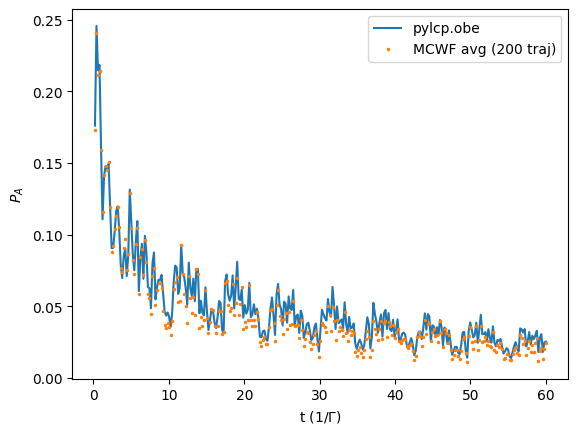

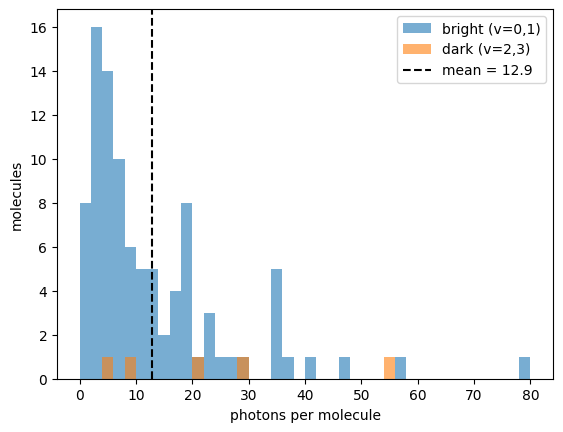

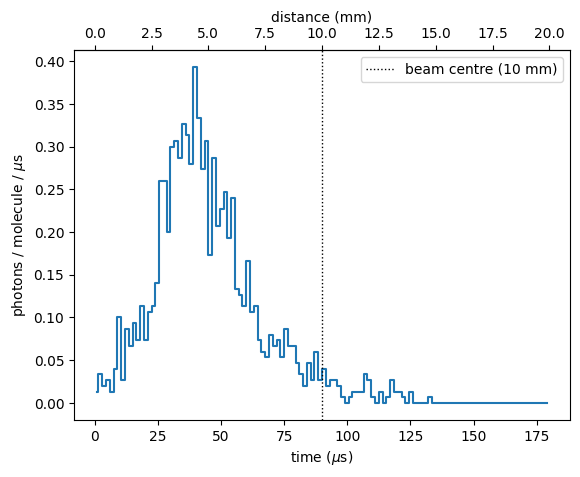

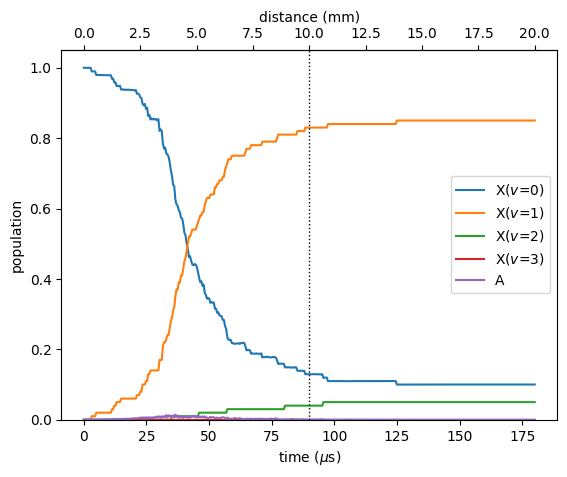


This took 1031.7950451374054 s to run


In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate. 
 
The Monte-Carlo wavefunction (MCWF / quantum-jump) method gives both:
a 52-dimensional wavefunction evolves under the non-Hermitian
H_eff(t) = H(t) - (i/2) * P_excited, and each quantum jump IS a
spontaneously emitted photon whose decay channel (FCF-weighted dipole)
decides the vibrational branch. Trajectory-averaged it is mathematically
equivalent to the OBE; trajectory-by-trajectory it is a photon counting
record -- exactly the lab observable.
 
Implementation notes
--------------------
* H(t) is built from pyLCP's own `hamiltonian.return_full_H` and each
  beam's `electric_field`, so all conventions (dipole normalisation,
  polarisation, Zeeman, field amplitude <-> s) are identical to pyLCP's
  OBE by construction. The code asserts this and additionally validates
  the trajectory average against `pylcp.obe` on a reduced system.
* Sideband-sideband and counter-propagating-beam interference is fully
  coherent. The standing-wave phase is sampled by giving each molecule a
  random transverse position x0 (the lab average over the beam).
* Finite laser linewidth is included as phase diffusion, common to all
  sidebands of one colour (they come from one laser + EOM); this
  partially destabilises coherent dark states, as in the real experiment.
* Polarisation: as in the experiment, the light is LINEARLY polarised
  and an electro-optic modulator (Pockels cell) switches it between two
  orthogonal linear polarisations (here y-hat and z-hat, both
  perpendicular to k // x) with a square wave at f_EOM. This is
  implemented by giving every physical beam two static-polarisation
  pyLCP beams (so all field conventions still come from pyLCP) and
  gating them on/off in the MCWF right-hand side; each molecule sees a
  random phase of the switching cycle. Polarisation switching remixes
  Zeeman dark states in addition to the B-field.
"""

import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt
import time

t_begin = time.time()

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 100                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

time_bin = 31.5e-3 # s

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.933, 0.066, 3e-3, 2.5e-4])
fcf = fcf / np.sum(fcf, axis=0)
fcf_sum = np.sum(fcf, axis=0)
assert fcf_sum - 1. < 1e-15, f"FCF factors {fcf_sum} don't sum to 1"
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 10*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
"""
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat
"""
def power_to_s(P_total, fracs, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    fracs = np.asarray(fracs, dtype=float)
    fracs = fracs/fracs.sum()
    return (P_total*fracs)/(2*np.pi*sigma_m**2)/I_sat


V1_ON = False

frac_p1 = np.array([50, 12.5, 12.5, 25])
frac_v1 = np.array([50, 12.5, 12.5, 25])

P_p1 = 105e-3
P_v1 = 0#44e-3
s_p1 = power_to_s(P_p1, frac_p1, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, frac_v1, sigma_m, w_v1)
print("peak s per sideband: main", np.array2string(s_p1, precision=1),
      " repump", np.array2string(s_v1, precision=1))
print(f"P1 power {P_p1} W")
print(f"V1 power {P_v1} W")
# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 754e3
linewidth_v1_Hz = 541e3
gL_p1 = np.pi*linewidth_p1_Hz*tau   # pi*FWHM * tau = phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau

# EOM polarisation switching: linear polarisation toggled between
# y-hat and z-hat (both perp. to k // x) with a 50% duty-cycle square
# wave at f_EOM. Set to the experimental switching frequency.
f_EOM = 900000                           # Hz
T_switch = 1./(f_EOM*tau)              # full period in units of 1/Gamma
T_half_pol = 0.5*T_switch              # half period (one pol on at a time)
print(f"EOM pol switching: {f_EOM/1e6:.2f} MHz "
      f"(half-period {T_half_pol:.1f} /Gamma)")


R_ap = 5*mm                      # 5 mm aperture radius
y0_arr = np.zeros(N_MC)
# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
# V=0
H0_X[0], Bq_X[0], U_X[0], X_bases[0] = pylcp.hamiltonians.XFmolecules.Xstate(
    N=1, I=1/2, B=7233.8271, gamma=-13.41679,
    b=(170.26374-85.4208/3), 
    c=85.4208, CI=0.02038, q0=0, q2=0,
    gS=2.0023193043622, gI=0.,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
    )
#V=1,2,3
for v in range(3):
    H0, Bq, U, Xbasis = pylcp.hamiltonians.XFmolecules.Xstate(
        N=1, I=1/2, B=7188.8919, gamma=-33.81036, 
        b=(168.770 - 86.7120/3), 
        c=86.7120, CI=0.02038, q0=0, q2=0,
        gS=2.0023193043622, gI = 0.0,
        muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
        )
    H0_X[v+1], Bq_X[v+1], U_X[v+1], X_bases[v+1] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = pylcp.hamiltonians.XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=(3/2*4.8), glprime=-3*.0211,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
    )
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each, maps 4 excited A amplitudes down into the 12 sublevels of ground manifold v, for emitted polarization q.

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

# The two orthogonal linear polarisations the EOM switches between.
# Beams propagate along +/-x, so both y-hat and z-hat are transverse.
# z-hat drives pi transitions, y-hat drives (sigma+ + sigma-)/sqrt(2).
POL_EOM = (np.array([0., 1., 0.]), np.array([0., 0., 1.]))

def beam_pair(k, s_arr, deltas, s_scale=1.0):
    """Each physical beam is entered twice, once per EOM polarisation
    state (pol group 0 = y-hat, 1 = z-hat). In the MCWF the two are
    gated on/off in antiphase (square wave); for the rate-equation
    reference use s_scale=0.5 with both on, i.e. the time average."""
    beams = []
    s_arr = np.broadcast_to(np.asarray(s_arr, float), np.shape(deltas))
    for delta, s_max in zip(deltas, s_arr):
        for sign in (+1, -1):
            for pol_vec in POL_EOM:
                beams.append({'kvec': np.array([sign*k, 0., 0.]),
                              'pol': pol_vec.copy(),
                              'pol_coord': 'cartesian',
                              'delta': delta,
                              's': crossed_beam_s(s_scale*s_max,
                                                  w_beam, z_laser)})

    return pylcp.laserBeams(beams)

def polgrp_for(n_deltas):
    """Pol-group index (0=y, 1=z) per beam, matching beam_pair order."""
    return np.array([p for _ in range(n_deltas) for _ in (0, 1)
                     for p in (0, 1)], dtype=np.int64)

def hf_levels(H0):
    """Unique hyperfine energies (in Gamma units) + degeneracies."""
    E, cnt = np.unique(np.round(np.diag(H0), 6), return_counts=True)
    return E/gamma_MHz, cnt

E_X0_hf, cnt_X0 = hf_levels(H0_X[0])
E_X1_hf, cnt_X1 = hf_levels(H0_X[1])
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz

deltas_p1 = E_A_F1 - E_X0_hf + det_p1
deltas_v1 = E_A_F1 - E_X1_hf + det_v1          # <-- v=1 energies, not v=0
assert len(deltas_p1) == 4 and len(deltas_v1) == 4, "hyperfine degeneracy split"

if V1_ON:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
                'X1->A': beam_pair(k_v1, s_v1, deltas_v1)
                }

    # Rate-equation reference: rateeq cannot gate beams in time, so use the
    # time average of the square wave -- both polarisations on at s/2.
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5),
                    'X1->A': beam_pair(k_v1, s_v1, deltas_v1, s_scale=0.5)
                 }
else:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1)}
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5)}

# F-label diagnostic (just in case)
F_of_count = {1: 'F=0', 3: 'F=1', 5: 'F=2'}
for tag, (E, cnt), fr, s_ in [('P1/X0', (E_X0_hf, cnt_X0), frac_p1, s_p1),
                              ('V1/X1', (E_X1_hf, cnt_X1), frac_v1, s_v1)]:
    print(f"{tag} sideband map:")
    for i, (Ei, ci) in enumerate(zip(E, cnt)):
        print(f"  [{i}] {F_of_count[ci]:4s} E={Ei*gamma_MHz:8.1f} MHz "
              f"frac={fr[i]/np.sum(fr):.3f}  s={s_[i]:.1f}")


B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)


v_forward = 3.5/time_bin/v_unit 
print(f"Forward velocity {3.5/time_bin:.2f} ms^-1 with time bin {time_bin} s")
v_vec = np.array([0., 0., v_forward])
t_max = (20*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams_re, magField, ham,
                          include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ----------------------------------------------------------
# MCWF machinery
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
if V1_ON:
    key_row = {'X0->A': 0, 'X1->A': n_X}
else:
    key_row = {'X0->A': 0}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0, y0=0.):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, y0, z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
         phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2].

    EOM polarisation switching: beam b is on only while the square wave
    (half-period T_half, molecule-specific phase offset tsw0) selects
    its pol group polgrp[b]. T_half <= 0 disables gating (all beams on,
    used by the OBE cross-check)."""
    n = psi.shape[0]
    # H_static \psi
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        if T_half > 0.:
            if (np.int64((t + tsw0)//T_half) % 2) != polgrp[b]:
                continue
        # c_b(t) = env exp(i(\delta t + \phi_{colour}))
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                    Lops, Lv, vfw, zc, sig, gL, dt, T, seed,
                    tgrid, pops, jhist):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark).

    Additionally ACCUMULATES (+=, over the whole ensemble) into:
      pops[ig, 0:4] -- population in X(v=0..3) at tgrid[ig]
      pops[ig, 4]   -- population in A at tgrid[ig]
      jhist[jb]     -- photon emission times, binned uniformly on [0, T]
    Divide both by N_MC afterwards."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    nX1 = Lops.shape[1]                 # states per X manifold (12)
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    # molecules arrive at a random phase of the EOM switching cycle
    tsw0 = 0.
    if T_half > 0.:
        tsw0 = np.random.random()*2.*T_half
    t = 0.
    ig = 0
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
             phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            # Choose channel
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            # \psi_new = C \psi
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            # Normalise
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            # bin the emission time (CCD signal ~ z = v*t)
            jb = np.int64(t/T*jhist.shape[0])
            if jb >= jhist.shape[0]:
                jb = jhist.shape[0] - 1
            jhist[jb] += 1.
            # dark vibrational state: population frozen in X(v)
            if V1_ON:
                if v >= 2:               
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            else:
                if v >= 1:
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            rjump = np.random.random()
            nrm = 1.
        elif nrm > 1e-30:
            pass
        # sample manifold populations on the output grid
        while ig < tgrid.shape[0] and t >= tgrid[ig]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # tail: fill any grid points beyond the last integration step
    if ig < tgrid.shape[0]:
        nrm = 0.
        for i in range(n):
            nrm += psi[i].real**2 + psi[i].imag**2
        while ig < tgrid.shape[0]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ---------------------------------------------------------
# Validation: MCWF trajectory average vs pylcp.obe

# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    # pylcp.obe cannot gate polarisations in time, so the cross-check is
    # run with switching DISABLED (T_half = -1): both linear pols on
    # simultaneously in both MCWF and OBE. This still validates every
    # field/phase/Zeeman/jump convention, which is pol-independent.
    pol_r = polgrp_for(len(deltas_p1))
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, 0.,
                 phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
                 0., phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         pol_r, -1.0, L_red, Lv_red, DT, tgrid,
                         int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation_nov1.png', dpi=150)

# -------------------------------------------------------
# Production: full 52-state transit ensemble
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
# 16 main + 16 repump beams (4 sidebands x 2 directions x 2 EOM pols)
colour_arr = np.array([0]*16 + [1]*16, dtype=np.int64)
polgrp_arr = np.concatenate([polgrp_for(len(deltas_p1)),
                             polgrp_for(len(deltas_v1))])
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)

# ensemble-accumulated observables (filled in-place by mcwf_trajectory)
n_tg = 400
tgrid_pop = np.linspace(0., t_max, n_tg)     # population sampling grid
pop_acc = np.zeros((n_tg, 5))                # X0..X3, A
n_jbins = 120
jump_hist = np.zeros(n_jbins)                # photon emission times

for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    y0 = R_ap*np.sqrt(rng.random())*np.sin(2*np.pi*rng.random())
    y0_arr[m] = y0
    Mb, rows, dels = extract_beam_blocks(x0, y0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, polgrp_arr, T_half_pol,
                                 L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)),
                                 tgrid_pop, pop_acc, jump_hist)
    photons[m], v_final[m] = nph, vf
    if (m+1) % 10 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

pop_acc /= N_MC                              # ensemble-average populations

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf_nov1.png', dpi=150)

# ---------------------------------------------------------
# Photon emission rate vs time / distance (what a CCD along z sees).
# Molecules fly at constant v_forward, so z = v*t maps time directly
# onto position; the top axis is distance from the start (beam centre
# marked at z_laser).
v_real = v_forward*v_unit                    # m/s
t_to_us = tau*1e6                            # sim time -> microseconds
us_to_mm = v_real*1e-3                       # 100 m/s = 0.10 mm/us

dt_bin = t_max/n_jbins
t_cent_us = (np.arange(n_jbins) + 0.5)*dt_bin*t_to_us
rate = jump_hist/N_MC/(dt_bin*t_to_us)       # photons /molecule /us

fig2, ax2 = plt.subplots()
ax2.plot(t_cent_us, rate, drawstyle='steps-mid')
ax2.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1,
            label=f'beam centre ({z_laser/mm:.0f} mm)')
ax2.set_xlabel(r'time ($\mu$s)')
ax2.set_ylabel(r'photons / molecule / $\mu$s')
secax2 = ax2.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax2.set_xlabel('distance (mm)')
ax2.legend()
fig2.savefig('photon_rate_vs_time_mcwf.png', dpi=150)

# ---------------------------------------------------------
# Ensemble-averaged populations vs time (X manifolds and A)
fig3, ax3 = plt.subplots()
t_pop_us = tgrid_pop*t_to_us
pop_labels = [r'X($v$=0)', r'X($v$=1)', r'X($v$=2)', r'X($v$=3)', 'A']
for ip in range(5):
    ax3.plot(t_pop_us, pop_acc[:, ip], label=pop_labels[ip])
ax3.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1)
ax3.set_xlabel(r'time ($\mu$s)')
ax3.set_ylabel('population')
ax3.set_ylim(bottom=0.)
secax3 = ax3.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax3.set_xlabel('distance (mm)')
ax3.legend()
fig3.savefig('populations_vs_time_mcwf.png', dpi=150)

plt.show()

print(f"\nThis took {time.time() - t_begin} s to run")

energy unit: Gamma/2pi = 5.684 MHz
peak s per sideband: main [30.3  7.6  7.6 15.1]  repump [13.8  3.5  3.5  6.9]
P1 power 0.105 W
V1 power 0.044 W
EOM pol switching: 0.90 MHz (half-period 19.8 /Gamma)
P1/X0 sideband map:
  [0] F=1  E=  -128.2 MHz frac=0.500  s=30.3
  [1] F=0  E=    27.5 MHz frac=0.125  s=7.6
  [2] F=2  E=    33.0 MHz frac=0.125  s=7.6
  [3] F=1  E=    64.0 MHz frac=0.250  s=15.1
V1/X1 sideband map:
  [0] F=1  E=  -129.4 MHz frac=0.500  s=13.8
  [1] F=2  E=    22.4 MHz frac=0.125  s=3.5
  [2] F=0  E=    47.1 MHz frac=0.125  s=3.5
  [3] F=1  E=    76.4 MHz frac=0.250  s=6.9
Forward velocity 411.76 ms^-1 with time bin 0.0085 s

rate-equation reference: 68.2 photons (expected to overestimate)

--- validating MCWF against pylcp.obe (reduced X0+A system) ---
max |P_A(MCWF avg, 200 traj) - P_A(OBE)| = 0.0138 (peak P_A ~ 0.246)

--- MCWF ensemble: 100 molecules through the beams ---
  10/100: running mean = 20.3
  20/100: running mean = 23.1
  30/100: running mean = 22.8
  40/

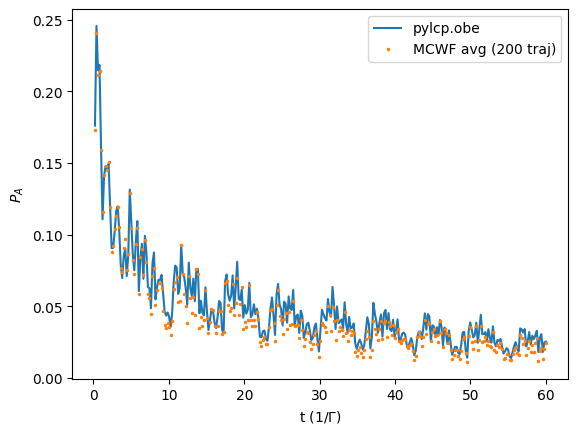

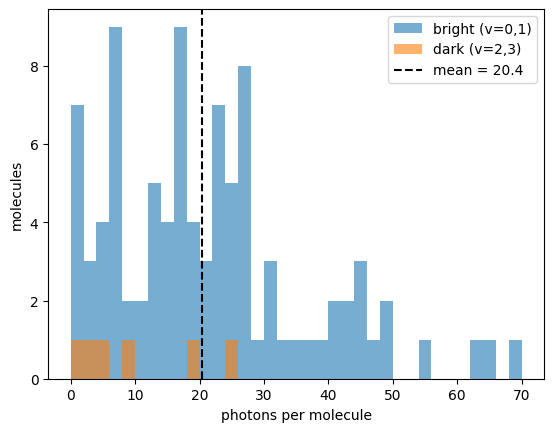

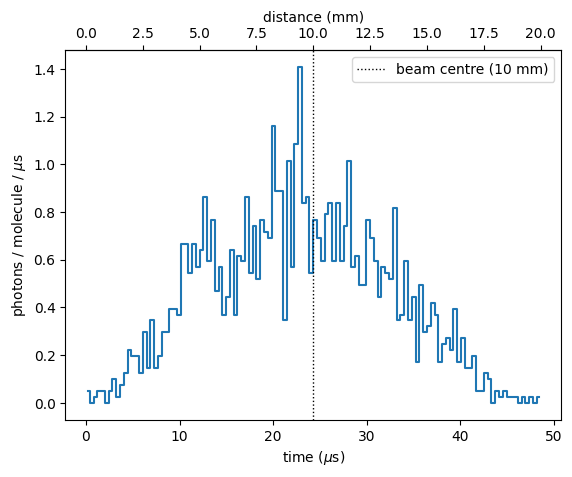

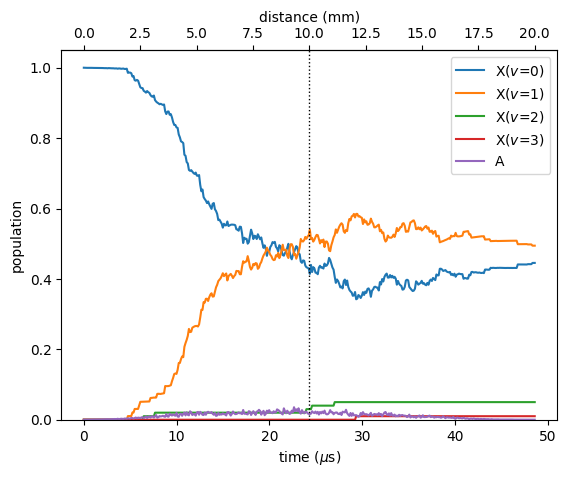


This took 1031.7065198421478 s to run


In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate. 
 
The Monte-Carlo wavefunction (MCWF / quantum-jump) method gives both:
a 52-dimensional wavefunction evolves under the non-Hermitian
H_eff(t) = H(t) - (i/2) * P_excited, and each quantum jump IS a
spontaneously emitted photon whose decay channel (FCF-weighted dipole)
decides the vibrational branch. Trajectory-averaged it is mathematically
equivalent to the OBE; trajectory-by-trajectory it is a photon counting
record -- exactly the lab observable.
 
Implementation notes
--------------------
* H(t) is built from pyLCP's own `hamiltonian.return_full_H` and each
  beam's `electric_field`, so all conventions (dipole normalisation,
  polarisation, Zeeman, field amplitude <-> s) are identical to pyLCP's
  OBE by construction. The code asserts this and additionally validates
  the trajectory average against `pylcp.obe` on a reduced system.
* Sideband-sideband and counter-propagating-beam interference is fully
  coherent. The standing-wave phase is sampled by giving each molecule a
  random transverse position x0 (the lab average over the beam).
* Finite laser linewidth is included as phase diffusion, common to all
  sidebands of one colour (they come from one laser + EOM); this
  partially destabilises coherent dark states, as in the real experiment.
* Polarisation: as in the experiment, the light is LINEARLY polarised
  and an electro-optic modulator (Pockels cell) switches it between two
  orthogonal linear polarisations (here y-hat and z-hat, both
  perpendicular to k // x) with a square wave at f_EOM. This is
  implemented by giving every physical beam two static-polarisation
  pyLCP beams (so all field conventions still come from pyLCP) and
  gating them on/off in the MCWF right-hand side; each molecule sees a
  random phase of the switching cycle. Polarisation switching remixes
  Zeeman dark states in addition to the B-field.
"""

import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt
import time

t_begin = time.time()

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 100                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

time_bin = 8.5e-3 # s

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.933, 0.066, 3e-3, 2.5e-4])
fcf = fcf / np.sum(fcf, axis=0)
fcf_sum = np.sum(fcf, axis=0)
assert fcf_sum - 1. < 1e-15, f"FCF factors {fcf_sum} don't sum to 1"
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 10*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
"""
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat
"""
def power_to_s(P_total, fracs, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    fracs = np.asarray(fracs, dtype=float)
    fracs = fracs/fracs.sum()
    return (P_total*fracs)/(2*np.pi*sigma_m**2)/I_sat


V1_ON = True

frac_p1 = np.array([50, 12.5, 12.5, 25])
frac_v1 = np.array([50, 12.5, 12.5, 25])

P_p1 = 105e-3
P_v1 = 44e-3
s_p1 = power_to_s(P_p1, frac_p1, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, frac_v1, sigma_m, w_v1)
print("peak s per sideband: main", np.array2string(s_p1, precision=1),
      " repump", np.array2string(s_v1, precision=1))
print(f"P1 power {P_p1} W")
print(f"V1 power {P_v1} W")
# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 754e3
linewidth_v1_Hz = 541e3
gL_p1 = np.pi*linewidth_p1_Hz*tau   # pi*FWHM * tau = phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau

# EOM polarisation switching: linear polarisation toggled between
# y-hat and z-hat (both perp. to k // x) with a 50% duty-cycle square
# wave at f_EOM. Set to the experimental switching frequency.
f_EOM = 900000                           # Hz
T_switch = 1./(f_EOM*tau)              # full period in units of 1/Gamma
T_half_pol = 0.5*T_switch              # half period (one pol on at a time)
print(f"EOM pol switching: {f_EOM/1e6:.2f} MHz "
      f"(half-period {T_half_pol:.1f} /Gamma)")


R_ap = 5*mm                      # 5 mm aperture radius
y0_arr = np.zeros(N_MC)
# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
# V=0
H0_X[0], Bq_X[0], U_X[0], X_bases[0] = pylcp.hamiltonians.XFmolecules.Xstate(
    N=1, I=1/2, B=7233.8271, gamma=-13.41679,
    b=(170.26374-85.4208/3), 
    c=85.4208, CI=0.02038, q0=0, q2=0,
    gS=2.0023193043622, gI=0.,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
    )
#V=1,2,3
for v in range(3):
    H0, Bq, U, Xbasis = pylcp.hamiltonians.XFmolecules.Xstate(
        N=1, I=1/2, B=7188.8919, gamma=-33.81036, 
        b=(168.770 - 86.7120/3), 
        c=86.7120, CI=0.02038, q0=0, q2=0,
        gS=2.0023193043622, gI = 0.0,
        muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
        )
    H0_X[v+1], Bq_X[v+1], U_X[v+1], X_bases[v+1] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = pylcp.hamiltonians.XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=(3/2*4.8), glprime=-3*.0211,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
    )
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each, maps 4 excited A amplitudes down into the 12 sublevels of ground manifold v, for emitted polarization q.

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

# The two orthogonal linear polarisations the EOM switches between.
# Beams propagate along +/-x, so both y-hat and z-hat are transverse.
# z-hat drives pi transitions, y-hat drives (sigma+ + sigma-)/sqrt(2).
POL_EOM = (np.array([0., 1., 0.]), np.array([0., 0., 1.]))

def beam_pair(k, s_arr, deltas, s_scale=1.0):
    """Each physical beam is entered twice, once per EOM polarisation
    state (pol group 0 = y-hat, 1 = z-hat). In the MCWF the two are
    gated on/off in antiphase (square wave); for the rate-equation
    reference use s_scale=0.5 with both on, i.e. the time average."""
    beams = []
    s_arr = np.broadcast_to(np.asarray(s_arr, float), np.shape(deltas))
    for delta, s_max in zip(deltas, s_arr):
        for sign in (+1, -1):
            for pol_vec in POL_EOM:
                beams.append({'kvec': np.array([sign*k, 0., 0.]),
                              'pol': pol_vec.copy(),
                              'pol_coord': 'cartesian',
                              'delta': delta,
                              's': crossed_beam_s(s_scale*s_max,
                                                  w_beam, z_laser)})

    return pylcp.laserBeams(beams)

def polgrp_for(n_deltas):
    """Pol-group index (0=y, 1=z) per beam, matching beam_pair order."""
    return np.array([p for _ in range(n_deltas) for _ in (0, 1)
                     for p in (0, 1)], dtype=np.int64)

def hf_levels(H0):
    """Unique hyperfine energies (in Gamma units) + degeneracies."""
    E, cnt = np.unique(np.round(np.diag(H0), 6), return_counts=True)
    return E/gamma_MHz, cnt

E_X0_hf, cnt_X0 = hf_levels(H0_X[0])
E_X1_hf, cnt_X1 = hf_levels(H0_X[1])
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz

deltas_p1 = E_A_F1 - E_X0_hf + det_p1
deltas_v1 = E_A_F1 - E_X1_hf + det_v1          # <-- v=1 energies, not v=0
assert len(deltas_p1) == 4 and len(deltas_v1) == 4, "hyperfine degeneracy split"

if V1_ON:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
                'X1->A': beam_pair(k_v1, s_v1, deltas_v1)
                }

    # Rate-equation reference: rateeq cannot gate beams in time, so use the
    # time average of the square wave -- both polarisations on at s/2.
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5),
                    'X1->A': beam_pair(k_v1, s_v1, deltas_v1, s_scale=0.5)
                 }
else:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1)}
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5)}

# F-label diagnostic (just in case)
F_of_count = {1: 'F=0', 3: 'F=1', 5: 'F=2'}
for tag, (E, cnt), fr, s_ in [('P1/X0', (E_X0_hf, cnt_X0), frac_p1, s_p1),
                              ('V1/X1', (E_X1_hf, cnt_X1), frac_v1, s_v1)]:
    print(f"{tag} sideband map:")
    for i, (Ei, ci) in enumerate(zip(E, cnt)):
        print(f"  [{i}] {F_of_count[ci]:4s} E={Ei*gamma_MHz:8.1f} MHz "
              f"frac={fr[i]/np.sum(fr):.3f}  s={s_[i]:.1f}")


B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)


v_forward = 3.5/time_bin/v_unit 
print(f"Forward velocity {3.5/time_bin:.2f} ms^-1 with time bin {time_bin} s")
v_vec = np.array([0., 0., v_forward])
t_max = (20*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams_re, magField, ham,
                          include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ----------------------------------------------------------
# MCWF machinery
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
if V1_ON:
    key_row = {'X0->A': 0, 'X1->A': n_X}
else:
    key_row = {'X0->A': 0}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0, y0=0.):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, y0, z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
         phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2].

    EOM polarisation switching: beam b is on only while the square wave
    (half-period T_half, molecule-specific phase offset tsw0) selects
    its pol group polgrp[b]. T_half <= 0 disables gating (all beams on,
    used by the OBE cross-check)."""
    n = psi.shape[0]
    # H_static \psi
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        if T_half > 0.:
            if (np.int64((t + tsw0)//T_half) % 2) != polgrp[b]:
                continue
        # c_b(t) = env exp(i(\delta t + \phi_{colour}))
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                    Lops, Lv, vfw, zc, sig, gL, dt, T, seed,
                    tgrid, pops, jhist):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark).

    Additionally ACCUMULATES (+=, over the whole ensemble) into:
      pops[ig, 0:4] -- population in X(v=0..3) at tgrid[ig]
      pops[ig, 4]   -- population in A at tgrid[ig]
      jhist[jb]     -- photon emission times, binned uniformly on [0, T]
    Divide both by N_MC afterwards."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    nX1 = Lops.shape[1]                 # states per X manifold (12)
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    # molecules arrive at a random phase of the EOM switching cycle
    tsw0 = 0.
    if T_half > 0.:
        tsw0 = np.random.random()*2.*T_half
    t = 0.
    ig = 0
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
             phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            # Choose channel
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            # \psi_new = C \psi
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            # Normalise
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            # bin the emission time (CCD signal ~ z = v*t)
            jb = np.int64(t/T*jhist.shape[0])
            if jb >= jhist.shape[0]:
                jb = jhist.shape[0] - 1
            jhist[jb] += 1.
            # dark vibrational state: population frozen in X(v)
            if V1_ON:
                if v >= 2:               
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            else:
                if v >= 1:
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            rjump = np.random.random()
            nrm = 1.
        elif nrm > 1e-30:
            pass
        # sample manifold populations on the output grid
        while ig < tgrid.shape[0] and t >= tgrid[ig]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # tail: fill any grid points beyond the last integration step
    if ig < tgrid.shape[0]:
        nrm = 0.
        for i in range(n):
            nrm += psi[i].real**2 + psi[i].imag**2
        while ig < tgrid.shape[0]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ---------------------------------------------------------
# Validation: MCWF trajectory average vs pylcp.obe

# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    # pylcp.obe cannot gate polarisations in time, so the cross-check is
    # run with switching DISABLED (T_half = -1): both linear pols on
    # simultaneously in both MCWF and OBE. This still validates every
    # field/phase/Zeeman/jump convention, which is pol-independent.
    pol_r = polgrp_for(len(deltas_p1))
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, 0.,
                 phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
                 0., phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         pol_r, -1.0, L_red, Lv_red, DT, tgrid,
                         int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation_nov1.png', dpi=150)

# -------------------------------------------------------
# Production: full 52-state transit ensemble
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
# 16 main + 16 repump beams (4 sidebands x 2 directions x 2 EOM pols)
colour_arr = np.array([0]*16 + [1]*16, dtype=np.int64)
polgrp_arr = np.concatenate([polgrp_for(len(deltas_p1)),
                             polgrp_for(len(deltas_v1))])
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)

# ensemble-accumulated observables (filled in-place by mcwf_trajectory)
n_tg = 400
tgrid_pop = np.linspace(0., t_max, n_tg)     # population sampling grid
pop_acc = np.zeros((n_tg, 5))                # X0..X3, A
n_jbins = 120
jump_hist = np.zeros(n_jbins)                # photon emission times

for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    y0 = R_ap*np.sqrt(rng.random())*np.sin(2*np.pi*rng.random())
    y0_arr[m] = y0
    Mb, rows, dels = extract_beam_blocks(x0, y0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, polgrp_arr, T_half_pol,
                                 L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)),
                                 tgrid_pop, pop_acc, jump_hist)
    photons[m], v_final[m] = nph, vf
    if (m+1) % 10 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

pop_acc /= N_MC                              # ensemble-average populations

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf_nov1.png', dpi=150)

# ---------------------------------------------------------
# Photon emission rate vs time / distance (what a CCD along z sees).
# Molecules fly at constant v_forward, so z = v*t maps time directly
# onto position; the top axis is distance from the start (beam centre
# marked at z_laser).
v_real = v_forward*v_unit                    # m/s
t_to_us = tau*1e6                            # sim time -> microseconds
us_to_mm = v_real*1e-3                       # 100 m/s = 0.10 mm/us

dt_bin = t_max/n_jbins
t_cent_us = (np.arange(n_jbins) + 0.5)*dt_bin*t_to_us
rate = jump_hist/N_MC/(dt_bin*t_to_us)       # photons /molecule /us

fig2, ax2 = plt.subplots()
ax2.plot(t_cent_us, rate, drawstyle='steps-mid')
ax2.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1,
            label=f'beam centre ({z_laser/mm:.0f} mm)')
ax2.set_xlabel(r'time ($\mu$s)')
ax2.set_ylabel(r'photons / molecule / $\mu$s')
secax2 = ax2.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax2.set_xlabel('distance (mm)')
ax2.legend()
fig2.savefig('photon_rate_vs_time_mcwf.png', dpi=150)

# ---------------------------------------------------------
# Ensemble-averaged populations vs time (X manifolds and A)
fig3, ax3 = plt.subplots()
t_pop_us = tgrid_pop*t_to_us
pop_labels = [r'X($v$=0)', r'X($v$=1)', r'X($v$=2)', r'X($v$=3)', 'A']
for ip in range(5):
    ax3.plot(t_pop_us, pop_acc[:, ip], label=pop_labels[ip])
ax3.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1)
ax3.set_xlabel(r'time ($\mu$s)')
ax3.set_ylabel('population')
ax3.set_ylim(bottom=0.)
secax3 = ax3.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax3.set_xlabel('distance (mm)')
ax3.legend()
fig3.savefig('populations_vs_time_mcwf.png', dpi=150)

plt.show()

print(f"\nThis took {time.time() - t_begin} s to run")

energy unit: Gamma/2pi = 5.684 MHz
peak s per sideband: main [30.3  7.6  7.6 15.1]  repump [0. 0. 0. 0.]
P1 power 0.105 W
V1 power 0 W
EOM pol switching: 0.90 MHz (half-period 19.8 /Gamma)
P1/X0 sideband map:
  [0] F=1  E=  -128.2 MHz frac=0.500  s=30.3
  [1] F=0  E=    27.5 MHz frac=0.125  s=7.6
  [2] F=2  E=    33.0 MHz frac=0.125  s=7.6
  [3] F=1  E=    64.0 MHz frac=0.250  s=15.1
V1/X1 sideband map:
  [0] F=1  E=  -129.4 MHz frac=0.500  s=0.0
  [1] F=2  E=    22.4 MHz frac=0.125  s=0.0
  [2] F=0  E=    47.1 MHz frac=0.125  s=0.0
  [3] F=1  E=    76.4 MHz frac=0.250  s=0.0
Forward velocity 411.76 ms^-1 with time bin 0.0085 s

rate-equation reference: 14.5 photons (expected to overestimate)

--- validating MCWF against pylcp.obe (reduced X0+A system) ---
max |P_A(MCWF avg, 200 traj) - P_A(OBE)| = 0.0138 (peak P_A ~ 0.246)

--- MCWF ensemble: 100 molecules through the beams ---
  10/100: running mean = 10.9
  20/100: running mean = 8.3
  30/100: running mean = 9.6
  40/100: running me

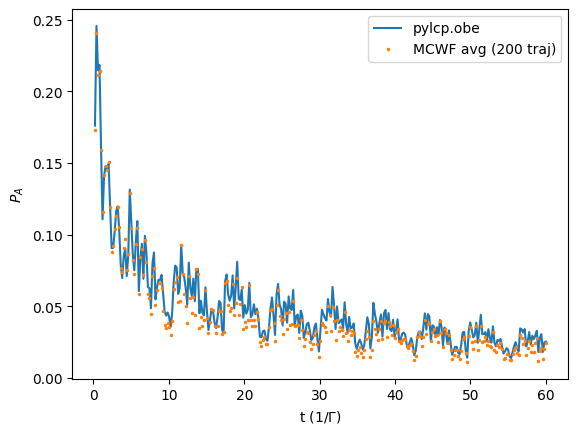

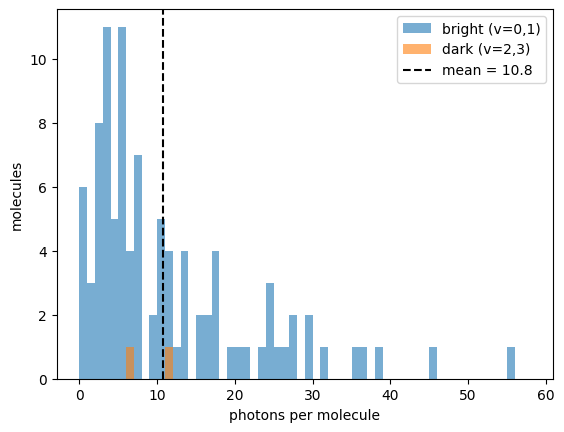

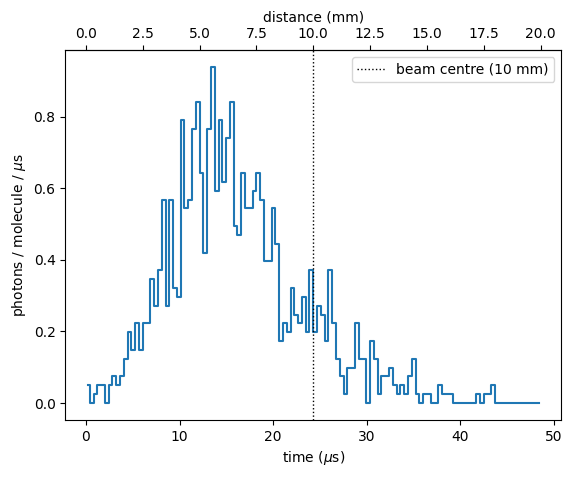

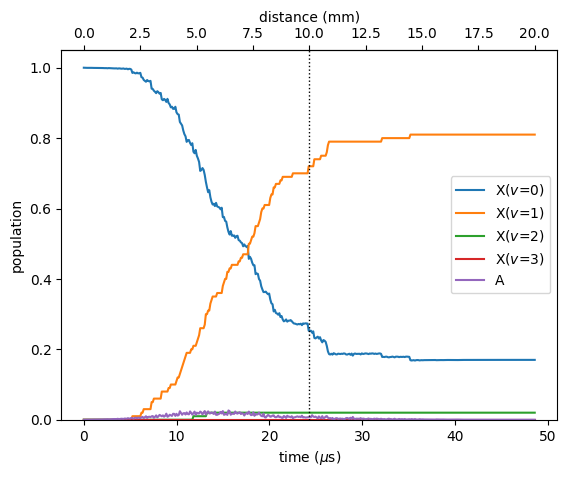


This took 407.67848205566406 s to run


In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate. 
 
The Monte-Carlo wavefunction (MCWF / quantum-jump) method gives both:
a 52-dimensional wavefunction evolves under the non-Hermitian
H_eff(t) = H(t) - (i/2) * P_excited, and each quantum jump IS a
spontaneously emitted photon whose decay channel (FCF-weighted dipole)
decides the vibrational branch. Trajectory-averaged it is mathematically
equivalent to the OBE; trajectory-by-trajectory it is a photon counting
record -- exactly the lab observable.
 
Implementation notes
--------------------
* H(t) is built from pyLCP's own `hamiltonian.return_full_H` and each
  beam's `electric_field`, so all conventions (dipole normalisation,
  polarisation, Zeeman, field amplitude <-> s) are identical to pyLCP's
  OBE by construction. The code asserts this and additionally validates
  the trajectory average against `pylcp.obe` on a reduced system.
* Sideband-sideband and counter-propagating-beam interference is fully
  coherent. The standing-wave phase is sampled by giving each molecule a
  random transverse position x0 (the lab average over the beam).
* Finite laser linewidth is included as phase diffusion, common to all
  sidebands of one colour (they come from one laser + EOM); this
  partially destabilises coherent dark states, as in the real experiment.
* Polarisation: as in the experiment, the light is LINEARLY polarised
  and an electro-optic modulator (Pockels cell) switches it between two
  orthogonal linear polarisations (here y-hat and z-hat, both
  perpendicular to k // x) with a square wave at f_EOM. This is
  implemented by giving every physical beam two static-polarisation
  pyLCP beams (so all field conventions still come from pyLCP) and
  gating them on/off in the MCWF right-hand side; each molecule sees a
  random phase of the switching cycle. Polarisation switching remixes
  Zeeman dark states in addition to the B-field.
"""

import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt
import time

t_begin = time.time()

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 100                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

time_bin = 8.5e-3 # s

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.933, 0.066, 3e-3, 2.5e-4])
fcf = fcf / np.sum(fcf, axis=0)
fcf_sum = np.sum(fcf, axis=0)
assert fcf_sum - 1. < 1e-15, f"FCF factors {fcf_sum} don't sum to 1"
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 10*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
"""
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat
"""
def power_to_s(P_total, fracs, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    fracs = np.asarray(fracs, dtype=float)
    fracs = fracs/fracs.sum()
    return (P_total*fracs)/(2*np.pi*sigma_m**2)/I_sat


V1_ON = False

frac_p1 = np.array([50, 12.5, 12.5, 25])
frac_v1 = np.array([50, 12.5, 12.5, 25])

P_p1 = 105e-3
P_v1 = 0#44e-3
s_p1 = power_to_s(P_p1, frac_p1, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, frac_v1, sigma_m, w_v1)
print("peak s per sideband: main", np.array2string(s_p1, precision=1),
      " repump", np.array2string(s_v1, precision=1))
print(f"P1 power {P_p1} W")
print(f"V1 power {P_v1} W")
# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 754e3
linewidth_v1_Hz = 541e3
gL_p1 = np.pi*linewidth_p1_Hz*tau   # pi*FWHM * tau = phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau

# EOM polarisation switching: linear polarisation toggled between
# y-hat and z-hat (both perp. to k // x) with a 50% duty-cycle square
# wave at f_EOM. Set to the experimental switching frequency.
f_EOM = 900000                           # Hz
T_switch = 1./(f_EOM*tau)              # full period in units of 1/Gamma
T_half_pol = 0.5*T_switch              # half period (one pol on at a time)
print(f"EOM pol switching: {f_EOM/1e6:.2f} MHz "
      f"(half-period {T_half_pol:.1f} /Gamma)")


R_ap = 5*mm                      # 5 mm aperture radius
y0_arr = np.zeros(N_MC)
# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
# V=0
H0_X[0], Bq_X[0], U_X[0], X_bases[0] = pylcp.hamiltonians.XFmolecules.Xstate(
    N=1, I=1/2, B=7233.8271, gamma=-13.41679,
    b=(170.26374-85.4208/3), 
    c=85.4208, CI=0.02038, q0=0, q2=0,
    gS=2.0023193043622, gI=0.,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
    )
#V=1,2,3
for v in range(3):
    H0, Bq, U, Xbasis = pylcp.hamiltonians.XFmolecules.Xstate(
        N=1, I=1/2, B=7188.8919, gamma=-33.81036, 
        b=(168.770 - 86.7120/3), 
        c=86.7120, CI=0.02038, q0=0, q2=0,
        gS=2.0023193043622, gI = 0.0,
        muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
        )
    H0_X[v+1], Bq_X[v+1], U_X[v+1], X_bases[v+1] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = pylcp.hamiltonians.XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=(3/2*4.8), glprime=-3*.0211,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
    )
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each, maps 4 excited A amplitudes down into the 12 sublevels of ground manifold v, for emitted polarization q.

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

# The two orthogonal linear polarisations the EOM switches between.
# Beams propagate along +/-x, so both y-hat and z-hat are transverse.
# z-hat drives pi transitions, y-hat drives (sigma+ + sigma-)/sqrt(2).
POL_EOM = (np.array([0., 1., 0.]), np.array([0., 0., 1.]))

def beam_pair(k, s_arr, deltas, s_scale=1.0):
    """Each physical beam is entered twice, once per EOM polarisation
    state (pol group 0 = y-hat, 1 = z-hat). In the MCWF the two are
    gated on/off in antiphase (square wave); for the rate-equation
    reference use s_scale=0.5 with both on, i.e. the time average."""
    beams = []
    s_arr = np.broadcast_to(np.asarray(s_arr, float), np.shape(deltas))
    for delta, s_max in zip(deltas, s_arr):
        for sign in (+1, -1):
            for pol_vec in POL_EOM:
                beams.append({'kvec': np.array([sign*k, 0., 0.]),
                              'pol': pol_vec.copy(),
                              'pol_coord': 'cartesian',
                              'delta': delta,
                              's': crossed_beam_s(s_scale*s_max,
                                                  w_beam, z_laser)})

    return pylcp.laserBeams(beams)

def polgrp_for(n_deltas):
    """Pol-group index (0=y, 1=z) per beam, matching beam_pair order."""
    return np.array([p for _ in range(n_deltas) for _ in (0, 1)
                     for p in (0, 1)], dtype=np.int64)

def hf_levels(H0):
    """Unique hyperfine energies (in Gamma units) + degeneracies."""
    E, cnt = np.unique(np.round(np.diag(H0), 6), return_counts=True)
    return E/gamma_MHz, cnt

E_X0_hf, cnt_X0 = hf_levels(H0_X[0])
E_X1_hf, cnt_X1 = hf_levels(H0_X[1])
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz

deltas_p1 = E_A_F1 - E_X0_hf + det_p1
deltas_v1 = E_A_F1 - E_X1_hf + det_v1          # <-- v=1 energies, not v=0
assert len(deltas_p1) == 4 and len(deltas_v1) == 4, "hyperfine degeneracy split"

if V1_ON:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
                'X1->A': beam_pair(k_v1, s_v1, deltas_v1)
                }

    # Rate-equation reference: rateeq cannot gate beams in time, so use the
    # time average of the square wave -- both polarisations on at s/2.
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5),
                    'X1->A': beam_pair(k_v1, s_v1, deltas_v1, s_scale=0.5)
                 }
else:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1)}
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5)}

# F-label diagnostic (just in case)
F_of_count = {1: 'F=0', 3: 'F=1', 5: 'F=2'}
for tag, (E, cnt), fr, s_ in [('P1/X0', (E_X0_hf, cnt_X0), frac_p1, s_p1),
                              ('V1/X1', (E_X1_hf, cnt_X1), frac_v1, s_v1)]:
    print(f"{tag} sideband map:")
    for i, (Ei, ci) in enumerate(zip(E, cnt)):
        print(f"  [{i}] {F_of_count[ci]:4s} E={Ei*gamma_MHz:8.1f} MHz "
              f"frac={fr[i]/np.sum(fr):.3f}  s={s_[i]:.1f}")


B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)


v_forward = 3.5/time_bin/v_unit 
print(f"Forward velocity {3.5/time_bin:.2f} ms^-1 with time bin {time_bin} s")
v_vec = np.array([0., 0., v_forward])
t_max = (20*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams_re, magField, ham,
                          include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ----------------------------------------------------------
# MCWF machinery
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
if V1_ON:
    key_row = {'X0->A': 0, 'X1->A': n_X}
else:
    key_row = {'X0->A': 0}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0, y0=0.):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, y0, z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
         phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2].

    EOM polarisation switching: beam b is on only while the square wave
    (half-period T_half, molecule-specific phase offset tsw0) selects
    its pol group polgrp[b]. T_half <= 0 disables gating (all beams on,
    used by the OBE cross-check)."""
    n = psi.shape[0]
    # H_static \psi
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        if T_half > 0.:
            if (np.int64((t + tsw0)//T_half) % 2) != polgrp[b]:
                continue
        # c_b(t) = env exp(i(\delta t + \phi_{colour}))
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                    Lops, Lv, vfw, zc, sig, gL, dt, T, seed,
                    tgrid, pops, jhist):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark).

    Additionally ACCUMULATES (+=, over the whole ensemble) into:
      pops[ig, 0:4] -- population in X(v=0..3) at tgrid[ig]
      pops[ig, 4]   -- population in A at tgrid[ig]
      jhist[jb]     -- photon emission times, binned uniformly on [0, T]
    Divide both by N_MC afterwards."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    nX1 = Lops.shape[1]                 # states per X manifold (12)
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    # molecules arrive at a random phase of the EOM switching cycle
    tsw0 = 0.
    if T_half > 0.:
        tsw0 = np.random.random()*2.*T_half
    t = 0.
    ig = 0
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
             phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            # Choose channel
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            # \psi_new = C \psi
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            # Normalise
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            # bin the emission time (CCD signal ~ z = v*t)
            jb = np.int64(t/T*jhist.shape[0])
            if jb >= jhist.shape[0]:
                jb = jhist.shape[0] - 1
            jhist[jb] += 1.
            # dark vibrational state: population frozen in X(v)
            if V1_ON:
                if v >= 2:               
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            else:
                if v >= 1:
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            rjump = np.random.random()
            nrm = 1.
        elif nrm > 1e-30:
            pass
        # sample manifold populations on the output grid
        while ig < tgrid.shape[0] and t >= tgrid[ig]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # tail: fill any grid points beyond the last integration step
    if ig < tgrid.shape[0]:
        nrm = 0.
        for i in range(n):
            nrm += psi[i].real**2 + psi[i].imag**2
        while ig < tgrid.shape[0]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ---------------------------------------------------------
# Validation: MCWF trajectory average vs pylcp.obe

# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    # pylcp.obe cannot gate polarisations in time, so the cross-check is
    # run with switching DISABLED (T_half = -1): both linear pols on
    # simultaneously in both MCWF and OBE. This still validates every
    # field/phase/Zeeman/jump convention, which is pol-independent.
    pol_r = polgrp_for(len(deltas_p1))
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, 0.,
                 phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
                 0., phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         pol_r, -1.0, L_red, Lv_red, DT, tgrid,
                         int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation_nov1.png', dpi=150)

# -------------------------------------------------------
# Production: full 52-state transit ensemble
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
# 16 main + 16 repump beams (4 sidebands x 2 directions x 2 EOM pols)
colour_arr = np.array([0]*16 + [1]*16, dtype=np.int64)
polgrp_arr = np.concatenate([polgrp_for(len(deltas_p1)),
                             polgrp_for(len(deltas_v1))])
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)

# ensemble-accumulated observables (filled in-place by mcwf_trajectory)
n_tg = 400
tgrid_pop = np.linspace(0., t_max, n_tg)     # population sampling grid
pop_acc = np.zeros((n_tg, 5))                # X0..X3, A
n_jbins = 120
jump_hist = np.zeros(n_jbins)                # photon emission times

for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    y0 = R_ap*np.sqrt(rng.random())*np.sin(2*np.pi*rng.random())
    y0_arr[m] = y0
    Mb, rows, dels = extract_beam_blocks(x0, y0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, polgrp_arr, T_half_pol,
                                 L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)),
                                 tgrid_pop, pop_acc, jump_hist)
    photons[m], v_final[m] = nph, vf
    if (m+1) % 10 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

pop_acc /= N_MC                              # ensemble-average populations

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf_nov1.png', dpi=150)

# ---------------------------------------------------------
# Photon emission rate vs time / distance (what a CCD along z sees).
# Molecules fly at constant v_forward, so z = v*t maps time directly
# onto position; the top axis is distance from the start (beam centre
# marked at z_laser).
v_real = v_forward*v_unit                    # m/s
t_to_us = tau*1e6                            # sim time -> microseconds
us_to_mm = v_real*1e-3                       # 100 m/s = 0.10 mm/us

dt_bin = t_max/n_jbins
t_cent_us = (np.arange(n_jbins) + 0.5)*dt_bin*t_to_us
rate = jump_hist/N_MC/(dt_bin*t_to_us)       # photons /molecule /us

fig2, ax2 = plt.subplots()
ax2.plot(t_cent_us, rate, drawstyle='steps-mid')
ax2.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1,
            label=f'beam centre ({z_laser/mm:.0f} mm)')
ax2.set_xlabel(r'time ($\mu$s)')
ax2.set_ylabel(r'photons / molecule / $\mu$s')
secax2 = ax2.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax2.set_xlabel('distance (mm)')
ax2.legend()
fig2.savefig('photon_rate_vs_time_mcwf.png', dpi=150)

# ---------------------------------------------------------
# Ensemble-averaged populations vs time (X manifolds and A)
fig3, ax3 = plt.subplots()
t_pop_us = tgrid_pop*t_to_us
pop_labels = [r'X($v$=0)', r'X($v$=1)', r'X($v$=2)', r'X($v$=3)', 'A']
for ip in range(5):
    ax3.plot(t_pop_us, pop_acc[:, ip], label=pop_labels[ip])
ax3.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1)
ax3.set_xlabel(r'time ($\mu$s)')
ax3.set_ylabel('population')
ax3.set_ylim(bottom=0.)
secax3 = ax3.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax3.set_xlabel('distance (mm)')
ax3.legend()
fig3.savefig('populations_vs_time_mcwf.png', dpi=150)

plt.show()

print(f"\nThis took {time.time() - t_begin} s to run")

energy unit: Gamma/2pi = 5.684 MHz
peak s per sideband: main [30.3  7.6  7.6 15.1]  repump [3.5 0.9 0.9 1.7]
P1 power 0.105 W
V1 power 0.011 W
EOM pol switching: 0.90 MHz (half-period 19.8 /Gamma)
P1/X0 sideband map:
  [0] F=1  E=  -128.2 MHz frac=0.500  s=30.3
  [1] F=0  E=    27.5 MHz frac=0.125  s=7.6
  [2] F=2  E=    33.0 MHz frac=0.125  s=7.6
  [3] F=1  E=    64.0 MHz frac=0.250  s=15.1
V1/X1 sideband map:
  [0] F=1  E=  -129.4 MHz frac=0.500  s=3.5
  [1] F=2  E=    22.4 MHz frac=0.125  s=0.9
  [2] F=0  E=    47.1 MHz frac=0.125  s=0.9
  [3] F=1  E=    76.4 MHz frac=0.250  s=1.7
Forward velocity 110.90 ms^-1 with time bin 0.03156 s

rate-equation reference: 118.3 photons (expected to overestimate)

--- validating MCWF against pylcp.obe (reduced X0+A system) ---
max |P_A(MCWF avg, 200 traj) - P_A(OBE)| = 0.0138 (peak P_A ~ 0.246)

--- MCWF ensemble: 100 molecules through the beams ---
  10/100: running mean = 26.5
  20/100: running mean = 29.3
  30/100: running mean = 29.4
  40/100

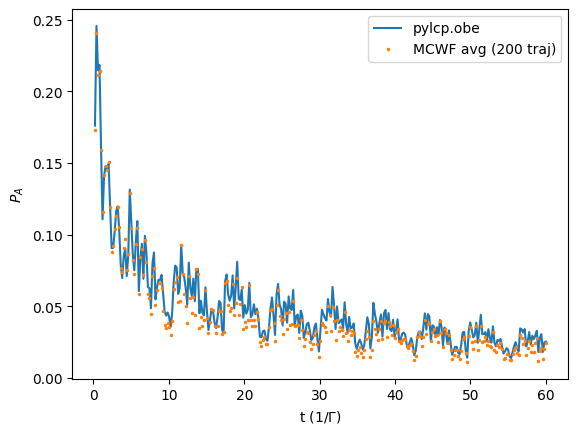

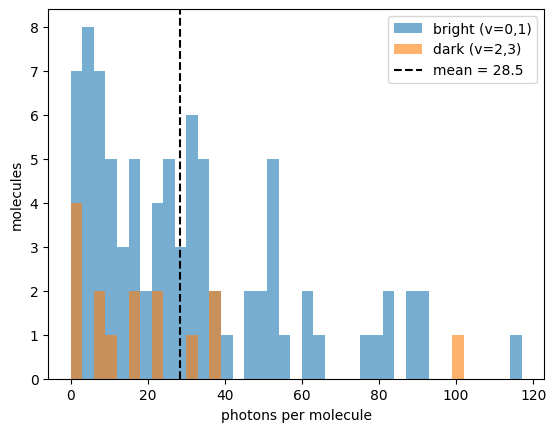

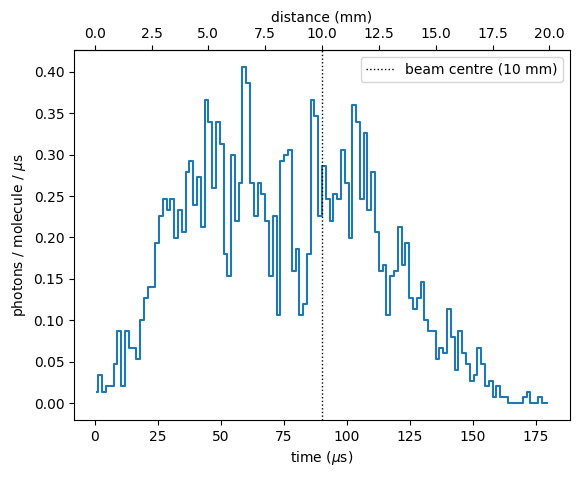

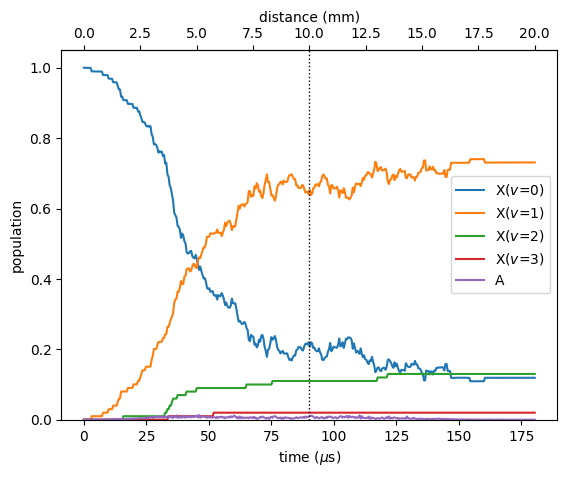


This took 12420.153493642807 s to run


In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate. 
 
The Monte-Carlo wavefunction (MCWF / quantum-jump) method gives both:
a 52-dimensional wavefunction evolves under the non-Hermitian
H_eff(t) = H(t) - (i/2) * P_excited, and each quantum jump IS a
spontaneously emitted photon whose decay channel (FCF-weighted dipole)
decides the vibrational branch. Trajectory-averaged it is mathematically
equivalent to the OBE; trajectory-by-trajectory it is a photon counting
record -- exactly the lab observable.
 
Implementation notes
--------------------
* H(t) is built from pyLCP's own `hamiltonian.return_full_H` and each
  beam's `electric_field`, so all conventions (dipole normalisation,
  polarisation, Zeeman, field amplitude <-> s) are identical to pyLCP's
  OBE by construction. The code asserts this and additionally validates
  the trajectory average against `pylcp.obe` on a reduced system.
* Sideband-sideband and counter-propagating-beam interference is fully
  coherent. The standing-wave phase is sampled by giving each molecule a
  random transverse position x0 (the lab average over the beam).
* Finite laser linewidth is included as phase diffusion, common to all
  sidebands of one colour (they come from one laser + EOM); this
  partially destabilises coherent dark states, as in the real experiment.
* Polarisation: as in the experiment, the light is LINEARLY polarised
  and an electro-optic modulator (Pockels cell) switches it between two
  orthogonal linear polarisations (here y-hat and z-hat, both
  perpendicular to k // x) with a square wave at f_EOM. This is
  implemented by giving every physical beam two static-polarisation
  pyLCP beams (so all field conventions still come from pyLCP) and
  gating them on/off in the MCWF right-hand side; each molecule sees a
  random phase of the switching cycle. Polarisation switching remixes
  Zeeman dark states in addition to the B-field.
"""

import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt
import time

t_begin = time.time()

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 100                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

time_bin = 31.56e-3 # s

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.933, 0.066, 3e-3, 2.5e-4])
fcf = fcf / np.sum(fcf, axis=0)
fcf_sum = np.sum(fcf, axis=0)
assert fcf_sum - 1. < 1e-15, f"FCF factors {fcf_sum} don't sum to 1"
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 10*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
"""
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat
"""
def power_to_s(P_total, fracs, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    fracs = np.asarray(fracs, dtype=float)
    fracs = fracs/fracs.sum()
    return (P_total*fracs)/(2*np.pi*sigma_m**2)/I_sat


V1_ON = True

frac_p1 = np.array([50, 12.5, 12.5, 25])
frac_v1 = np.array([50, 12.5, 12.5, 25])

P_p1 = 105e-3
P_v1 = 11e-3
s_p1 = power_to_s(P_p1, frac_p1, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, frac_v1, sigma_m, w_v1)
print("peak s per sideband: main", np.array2string(s_p1, precision=1),
      " repump", np.array2string(s_v1, precision=1))
print(f"P1 power {P_p1} W")
print(f"V1 power {P_v1} W")
# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 754e3
linewidth_v1_Hz = 541e3
gL_p1 = np.pi*linewidth_p1_Hz*tau   # pi*FWHM * tau = phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau

# EOM polarisation switching: linear polarisation toggled between
# y-hat and z-hat (both perp. to k // x) with a 50% duty-cycle square
# wave at f_EOM. Set to the experimental switching frequency.
f_EOM = 900000                           # Hz
T_switch = 1./(f_EOM*tau)              # full period in units of 1/Gamma
T_half_pol = 0.5*T_switch              # half period (one pol on at a time)
print(f"EOM pol switching: {f_EOM/1e6:.2f} MHz "
      f"(half-period {T_half_pol:.1f} /Gamma)")


R_ap = 5*mm                      # 5 mm aperture radius
y0_arr = np.zeros(N_MC)
# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
# V=0
H0_X[0], Bq_X[0], U_X[0], X_bases[0] = pylcp.hamiltonians.XFmolecules.Xstate(
    N=1, I=1/2, B=7233.8271, gamma=-13.41679,
    b=(170.26374-85.4208/3), 
    c=85.4208, CI=0.02038, q0=0, q2=0,
    gS=2.0023193043622, gI=0.,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
    )
#V=1,2,3
for v in range(3):
    H0, Bq, U, Xbasis = pylcp.hamiltonians.XFmolecules.Xstate(
        N=1, I=1/2, B=7188.8919, gamma=-33.81036, 
        b=(168.770 - 86.7120/3), 
        c=86.7120, CI=0.02038, q0=0, q2=0,
        gS=2.0023193043622, gI = 0.0,
        muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
        )
    H0_X[v+1], Bq_X[v+1], U_X[v+1], X_bases[v+1] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = pylcp.hamiltonians.XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=(3/2*4.8), glprime=-3*.0211,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4, return_basis=True
    )
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each, maps 4 excited A amplitudes down into the 12 sublevels of ground manifold v, for emitted polarization q.

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

# The two orthogonal linear polarisations the EOM switches between.
# Beams propagate along +/-x, so both y-hat and z-hat are transverse.
# z-hat drives pi transitions, y-hat drives (sigma+ + sigma-)/sqrt(2).
POL_EOM = (np.array([0., 1., 0.]), np.array([0., 0., 1.]))

def beam_pair(k, s_arr, deltas, s_scale=1.0):
    """Each physical beam is entered twice, once per EOM polarisation
    state (pol group 0 = y-hat, 1 = z-hat). In the MCWF the two are
    gated on/off in antiphase (square wave); for the rate-equation
    reference use s_scale=0.5 with both on, i.e. the time average."""
    beams = []
    s_arr = np.broadcast_to(np.asarray(s_arr, float), np.shape(deltas))
    for delta, s_max in zip(deltas, s_arr):
        for sign in (+1, -1):
            for pol_vec in POL_EOM:
                beams.append({'kvec': np.array([sign*k, 0., 0.]),
                              'pol': pol_vec.copy(),
                              'pol_coord': 'cartesian',
                              'delta': delta,
                              's': crossed_beam_s(s_scale*s_max,
                                                  w_beam, z_laser)})

    return pylcp.laserBeams(beams)

def polgrp_for(n_deltas):
    """Pol-group index (0=y, 1=z) per beam, matching beam_pair order."""
    return np.array([p for _ in range(n_deltas) for _ in (0, 1)
                     for p in (0, 1)], dtype=np.int64)

def hf_levels(H0):
    """Unique hyperfine energies (in Gamma units) + degeneracies."""
    E, cnt = np.unique(np.round(np.diag(H0), 6), return_counts=True)
    return E/gamma_MHz, cnt

E_X0_hf, cnt_X0 = hf_levels(H0_X[0])
E_X1_hf, cnt_X1 = hf_levels(H0_X[1])
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz

deltas_p1 = E_A_F1 - E_X0_hf + det_p1
deltas_v1 = E_A_F1 - E_X1_hf + det_v1          # <-- v=1 energies, not v=0
assert len(deltas_p1) == 4 and len(deltas_v1) == 4, "hyperfine degeneracy split"

if V1_ON:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
                'X1->A': beam_pair(k_v1, s_v1, deltas_v1)
                }

    # Rate-equation reference: rateeq cannot gate beams in time, so use the
    # time average of the square wave -- both polarisations on at s/2.
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5),
                    'X1->A': beam_pair(k_v1, s_v1, deltas_v1, s_scale=0.5)
                 }
else:
    laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1)}
    laserBeams_re = {'X0->A': beam_pair(1., s_p1, deltas_p1, s_scale=0.5)}

# F-label diagnostic (just in case)
F_of_count = {1: 'F=0', 3: 'F=1', 5: 'F=2'}
for tag, (E, cnt), fr, s_ in [('P1/X0', (E_X0_hf, cnt_X0), frac_p1, s_p1),
                              ('V1/X1', (E_X1_hf, cnt_X1), frac_v1, s_v1)]:
    print(f"{tag} sideband map:")
    for i, (Ei, ci) in enumerate(zip(E, cnt)):
        print(f"  [{i}] {F_of_count[ci]:4s} E={Ei*gamma_MHz:8.1f} MHz "
              f"frac={fr[i]/np.sum(fr):.3f}  s={s_[i]:.1f}")


B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)


v_forward = 3.5/time_bin/v_unit 
print(f"Forward velocity {3.5/time_bin:.2f} ms^-1 with time bin {time_bin} s")
v_vec = np.array([0., 0., v_forward])
t_max = (20*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams_re, magField, ham,
                          include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ----------------------------------------------------------
# MCWF machinery
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
if V1_ON:
    key_row = {'X0->A': 0, 'X1->A': n_X}
else:
    key_row = {'X0->A': 0}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0, y0=0.):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, y0, z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
         phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2].

    EOM polarisation switching: beam b is on only while the square wave
    (half-period T_half, molecule-specific phase offset tsw0) selects
    its pol group polgrp[b]. T_half <= 0 disables gating (all beams on,
    used by the OBE cross-check)."""
    n = psi.shape[0]
    # H_static \psi
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        if T_half > 0.:
            if (np.int64((t + tsw0)//T_half) % 2) != polgrp[b]:
                continue
        # c_b(t) = env exp(i(\delta t + \phi_{colour}))
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                    Lops, Lv, vfw, zc, sig, gL, dt, T, seed,
                    tgrid, pops, jhist):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark).

    Additionally ACCUMULATES (+=, over the whole ensemble) into:
      pops[ig, 0:4] -- population in X(v=0..3) at tgrid[ig]
      pops[ig, 4]   -- population in A at tgrid[ig]
      jhist[jb]     -- photon emission times, binned uniformly on [0, T]
    Divide both by N_MC afterwards."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    nX1 = Lops.shape[1]                 # states per X manifold (12)
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    # molecules arrive at a random phase of the EOM switching cycle
    tsw0 = 0.
    if T_half > 0.:
        tsw0 = np.random.random()*2.*T_half
    t = 0.
    ig = 0
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, tsw0,
             phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
             tsw0, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            # Choose channel
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            # \psi_new = C \psi
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            # Normalise
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            # bin the emission time (CCD signal ~ z = v*t)
            jb = np.int64(t/T*jhist.shape[0])
            if jb >= jhist.shape[0]:
                jb = jhist.shape[0] - 1
            jhist[jb] += 1.
            # dark vibrational state: population frozen in X(v)
            if V1_ON:
                if v >= 2:               
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            else:
                if v >= 1:
                    while ig < tgrid.shape[0]:
                        pops[ig, v] += 1.
                        ig += 1
                    return nph, v, t
            rjump = np.random.random()
            nrm = 1.
        elif nrm > 1e-30:
            pass
        # sample manifold populations on the output grid
        while ig < tgrid.shape[0] and t >= tgrid[ig]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # tail: fill any grid points beyond the last integration step
    if ig < tgrid.shape[0]:
        nrm = 0.
        for i in range(n):
            nrm += psi[i].real**2 + psi[i].imag**2
        while ig < tgrid.shape[0]:
            for vv in range(4):
                pv = 0.
                for i in range(nX1):
                    s_ = psi[vv*nX1 + i]
                    pv += s_.real**2 + s_.imag**2
                pops[ig, vv] += pv/nrm
            pa = 0.
            for j in range(4):
                pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
            pops[ig, 4] += pa/nrm
            ig += 1
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ---------------------------------------------------------
# Validation: MCWF trajectory average vs pylcp.obe

# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    # pylcp.obe cannot gate polarisations in time, so the cross-check is
    # run with switching DISABLED (T_half = -1): both linear pols on
    # simultaneously in both MCWF and OBE. This still validates every
    # field/phase/Zeeman/jump convention, which is pol-independent.
    pol_r = polgrp_for(len(deltas_p1))
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, polgrp, T_half,
                Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, polgrp, T_half, 0.,
                 phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, polgrp,
                 T_half, 0., phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, polgrp, T_half,
                 0., phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         pol_r, -1.0, L_red, Lv_red, DT, tgrid,
                         int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation_nov1.png', dpi=150)

# -------------------------------------------------------
# Production: full 52-state transit ensemble
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
# 16 main + 16 repump beams (4 sidebands x 2 directions x 2 EOM pols)
colour_arr = np.array([0]*16 + [1]*16, dtype=np.int64)
polgrp_arr = np.concatenate([polgrp_for(len(deltas_p1)),
                             polgrp_for(len(deltas_v1))])
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)

# ensemble-accumulated observables (filled in-place by mcwf_trajectory)
n_tg = 400
tgrid_pop = np.linspace(0., t_max, n_tg)     # population sampling grid
pop_acc = np.zeros((n_tg, 5))                # X0..X3, A
n_jbins = 120
jump_hist = np.zeros(n_jbins)                # photon emission times

for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    y0 = R_ap*np.sqrt(rng.random())*np.sin(2*np.pi*rng.random())
    y0_arr[m] = y0
    Mb, rows, dels = extract_beam_blocks(x0, y0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, polgrp_arr, T_half_pol,
                                 L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)),
                                 tgrid_pop, pop_acc, jump_hist)
    photons[m], v_final[m] = nph, vf
    if (m+1) % 10 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

pop_acc /= N_MC                              # ensemble-average populations

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf_nov1.png', dpi=150)

# ---------------------------------------------------------
# Photon emission rate vs time / distance (what a CCD along z sees).
# Molecules fly at constant v_forward, so z = v*t maps time directly
# onto position; the top axis is distance from the start (beam centre
# marked at z_laser).
v_real = v_forward*v_unit                    # m/s
t_to_us = tau*1e6                            # sim time -> microseconds
us_to_mm = v_real*1e-3                       # 100 m/s = 0.10 mm/us

dt_bin = t_max/n_jbins
t_cent_us = (np.arange(n_jbins) + 0.5)*dt_bin*t_to_us
rate = jump_hist/N_MC/(dt_bin*t_to_us)       # photons /molecule /us

fig2, ax2 = plt.subplots()
ax2.plot(t_cent_us, rate, drawstyle='steps-mid')
ax2.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1,
            label=f'beam centre ({z_laser/mm:.0f} mm)')
ax2.set_xlabel(r'time ($\mu$s)')
ax2.set_ylabel(r'photons / molecule / $\mu$s')
secax2 = ax2.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax2.set_xlabel('distance (mm)')
ax2.legend()
fig2.savefig('photon_rate_vs_time_mcwf.png', dpi=150)

# ---------------------------------------------------------
# Ensemble-averaged populations vs time (X manifolds and A)
fig3, ax3 = plt.subplots()
t_pop_us = tgrid_pop*t_to_us
pop_labels = [r'X($v$=0)', r'X($v$=1)', r'X($v$=2)', r'X($v$=3)', 'A']
for ip in range(5):
    ax3.plot(t_pop_us, pop_acc[:, ip], label=pop_labels[ip])
ax3.axvline(z_laser/mm/us_to_mm, color='k', ls=':', lw=1)
ax3.set_xlabel(r'time ($\mu$s)')
ax3.set_ylabel('population')
ax3.set_ylim(bottom=0.)
secax3 = ax3.secondary_xaxis(
    'top', functions=(lambda t_us: t_us*us_to_mm,
                      lambda z_mm: z_mm/us_to_mm))
secax3.set_xlabel('distance (mm)')
ax3.legend()
fig3.savefig('populations_vs_time_mcwf.png', dpi=150)

plt.show()

print(f"\nThis took {time.time() - t_begin} s to run")